### `📤 Import Libraries`.

In [410]:
import os
import io
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.graph_objs as go
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.ticker as tkr
import psycopg2
import xlsxwriter
import scipy.stats
import dataframe_image as dfi
import time
import tarfile # Read and write tar archives, including those using gzip, bz2 and lzma compression.
import zipfile # Read or write (.zip) files, or the higher-level functions in shutil
import urllib.request # Open and fetch data from URLs
import warnings
warnings.filterwarnings('ignore')

#==#

from io import BytesIO
from numpy import mean, absolute
from numpy import median, absolute
from sqlalchemy import create_engine
from matplotlib.ticker import FormatStrFormatter, StrMethodFormatter, FuncFormatter, PercentFormatter, MultipleLocator, AutoMinorLocator
from matplotlib import font_manager
from matplotlib import colormaps
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.cbook import boxplot_stats
from pandas.io.formats.style import Styler
from pandas.io.formats.excel import ExcelFormatter
from openpyxl import Workbook
from scipy import stats
from scipy.stats import norm # Normalisation of data
from scipy.stats import trim_mean
from statistics import variance
from statistics import stdev
from sklearn import metrics
from sklearn.linear_model import LinearRegression # Statistical method for predicting an outcome based on one or more influencing factors
from sklearn.linear_model import LogisticRegression # Statistical method for predicting binary classes
from sklearn.model_selection import train_test_split # Split arrays or matrices into random train and test subsets.
from sklearn.preprocessing import StandardScaler, OneHotEncoder # Standardise data
from sklearn.compose import ColumnTransformer # Apply transformers to specific columns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE #
from sklearn.cluster import KMeans # KMeans method from sklearn to build the K-Means model
from yellowbrick.cluster import KElbowVisualizer # KElbowVisualizer to visualise K-Means model performance
from fpdf import FPDF
from PIL import Image
from IPython.display import HTML, display
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from datetime import timedelta # Represent the difference between two datetime objects.
from pathlib import Path

#==#

# Time series and forecasting libraries
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose # Use for seasonal sales data
import statsmodels.api as sm

# For advanced forecasting
from prophet import Prophet  # Requires `pip install prophet`

# Model evaluation
from sklearn.metrics import confusion_matrix # Evaluate the accuracy of a classification.
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

#==#

import pmdarima as pm
from statsmodels.tsa.arima.model import ARIMA

#==#

# Apriori algorithm and association rule mining libraries
import networkx as nx # Python package for the creation, manipulation, and study of the structure, dynamics, and functions of complex networks.
from mlxtend.frequent_patterns import apriori, association_rules # Get frequent itemsets from a one-hot DataFrame, Generates a DataFrame of association rules including the metrics 'score', 'confidence', and 'lift'
from mlxtend.preprocessing import TransactionEncoder # Encoder class for transaction data in Python lists

#==#

from lifetimes import BetaGeoFitter, GammaGammaFitter # BG/NBD + Gamma-Gamma model for Predicting Customer Lifetime Value (CLTV)
from lifetimes.utils import summary_data_from_transaction_data

#==#

# pd.options.display.max_columns = 100
# pd.set_option('display.max_columns', 100)

# Show all columns
pd.set_option('display.max_columns', None)

# Show all rows
pd.set_option('display.max_rows', None)

# Prevent line wrapping of wide columns (for cleaner display)
pd.set_option('display.expand_frame_repr', False)

# Display nicely
pd.set_option('display.max_colwidth', None)

#==#

%matplotlib inline

### `📥 Load Dataframe`.

In [411]:
# Define path to california housing market data analysis file
file_path = os.path.expanduser("~/Python-Documents/os/CSV Files/California_Housing_Market_Data_Analysis_modified_3.csv")

# Read and copy data
read_csv = pd.read_csv(file_path)
housing = read_csv.copy()

# Display first 2 rows
housing.head(2)

#==#

# # Load the dataset
# file_path = r"\Users\tailb\Python-Documents\os\CSV Files\California_Housing_Market_Data_Analysis_modified_3.csv"

# # Read and copy data
# read_csv = pd.read_csv(file_path)
# housing = read_csv.copy()

# # Display first 2 rows
# housing.head(2)

,longitude,latitude,population,households,total_rooms,total_bedrooms,people_per_house,rooms_per_house,rooms_per_person,income_per_person,bedrooms_ratio,housing_median_age,median_income,median_house_value,ocean_proximity,MHV_cluster,MHV_cluster_name,price_cluster,price_cluster_name,wealth_cluster,wealth_cluster_name,geo_cluster,geo_cluster_name,market_segment_cluster,market_segment_cluster_name,Risk,Return,Best Strategy,Annotated Summary,Cluster,Best Strategy Short,location_name
0,-122.23,37.88,322.0,126.0,880.0,129.0,2.555556,6.984127,2.732919,3257.686957,0.146591,41.0,8325.2,452600.0,NEAR BAY,1,🏆 Premium,1,Affluent Districts,1,Luxury Zones,0,Northern California,1,🏙️ Urban Mid-Range,Low,High,Premium Buy & Hold,💎 Premium Buy & Hold,5,PB&H,Alameda County
1,-122.22,37.86,2401.0,1138.0,7099.0,1106.0,2.109842,6.238137,2.956685,3934.607747,0.155797,21.0,8301.4,358500.0,NEAR BAY,1,🏆 Premium,1,Affluent Districts,1,Luxury Zones,0,Northern California,1,🏙️ Urban Mid-Range,Low,High,Premium Buy & Hold,💎 Premium Buy & Hold,5,PB&H,Alameda County


### `📶 Analyse Dataframe`.

#### `⚙️ Set Plot Context And Style`.

In [412]:
# Set plot context and style

# Step 1: Set font dictionaries
title_font = {'family':'trebuchet ms','color':'darkorchid','size':20,'style':'normal','weight':'bold'}
x_label_font = {'family':'verdana','color':'darkred','size':15,'style':'normal','weight':'bold'}
y_label_font = {'family':'verdana','color':'darkgreen','size':15,'style':'normal','weight':'bold'}
text_font = {'ha':'center','va':'bottom','family':'georgia','color':'green','size':8,'style':'normal','weight':'bold'}

# Step 2: Set styles
context = sns.set_context("notebook") # ('paper', 'notebook', 'talk', 'poster')
# style = sns.axes_style() # ('darkgrid', 'whitegrid', 'dark', 'white', 'ticks')
style = sns.axes_style("ticks",{
    # Figure
    'figure.figsize':(10, 6),'figure.dpi':100,   
    # Grid (grid.axis:'x', 'y', 'both', grid.which: 'major', 'minor', 'both')
    'axes.grid':True, 'grid.linestyle':'-.','grid.linewidth':0.2,'grid.color':'white', 'grid.alpha':0.2,'axes.grid.axis':'both', 'axes.grid.which':'major',
    # Axes Background
    'axes.facecolor':'white','figure.facecolor':'lightblue','axes.alpha':1.0, # lightblue
    # Axes Border (Spines)
    'axes.edgecolor':'cyan', 'axes.linewidth': 1.5, 'axes.spines.top': False,'axes.spines.right':False, 'axes.spines.left':True, 'axes.spines.bottom':True,
    # Axes Labels (x/y label color, x/y label font size)
    'axes.labelcolor':'black', 'axes.labelsize': 'medium', 'axes.labelweight':'normal', 'axes.labelpad':4.0,  
    # Tick Marks
    'xtick.bottom':True,'xtick.top':False, 'xtick.color':'darkgreen', 'xtick.labelcolor':'darkred', 'xtick.labelsize':7,
    'xtick.major.size':6, 'xtick.major.width':2,'xtick.major.pad':4, 'xtick.minor.size':3,'xtick.minor.width':0.5, 'xtick.direction':'out',
    'ytick.left':True, 'ytick.right':False, 'ytick.color':'darkblue', 'ytick.labelcolor':'darkgreen', 'ytick.labelsize':7,
    'ytick.major.size':6,'ytick.major.width':2, 'ytick.major.pad':4,'ytick.minor.size':3, 'ytick.minor.width':0.5,'ytick.direction':'out',
    # Lines (-, --, -., :, solid, dashed, dashdot, dotted)
    'lines.linewidth':1.5, 'lines.markersize':6, 'lines.linestyle':'-',
    # Font (global font family, global font size)
    'font.family': 'consolas', 'font.size':10, 'font.style':'normal', 'font.weight':'normal',
    # Legend(legend border box, legend transparency, legend border color & legend background)
    'legend.frameon':True, 'legend.framealpha':0.8, 'legend.edgecolor':'black', 'legend.facecolor':'white'})        

# Step 3: Set theme
sns.set_theme(context=context, style=style, palette='bright', font='tahoma', font_scale=None, color_codes=True)

#### `📈 Univariate Analysis`.

**`Examining a single variable at a time to identify patterns, central tendencies, and dispersion`**.

##### `📊 Histogram - Distribution Of California Housing Features`.

In [413]:
# # Univariate Analysis
# sns.displot(housing['median_house_value'])
# plt.ylabel('Density')

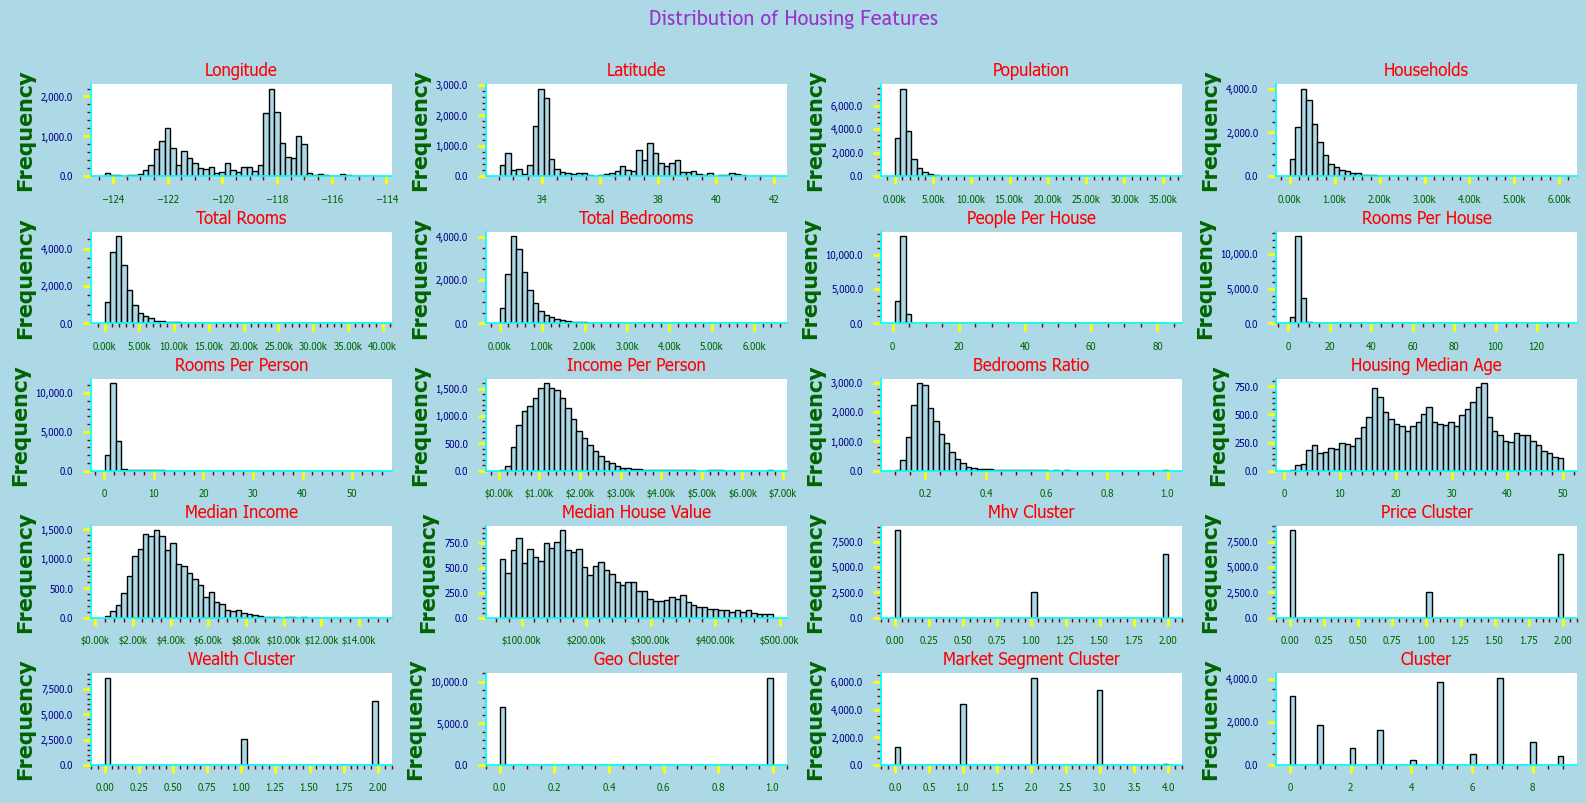

In [414]:
# Step 1: Plot histograms and capture the returned axes
axes = housing.hist(bins=50, figsize=(16, 8), color='lightblue', edgecolor='black')

# Step 2: Define $k formatter function
def dollar_k_formatter(x, pos):
    return f'${x/1000:,.2f}k'    # e.g. \$100k, \$200k

# Step 3: Define $k formatter function
def count_k_formatter(x, pos):
    return f'{x/1000:,.2f}k'    # e.g. \100k, \200k

# Step 4: Define specific columns and their formatters
currency_cols = ['median_income', 'median_house_value', 'income_per_person']   # $ format
# percent_cols  = [] # % format
non_currency_cols  = ['population', 'households', 'total_rooms', 'total_bedrooms'] # , format

# Step 5: Add ylabel to each subplot
for hist in axes.flatten():
    col_name = hist.get_title()  # 👈 Get column name from subplot title
    if hist.has_data():
        hist.set_title(col_name.replace('_', ' ').title(), family='tahoma', color='red') # .upper(), .lower()
        # hist.set_xlabel(col_name.replace('_', ' ').title(), fontdict=x_label_font)
        hist.set_ylabel('Frequency', fontdict=y_label_font)
        hist.yaxis.set_major_formatter(StrMethodFormatter('{x:,}')) #
        hist.minorticks_on()
        hist.tick_params(axis='x', bottom=True, top=False, length=6, width=2, color='yellow', direction='out', labelsize=7, labelcolor='darkgreen', labelfontfamily='tahoma', labelrotation=None)
        hist.tick_params(axis='y', left=True, right=False, length=6, width=2, color='yellow', direction='out', labelsize=7, labelcolor='darkblue', labelfontfamily='tahoma', labelrotation=None)
        hist.tick_params(axis='x', which='minor', bottom=True, top=False, length=3, width=1, color='darkred')
        hist.tick_params(axis='y', which='minor', left=True, right=False,  length=3, width=1, color='darkred')
        # hist.autoscale()
        # hist.axis('equal')
        # hist.set_xlim(left=0)
        # hist.set_ylim(bottom=0)
        # hist.set_xscale('log')
        # hist.set_yscale('log')
        # hist.set_yscale('linear')  # Try removing log scale
    
    # Step 6: Apply specific x-axis formatters based on column name
    if col_name in currency_cols:
            # hist.xaxis.set_major_formatter(StrMethodFormatter('$ {x:,}'))   # $ format
            hist.xaxis.set_major_formatter(FuncFormatter(dollar_k_formatter))  # $k format
    elif col_name in non_currency_cols:
            # hist.xaxis.set_major_formatter(StrMethodFormatter('{x:,}'))     # format
            hist.xaxis.set_major_formatter(FuncFormatter(count_k_formatter))  # k format

# Step 7: Plot subplot title
plt.suptitle("Distribution of Housing Features", fontdict=title_font, x=0.5, y=1.00) # Overview of Housing Dataset Variables, Statistical Distribution of Housing Attributes

# Step 8: Adjust subplot params
plt.tight_layout(pad=1, h_pad=0.3, w_pad=0.3, rect=None)

#==#

# # Step 9: Save plot as png
# # my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\Assets"
# my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\2_Descriptive_Data_Analysis\Assets"
# plt.savefig(my_path + '/Py_00_Distribition_Of_CAL_Housing_Features_Histplot.png',transparent=None,dpi='figure',format=None,metadata=None,bbox_inches='tight',pad_inches=0.1,facecolor='auto',edgecolor='yellow',backend=None)

#==#

# Step 10: Display plot
plt.show()

##### `👨‍👨‍👦‍👦 Group Numerical Values By 'ocean_proximity' And Analyse The Medians`.

In [415]:
# housing.groupby(['ocean_proximity'])[['median_house_value', 'median_income', 'income_per_person', 'rooms_per_person', 'rooms_per_house']].median()\
#     .sort_values(by='median_house_value', ascending=False).round(2).reset_index()

housing.groupby(['ocean_proximity'])[['population', 'households', 'total_rooms', 'total_bedrooms', 'housing_median_age', 
                                      'rooms_per_house', 'rooms_per_person', 'median_house_value', 'median_income', 'income_per_person', ]].median()\
    .sort_values(by='median_house_value', ascending=False).round(2).reset_index()

,ocean_proximity,population,households,total_rooms,total_bedrooms,housing_median_age,rooms_per_house,rooms_per_person,median_house_value,median_income,income_per_person
0,NEAR OCEAN,1191.0,443.0,2205.0,478.0,28.0,5.01,1.96,216100.0,3521.4,1376.01
1,<1H OCEAN,1291.0,428.0,2113.0,446.0,29.0,5.00,1.80,206500.0,3785.7,1362.79
2,NEAR BAY,1085.5,407.5,2104.0,427.0,34.0,5.12,2.02,204800.0,3836.8,1501.80
3,INLAND,1151.0,403.0,2316.0,446.0,20.0,5.62,2.02,118200.0,3202.7,1161.31


##### `📊 Kdeplot - Distribution Of California Housing Features`.

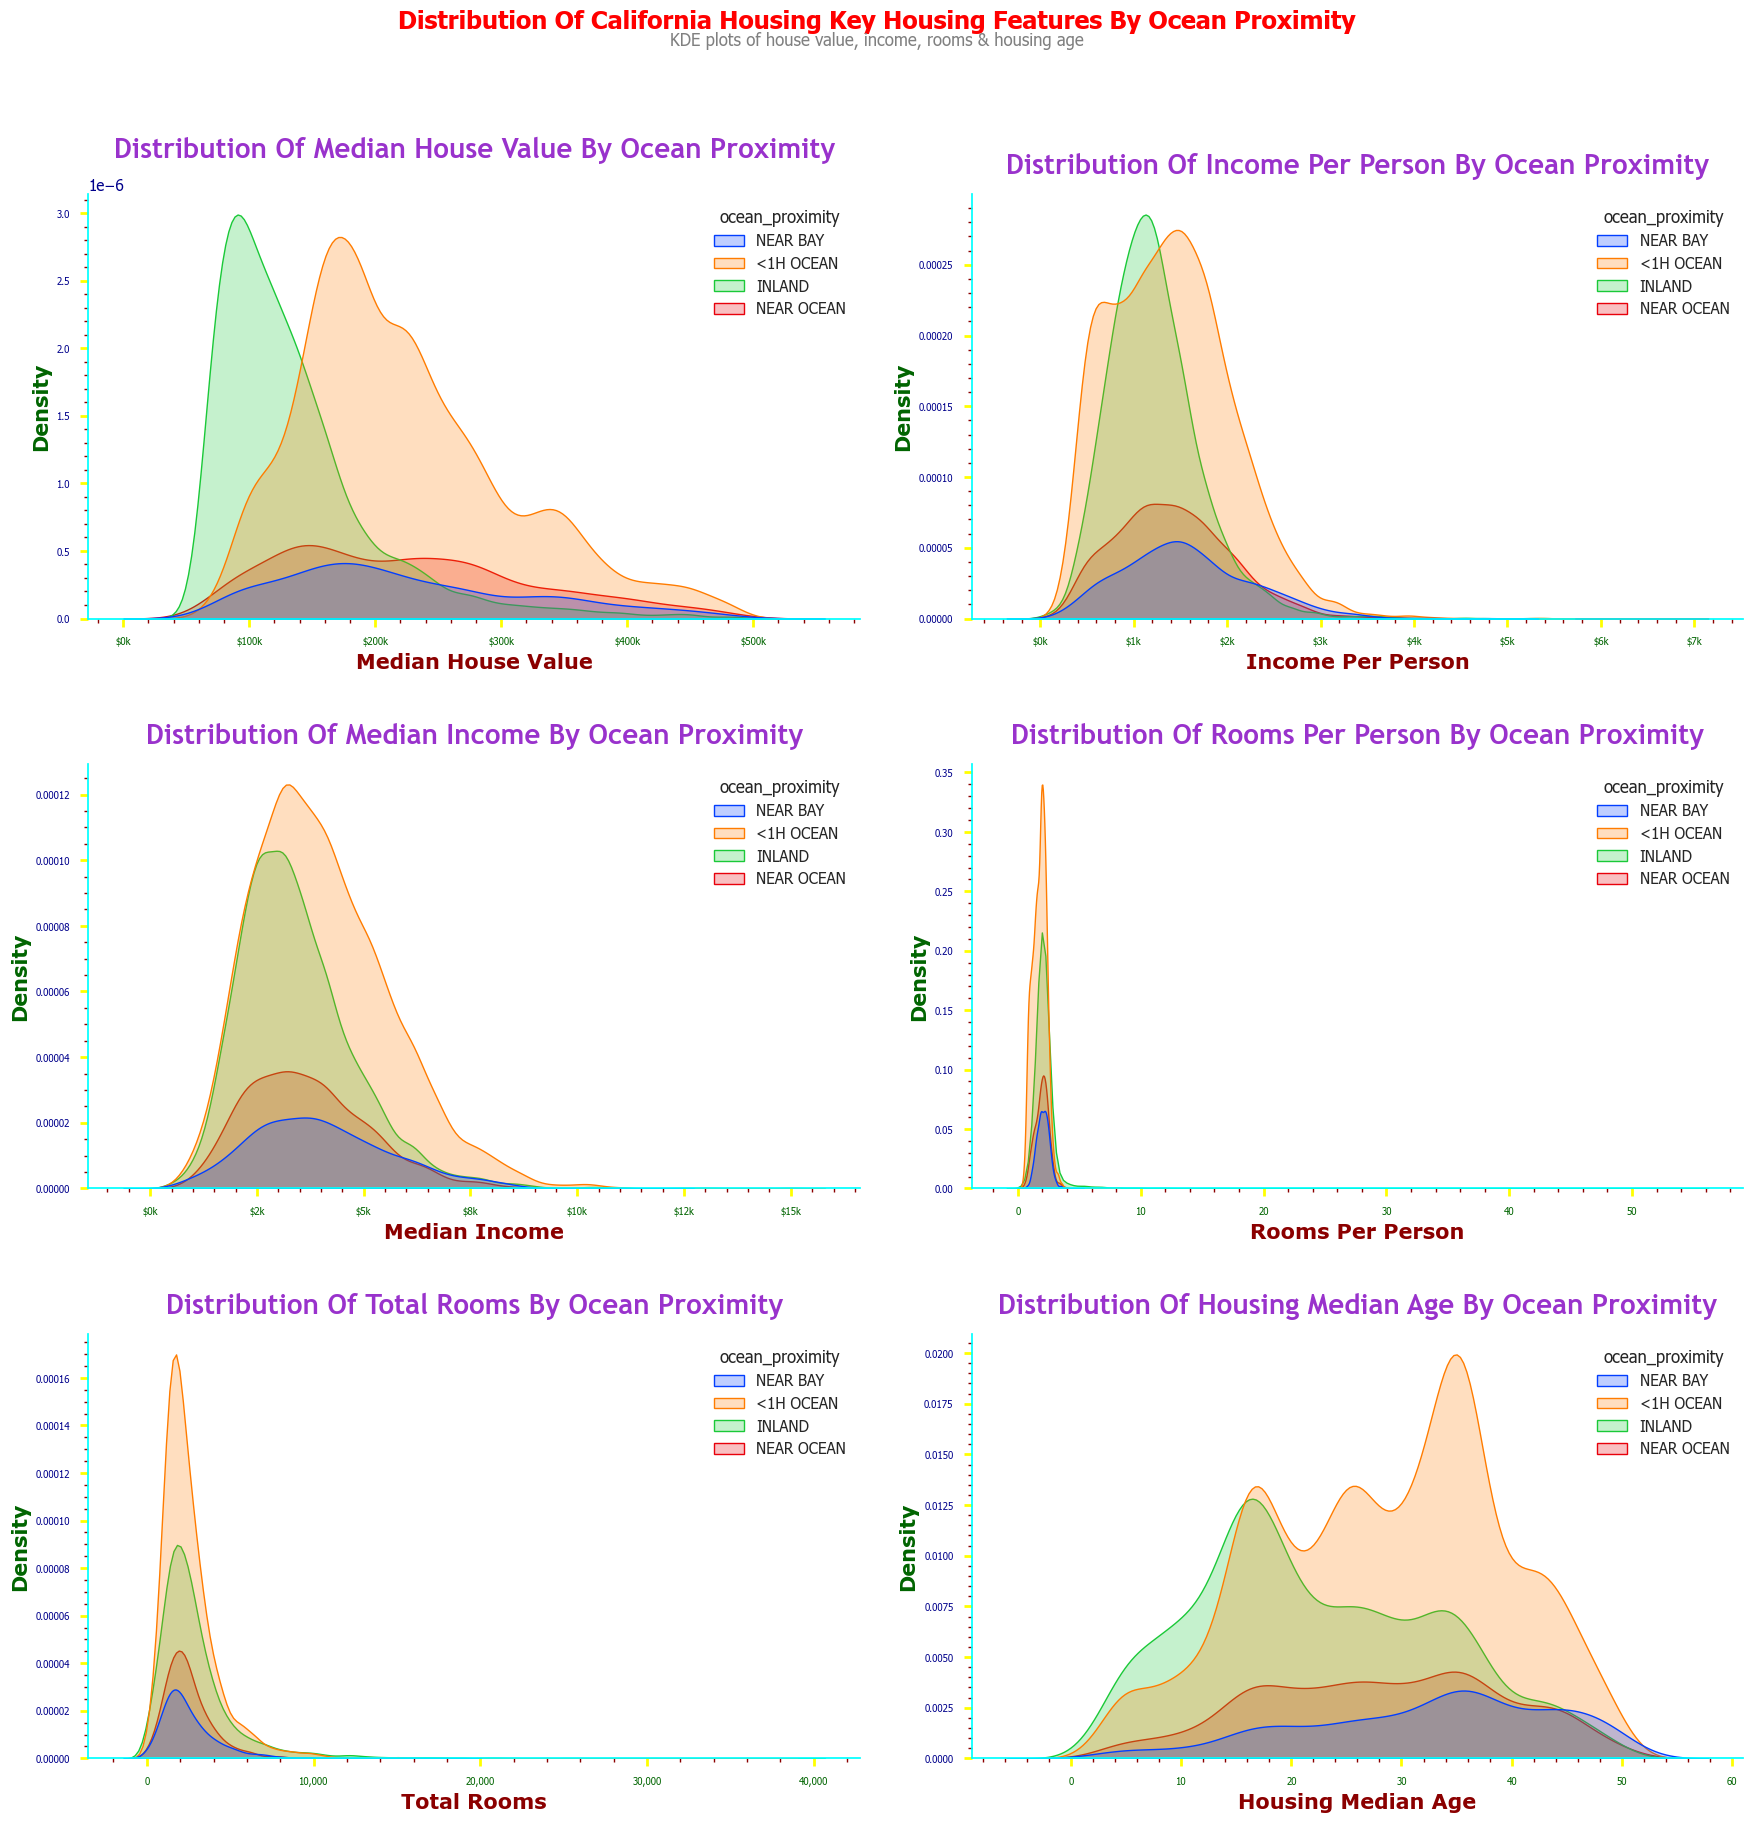

In [416]:
# ── Formatter Functions ───────────────────────────────────────────────────────
def dollar_k_formatter(x, pos):
    """e.g. \$100k, \$200k"""
    return f'${x/1000:,.0f}k'

def dollar_formatter(x, pos):
    """e.g. \$100, \$200"""
    return f'${x:,.0f}'

def count_k_formatter(x, pos):
    """e.g. 100k, 200k"""
    return f'{x/1000:,.0f}k'

def count_formatter(x, pos):
    """e.g. 100, 200"""
    return f'{x:,.0f}'

# ── Column Definitions ────────────────────────────────────────────────────────
columns        = ['median_house_value', 'income_per_person', 'median_income', 
                  'rooms_per_person', 'total_rooms', 'housing_median_age']
currency_cols  = ['median_income', 'median_house_value', 'income_per_person']
non_currency_cols = ['rooms_per_person', 'population', 'households', 
                     'total_rooms', 'total_bedrooms']


# ── Grid Layout ───────────────────────────────────────────────────────────────
ncols = 2
nrows = 3   # 3 rows x 2 cols = 6 subplots (one per column)

fig, axes = plt.subplots(ncols=ncols, nrows=nrows, 
                         figsize=(18, nrows * 6), # Dynamically scales figure height
                         facecolor='white', dpi=100)

# ── Main Title & Subtitle ─────────────────────────────────────────────────────
fig.suptitle(
    "Distribution Of California Housing Key Housing Features By Ocean Proximity",
    fontsize=18, fontweight="bold", fontfamily="Tahoma", color="red",
    y=1.02,
)
fig.text(
    0.5, 1.00,
    "KDE plots of house value, income, rooms & housing age",
    fontsize=12, fontstyle="italic", fontfamily="Tahoma",
    color="grey", ha="center",
)
# ─────────────────────────────────────────────────────────────────────────────

axes = axes.flatten()  # Flatten 2D array → 1D for easy iteration

# ── Main Loop ─────────────────────────────────────────────────────────────────
for idx, col in enumerate(columns):
    kde = axes[idx] # Each column gets its own subplot

    # ── Kde Plot ──────────────────────────────────────────────────────────────
    sns.kdeplot(data=housing, x=col, hue='ocean_proximity', fill=True, ax=kde)
    
    # ── Titles & Labels ───────────────────────────────────────────────────────
    kde.set_title(f'Distribution Of {col.replace("_", " ").title()} By Ocean Proximity', # .upper(), .lower(), 'title()
                   fontdict=title_font, pad=15)
    kde.set_xlabel(col.replace('_', ' ').title(), fontdict=x_label_font) # .upper(), .lower(), 'title()
    kde.set_ylabel('Density', fontdict=y_label_font) # .upper(), .lower(), .title()
    
    # ── Tick Parameters ───────────────────────────────────────────────────────
    kde.minorticks_on()
    kde.tick_params(axis='x', bottom=True, top=False, length=6, width=2, color='yellow', direction='out', labelsize=7, labelcolor='darkgreen', labelfontfamily='tahoma', labelrotation=None)
    kde.tick_params(axis='y', left=True, right=False, length=6, width=2, color='yellow', direction='out', labelsize=7, labelcolor='darkblue', labelfontfamily='tahoma', labelrotation=None)
    kde.tick_params(axis='x', which='minor', bottom=True, top=False, length=3, width=1, color='darkred')
    kde.tick_params(axis='y', which='minor', left=True, right=False,  length=3, width=1, color='darkred')

    # ── X-Axis Formatter ──────────────────────────────────────────────────────
    if col in currency_cols:
        kde.xaxis.set_major_formatter(FuncFormatter(dollar_k_formatter))
    elif col in non_currency_cols:
        kde.xaxis.set_major_formatter(FuncFormatter(count_formatter))

# ── Hide Unused Subplots ──────────────────────────────────────────────────────
for j in range(len(columns), len(axes)):
    axes[j].set_visible(False)

# ── Adjust subplot params ──────────────────────────────────────────────────────
plt.tight_layout(pad=2, h_pad=3, w_pad=2) # Adds breathing room between subplots

# ── Save plot as png ──────────────────────────────────────────────────────
# # my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\Assets"
# my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\2_Descriptive_Data_Analysis\Assets"
# plt.savefig(my_path + '/Py_00_Distribution_Of_CA_Housing_Features_Kdeplot.png',transparent=None,dpi='figure',format=None,metadata=None,bbox_inches='tight',pad_inches=0.1,facecolor='auto',edgecolor='yellow',backend=None)

# ── Display plot as png ──────────────────────────────────────────────────────
plt.show()

##### `📊 Ecdfplot - Distribution Of California Housing Features`.

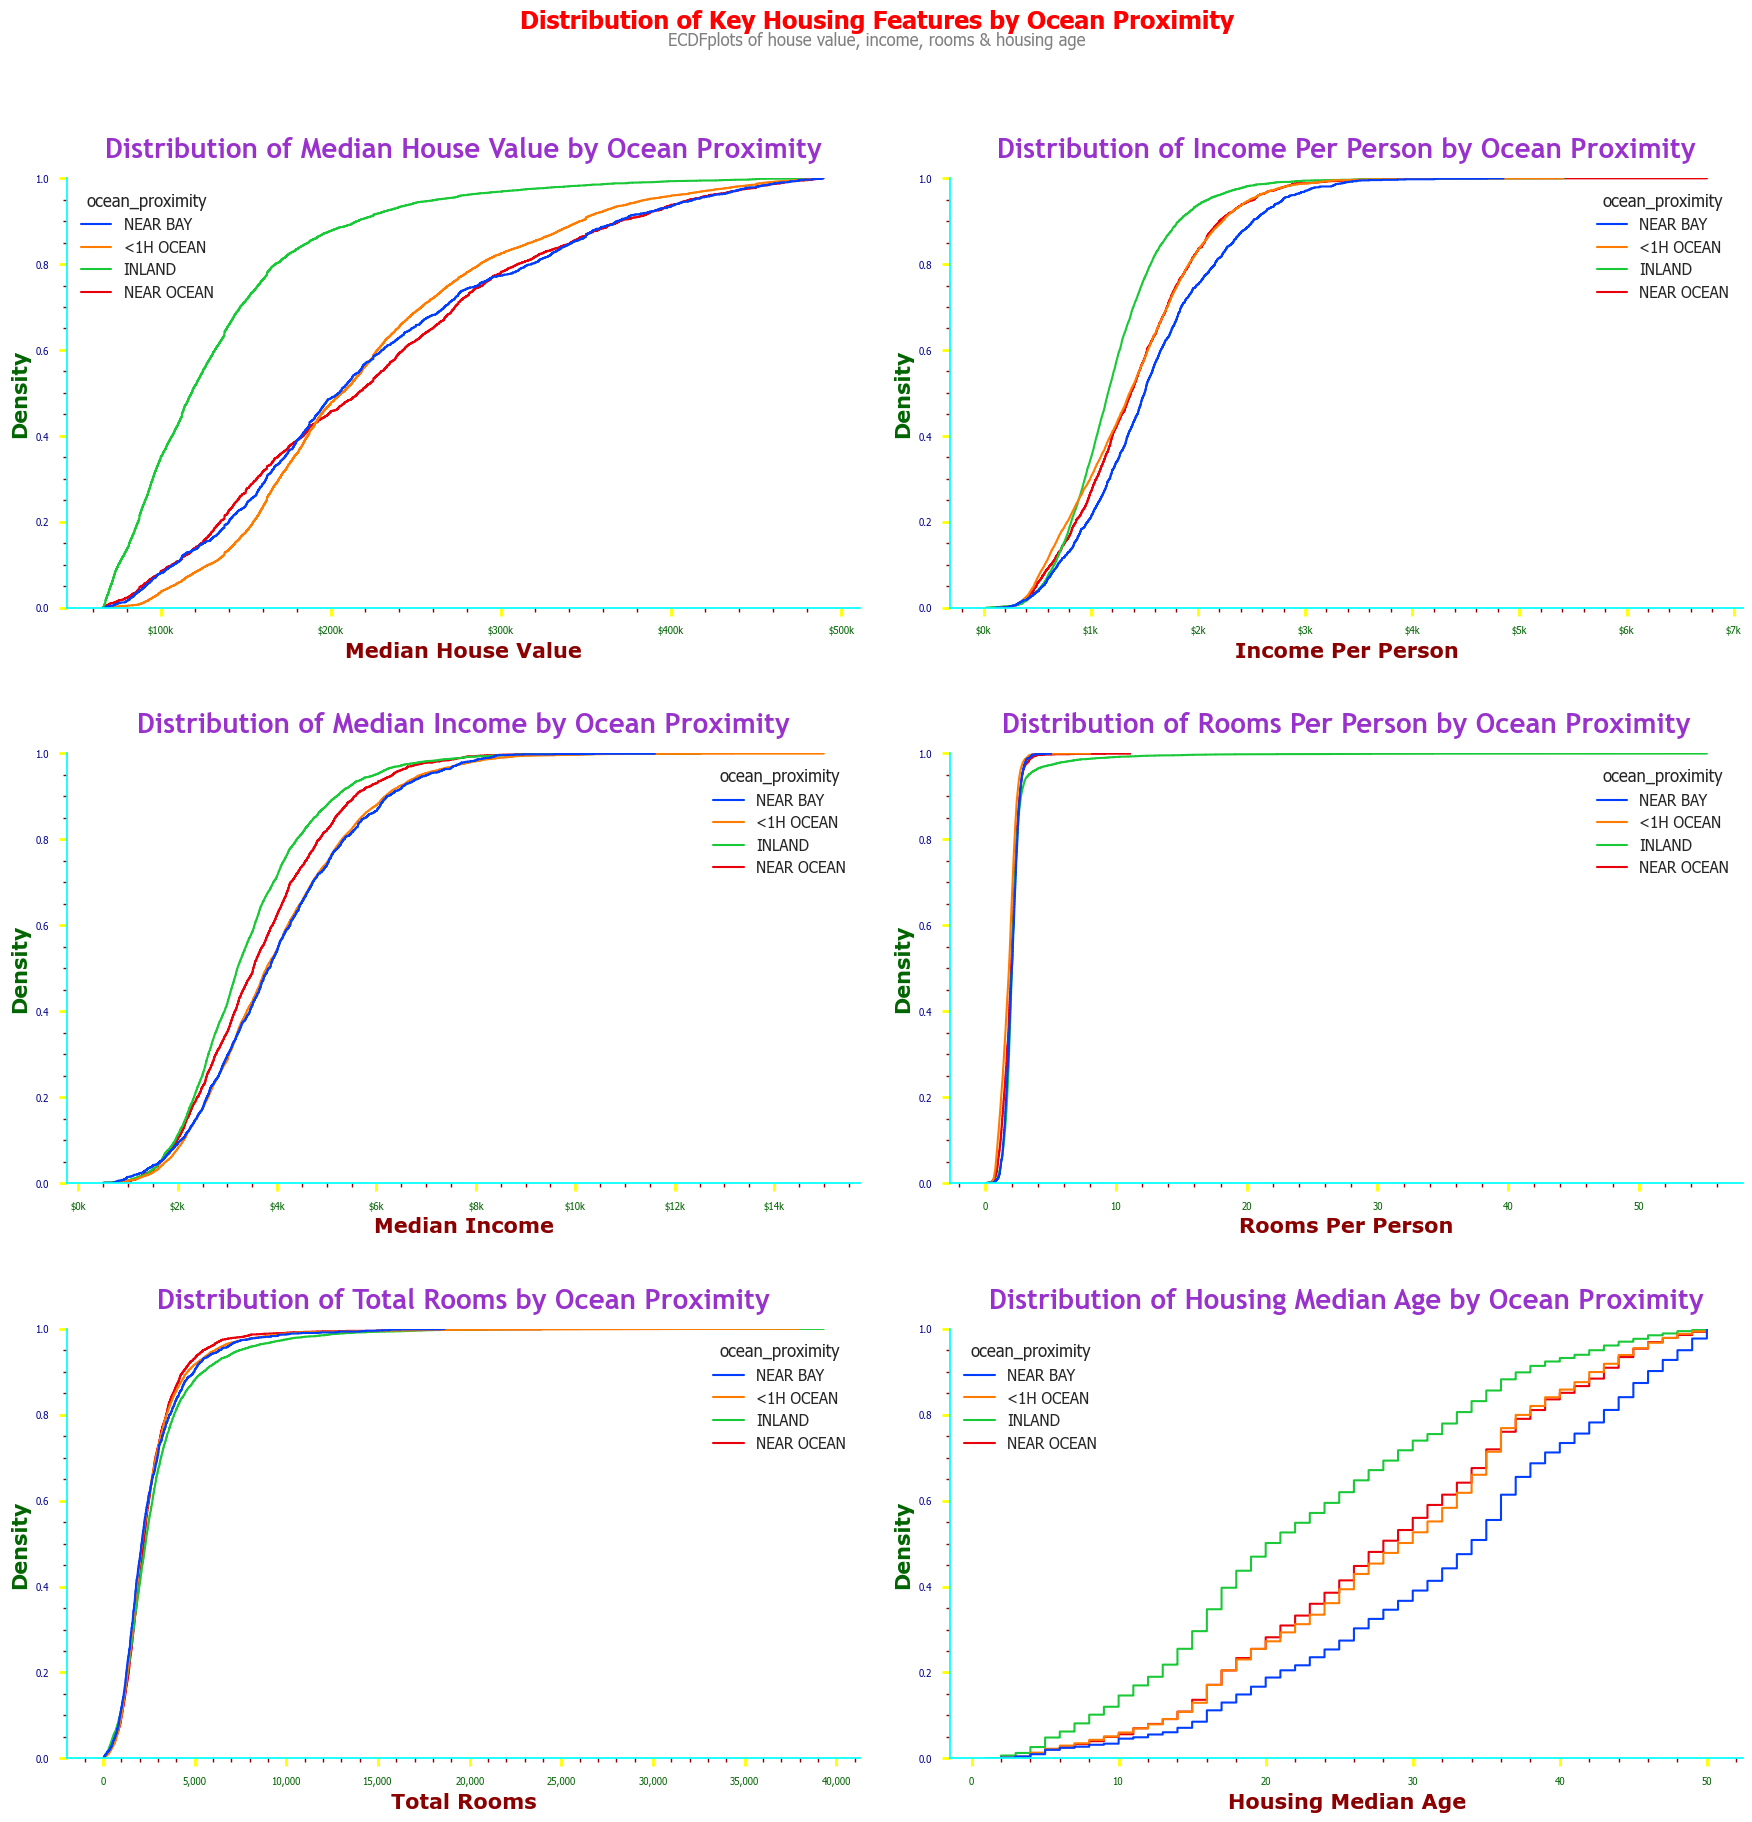

In [417]:
# ── Formatter Functions ───────────────────────────────────────────────────────
def dollar_k_formatter(x, pos):
    """e.g. \$100k, \$200k"""
    return f'${x/1000:,.0f}k'

def dollar_formatter(x, pos):
    """e.g. \$100, \$200"""
    return f'${x:,.0f}'

def count_k_formatter(x, pos):
    """e.g. 100k, 200k"""
    return f'{x/1000:,.0f}k'

def count_formatter(x, pos):
    """e.g. 100, 200"""
    return f'{x:,.0f}'

# ── Column Definitions ────────────────────────────────────────────────────────
columns        = ['median_house_value', 'income_per_person', 'median_income', 
                  'rooms_per_person', 'total_rooms', 'housing_median_age']
currency_cols  = ['median_income', 'median_house_value', 'income_per_person']
non_currency_cols = ['rooms_per_person', 'population', 'households', 
                     'total_rooms', 'total_bedrooms']


# ── Grid Layout ───────────────────────────────────────────────────────────────
ncols = 2
nrows = 3   # 3 rows x 2 cols = 6 subplots (one per column)

fig, axes = plt.subplots(ncols=ncols, nrows=nrows, 
                         figsize=(18, nrows * 6), # Dynamically scales figure height
                         facecolor='white', dpi=100)

# ── Main Title & Subtitle ─────────────────────────────────────────────────────
fig.suptitle(
    "Distribution of Key Housing Features by Ocean Proximity",
    fontsize=18, fontweight="bold", fontfamily="Tahoma", color="red",
    y=1.02,
)
fig.text(
    0.5, 1.00,
    "ECDFplots of house value, income, rooms & housing age",
    fontsize=12, fontstyle="italic", fontfamily="Tahoma",
    color="grey", ha="center",
)
# ─────────────────────────────────────────────────────────────────────────────

axes = axes.flatten()  # Flatten 2D array → 1D for easy iteration

# ── Main Loop ─────────────────────────────────────────────────────────────────
for idx, col in enumerate(columns):
    ecdf = axes[idx] # Each column gets its own subplot

    # ── Kde Plot ──────────────────────────────────────────────────────────────
    sns.ecdfplot(data=housing, x=col, hue='ocean_proximity', ax=ecdf)
    
    # ── Titles & Labels ───────────────────────────────────────────────────────
    ecdf.set_title(f'Distribution of {col.replace("_", " ").title()} by Ocean Proximity', # .upper(), .lower(), 'title()
                   fontdict=title_font, pad=15)
    ecdf.set_xlabel(col.replace('_', ' ').title(), fontdict=x_label_font) # .upper(), .lower(), 'title()
    ecdf.set_ylabel('Density', fontdict=y_label_font) # .upper(), .lower(), .title()
    
    # ── Tick Parameters ───────────────────────────────────────────────────────
    ecdf.minorticks_on()
    ecdf.tick_params(axis='x', bottom=True, top=False, length=6, width=2, color='yellow', direction='out', labelsize=7, labelcolor='darkgreen', labelfontfamily='tahoma', labelrotation=None)
    ecdf.tick_params(axis='y', left=True, right=False, length=6, width=2, color='yellow', direction='out', labelsize=7, labelcolor='darkblue', labelfontfamily='tahoma', labelrotation=None)
    ecdf.tick_params(axis='x', which='minor', bottom=True, top=False, length=3, width=1, color='darkred')
    ecdf.tick_params(axis='y', which='minor', left=True, right=False,  length=3, width=1, color='darkred')

    # ── X-Axis Formatter ──────────────────────────────────────────────────────
    if col in currency_cols:
        ecdf.xaxis.set_major_formatter(FuncFormatter(dollar_k_formatter))
    elif col in non_currency_cols:
        ecdf.xaxis.set_major_formatter(FuncFormatter(count_formatter))

# ── Hide Unused Subplots ──────────────────────────────────────────────────────
for j in range(len(columns), len(axes)):
    axes[j].set_visible(False)
    
# ── Adjust subplot params ──────────────────────────────────────────────────────
plt.tight_layout(pad=2, h_pad=3, w_pad=2) # Adds breathing room between subplots

# ── Save plot as png ──────────────────────────────────────────────────────
# # my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\Assets"
# my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\2_Descriptive_Data_Analysis\Assets"
# plt.savefig(my_path + '/Py_00_Ecdfplot.png',transparent=None,dpi='figure',format=None,metadata=None,bbox_inches='tight',pad_inches=0.1,facecolor='auto',edgecolor='yellow',backend=None)

# ── Display plot as png ──────────────────────────────────────────────────────
plt.show()

##### `📊 Boxplot - Distribution Of California Housing Features`.

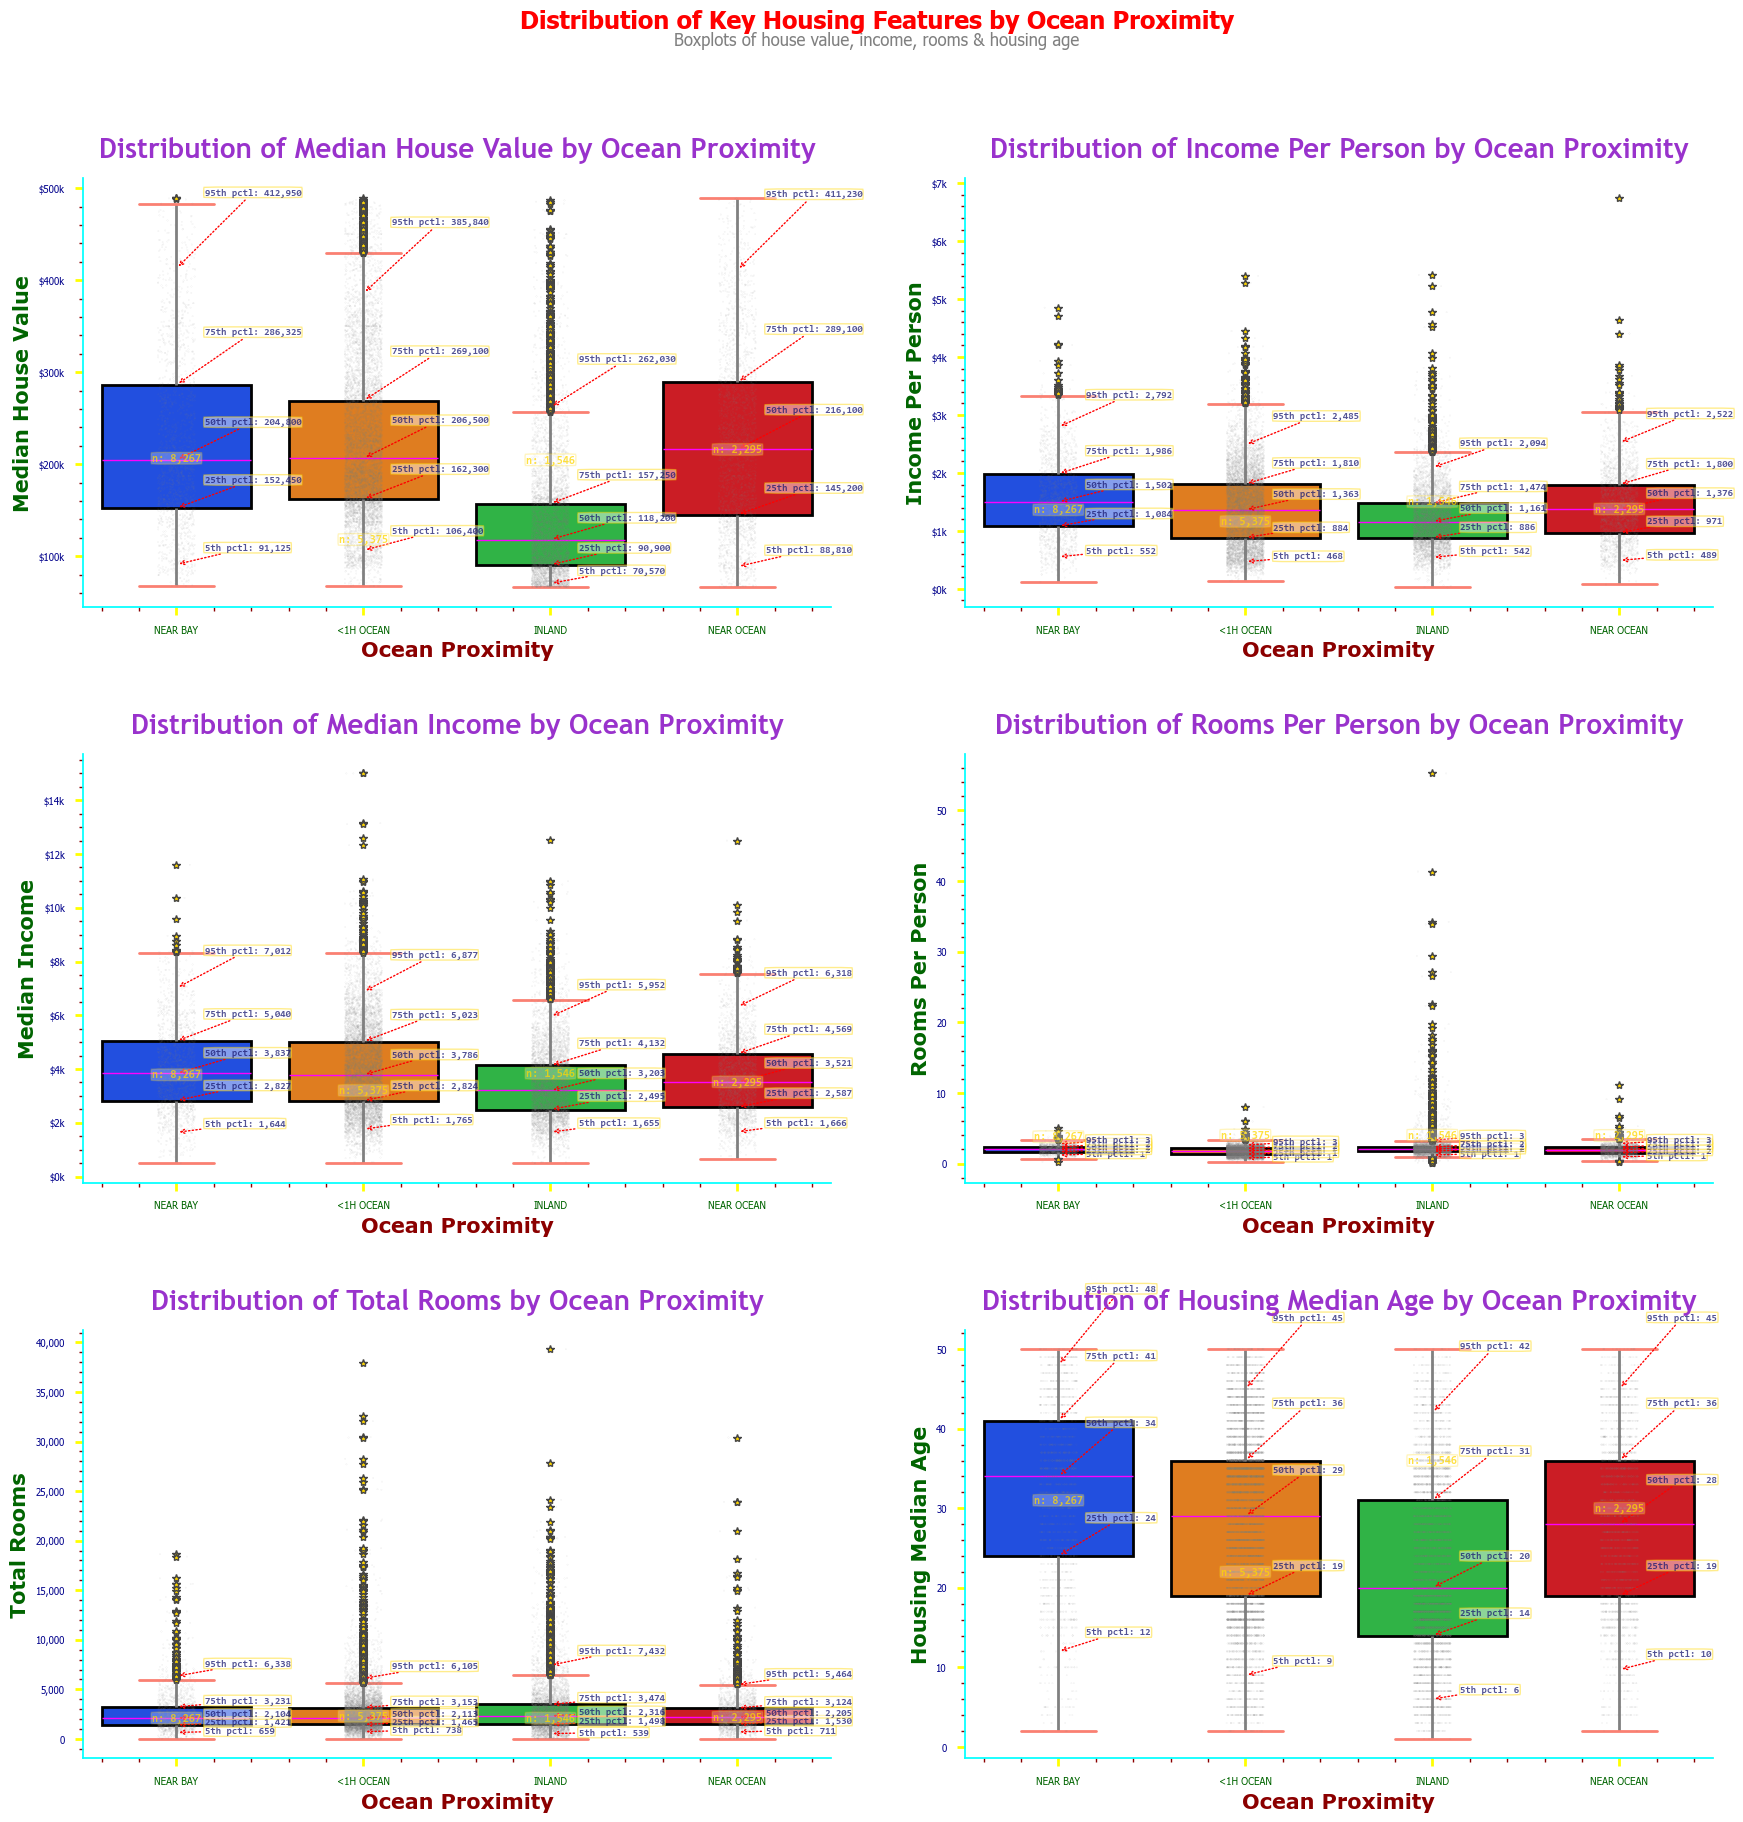

In [418]:
# ── Formatter Functions ───────────────────────────────────────────────────────
def dollar_k_formatter(x, pos):
    """e.g. \$100k, \$200k"""
    return f'${x/1000:,.0f}k'

def dollar_formatter(x, pos):
    """e.g. \$100, \$200"""
    return f'${x:,.0f}'

def count_k_formatter(x, pos):
    """e.g. 100k, 200k"""
    return f'{x/1000:,.0f}k'

def count_formatter(x, pos):
    """e.g. 100, 200"""
    return f'{x:,.0f}'

# ── Column Definitions ────────────────────────────────────────────────────────
columns        = ['median_house_value', 'income_per_person', 'median_income', 
                  'rooms_per_person', 'total_rooms', 'housing_median_age']
currency_cols  = ['median_income', 'median_house_value', 'income_per_person']
non_currency_cols = ['rooms_per_person', 'population', 'households', 
                     'total_rooms', 'total_bedrooms']

# ── Boxplot Style ─────────────────────────────────────────────────────────────
boxplot_style = {
    'flierprops'   : {'marker': '*', 'markerfacecolor': 'gold', 'markersize': 6},
    'capprops'     : {'color': 'salmon', 'linewidth': 2},
    'whiskerprops' : {'color': 'grey', 'linewidth': 2},
    'medianprops'  : {'color': 'magenta', 'linewidth': 1},
    'boxprops'     : {'edgecolor': 'black', 'linewidth': 2},
}
 
# ── Annotation Style Properties ───────────────────────────────────────────────
arrow_props = dict(
    arrowstyle       = "->",
    color            = 'red',
    linewidth        = 1,
    linestyle        = 'dotted',
    alpha            = 1,
    connectionstyle  = 'arc3,rad=0'
)
bbox_props = dict(
    boxstyle   = "round4",
    pad        = 0.1,
    facecolor  = 'white',
    alpha      = 0.45,
    edgecolor  = 'gold'
)
nobs_bbox = dict(
    boxstyle   = "round4",
    pad        = 0.1,
    facecolor  = 'white',
    alpha      = 0.25,
    edgecolor  = 'gold'
)

percentiles = [5, 25, 50, 75, 95]

# ── Grid Layout ───────────────────────────────────────────────────────────────
ncols = 2
nrows = 3   # 3 rows x 2 cols = 6 subplots (one per column)

fig, axes = plt.subplots(ncols=ncols, nrows=nrows, 
                         figsize=(18, nrows * 6), # Dynamically scales figure height
                         facecolor='white', dpi=100)

# ── Main Title & Subtitle ─────────────────────────────────────────────────────
fig.suptitle(
    "Distribution of Key Housing Features by Ocean Proximity",
    fontsize=18, fontweight="bold", fontfamily="Tahoma", color="red",
    y=1.02,
)
fig.text(
    0.5, 1.00,
    "Boxplots of house value, income, rooms & housing age",
    fontsize=12, fontstyle="italic", fontfamily="Tahoma",
    color="grey", ha="center",
)
# ─────────────────────────────────────────────────────────────────────────────

axes = axes.flatten()  # Flatten 2D array → 1D for easy iteration

# ── Main Loop ─────────────────────────────────────────────────────────────────
for idx, col in enumerate(columns):
    bp = axes[idx] # Each column gets its own subplot

    # ── Box Plot ──────────────────────────────────────────────────────────────
    sns.boxplot(data=housing, x='ocean_proximity', y=col, 
                palette='bright', ax=bp, **boxplot_style)
    
    # ── Swarmplot (Beeswarm) ──────────────────────────────────────────────────────────────
    # sns.swarmplot(data=housing, x='ocean_proximity', y=col, hue='ocean_proximity', dodge=False,
    #             palette="dark", size=1, edgecolor="black", linewidth=1, marker='*', alpha=0.75, ax=bp)
    
    # ── Stripplot (Jitter) ──────────────────────────────────────────────────────────────
    sns.stripplot(data=housing, x='ocean_proximity', y=col, hue='ocean_proximity', jitter=True, dodge=False, 
                palette="dark", size=0.10, edgecolor="grey", linewidth=1, marker='.', alpha=0.75, ax=bp)

    # ── Titles & Labels ───────────────────────────────────────────────────────
    bp.set_title(f'Distribution of {col.replace("_", " ").title()} by Ocean Proximity', # .upper(), .lower(), 'title()
                   fontdict=title_font, pad=15)
    bp.set_xlabel('Ocean Proximity', fontdict=x_label_font)
    bp.set_ylabel(col.replace('_', ' ').title(), fontdict=y_label_font) # .upper(), .lower(), .title()

    # ── Tick Parameters ───────────────────────────────────────────────────────
    bp.minorticks_on()
    bp.tick_params(axis='x', bottom=True, top=False, length=6, width=2, color='yellow', direction='out', labelsize=7, labelcolor='darkgreen', labelfontfamily='tahoma', labelrotation=None)
    bp.tick_params(axis='y', left=True, right=False, length=6, width=2, color='yellow', direction='out', labelsize=7, labelcolor='darkblue', labelfontfamily='tahoma', labelrotation=None)
    bp.tick_params(axis='x', which='minor', bottom=True, top=False, length=3, width=1, color='darkred')
    bp.tick_params(axis='y', which='minor', left=True, right=False,  length=3, width=1, color='darkred')

    # ── Y-Axis Formatter ──────────────────────────────────────────────────────
    if col in currency_cols:
        bp.yaxis.set_major_formatter(FuncFormatter(dollar_k_formatter))
    elif col in non_currency_cols:
        bp.yaxis.set_major_formatter(FuncFormatter(count_formatter))

    # ── Percentile Annotations ────────────────────────────────────────────────
    categories = housing['ocean_proximity'].unique()

    for i, category in enumerate(categories):
        subset = housing[housing['ocean_proximity'] == category][col]

        for percentile in percentiles:
            value = np.percentile(subset, percentile)

            bp.annotate(
                f'{percentile}th pctl: {value:,.0f}',
                xy       = (i, value),
                xytext   = (i + 0.15, value + 0.2 * value),
                ha       = 'left',
                va       = 'center',
                family   = 'consolas',
                fontstyle= 'normal',
                fontsize = 7,
                fontweight = 'bold',
                color    = 'midnightblue',
                alpha    = 0.75,
                rotation = None,
                arrowprops = arrow_props,
                bbox       = bbox_props
            )

    # ── Median & Observation Count Annotations ────────────────────────────────
    medians = housing.groupby('ocean_proximity')[col].median()
    nobs    = housing['ocean_proximity'].value_counts().sort_index()

    for op in medians.index:
        pos        = list(medians.index).index(op)
        median_val = medians[op]
        nobs_val   = nobs[op]

        bp.text(
            pos, median_val + 2,
            f"n: {nobs_val:,.0f}",
            ha         = 'center',
            va         = 'center',
            family     = 'consolas',
            fontstyle  = 'normal',
            fontsize   = 8,
            fontweight = 'bold',
            color      = 'gold',
            alpha      = 0.75,
            rotation   = None,
            bbox       = nobs_bbox
        )

# ── Hide Unused Subplots ──────────────────────────────────────────────────────
for j in range(len(columns), len(axes)):
    axes[j].set_visible(False)

# ── Adjust subplot params ──────────────────────────────────────────────────────
plt.tight_layout(pad=2, h_pad=3, w_pad=2) # Adds breathing room between subplots

# ── Save plot as png ──────────────────────────────────────────────────────
# # my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\Assets"
# my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\2_Descriptive_Data_Analysis\Assets"
# plt.savefig(my_path + '/Py_00_Boxplot.png',transparent=None,dpi='figure',format=None,metadata=None,bbox_inches='tight',pad_inches=0.1,facecolor='auto',edgecolor='yellow',backend=None)

# ── Display plot as png ──────────────────────────────────────────────────────
plt.show()

In [419]:
# # ── Column Definitions ────────────────────────────────────────────────────────
# columns        = ['median_house_value', 'income_per_person', 'median_income', 
#                   'rooms_per_person', 'total_rooms', 'housing_median_age']

# # ── Grid Layout ───────────────────────────────────────────────────────────────
# ncols = 2
# nrows = 3   # 3 rows x 2 cols = 6 subplots (one per column)

# fig, axes = plt.subplots(ncols=ncols, nrows=nrows, 
#                          figsize=(18, nrows * 6), # Dynamically scales figure height
#                          facecolor='white', dpi=100)

# axes = axes.flatten()  # Flatten 2D array → 1D for easy iteration

# # ── Main Loop ─────────────────────────────────────────────────────────────────
# for idx, col in enumerate(columns):
#     bp = axes[idx] # Each column gets its own subplot
    
#     # ── Box Plot ──────────────────────────────────────────────────────────────
#     sns.boxplot(data=housing, x='ocean_proximity', y=col, palette='bright', ax=bp)

#     # ── Titles & Labels ───────────────────────────────────────────────────────
#     bp.set_title(f'Distribution of {(col.replace('_', ' ').title())} by Ocean Proximity',fontdict=title_font, pad=10) # .upper(), .lower(), 'title()
#     bp.set_xlabel('Ocean Proximity', fontdict=x_label_font)
#     bp.set_ylabel(col.replace('_', ' ').title(), fontdict=y_label_font) # .upper(), .lower(), .title()

#     # ── Tick Parameters ───────────────────────────────────────────────────────
#     bp.minorticks_on()
#     bp.tick_params(axis='x', labelsize=7.5, labelrotation=0)
#     bp.tick_params(axis='y', labelrotation=0)
#     bp.tick_params(axis='x', which='minor', bottom=True, length=3, width=1, color='darkred')
#     bp.tick_params(axis='y', which='minor', left=True,   length=3, width=1, color='darkred')

# # ── Hide Unused Subplots ──────────────────────────────────────────────────────
# for j in range(len(columns), len(axes)):
#     axes[j].set_visible(False)

# plt.tight_layout(pad=2, h_pad=3, w_pad=2) # Adds breathing room between subplots    
# plt.show()

##### `📊 Stripplot - Distribution Of California Housing Features`.

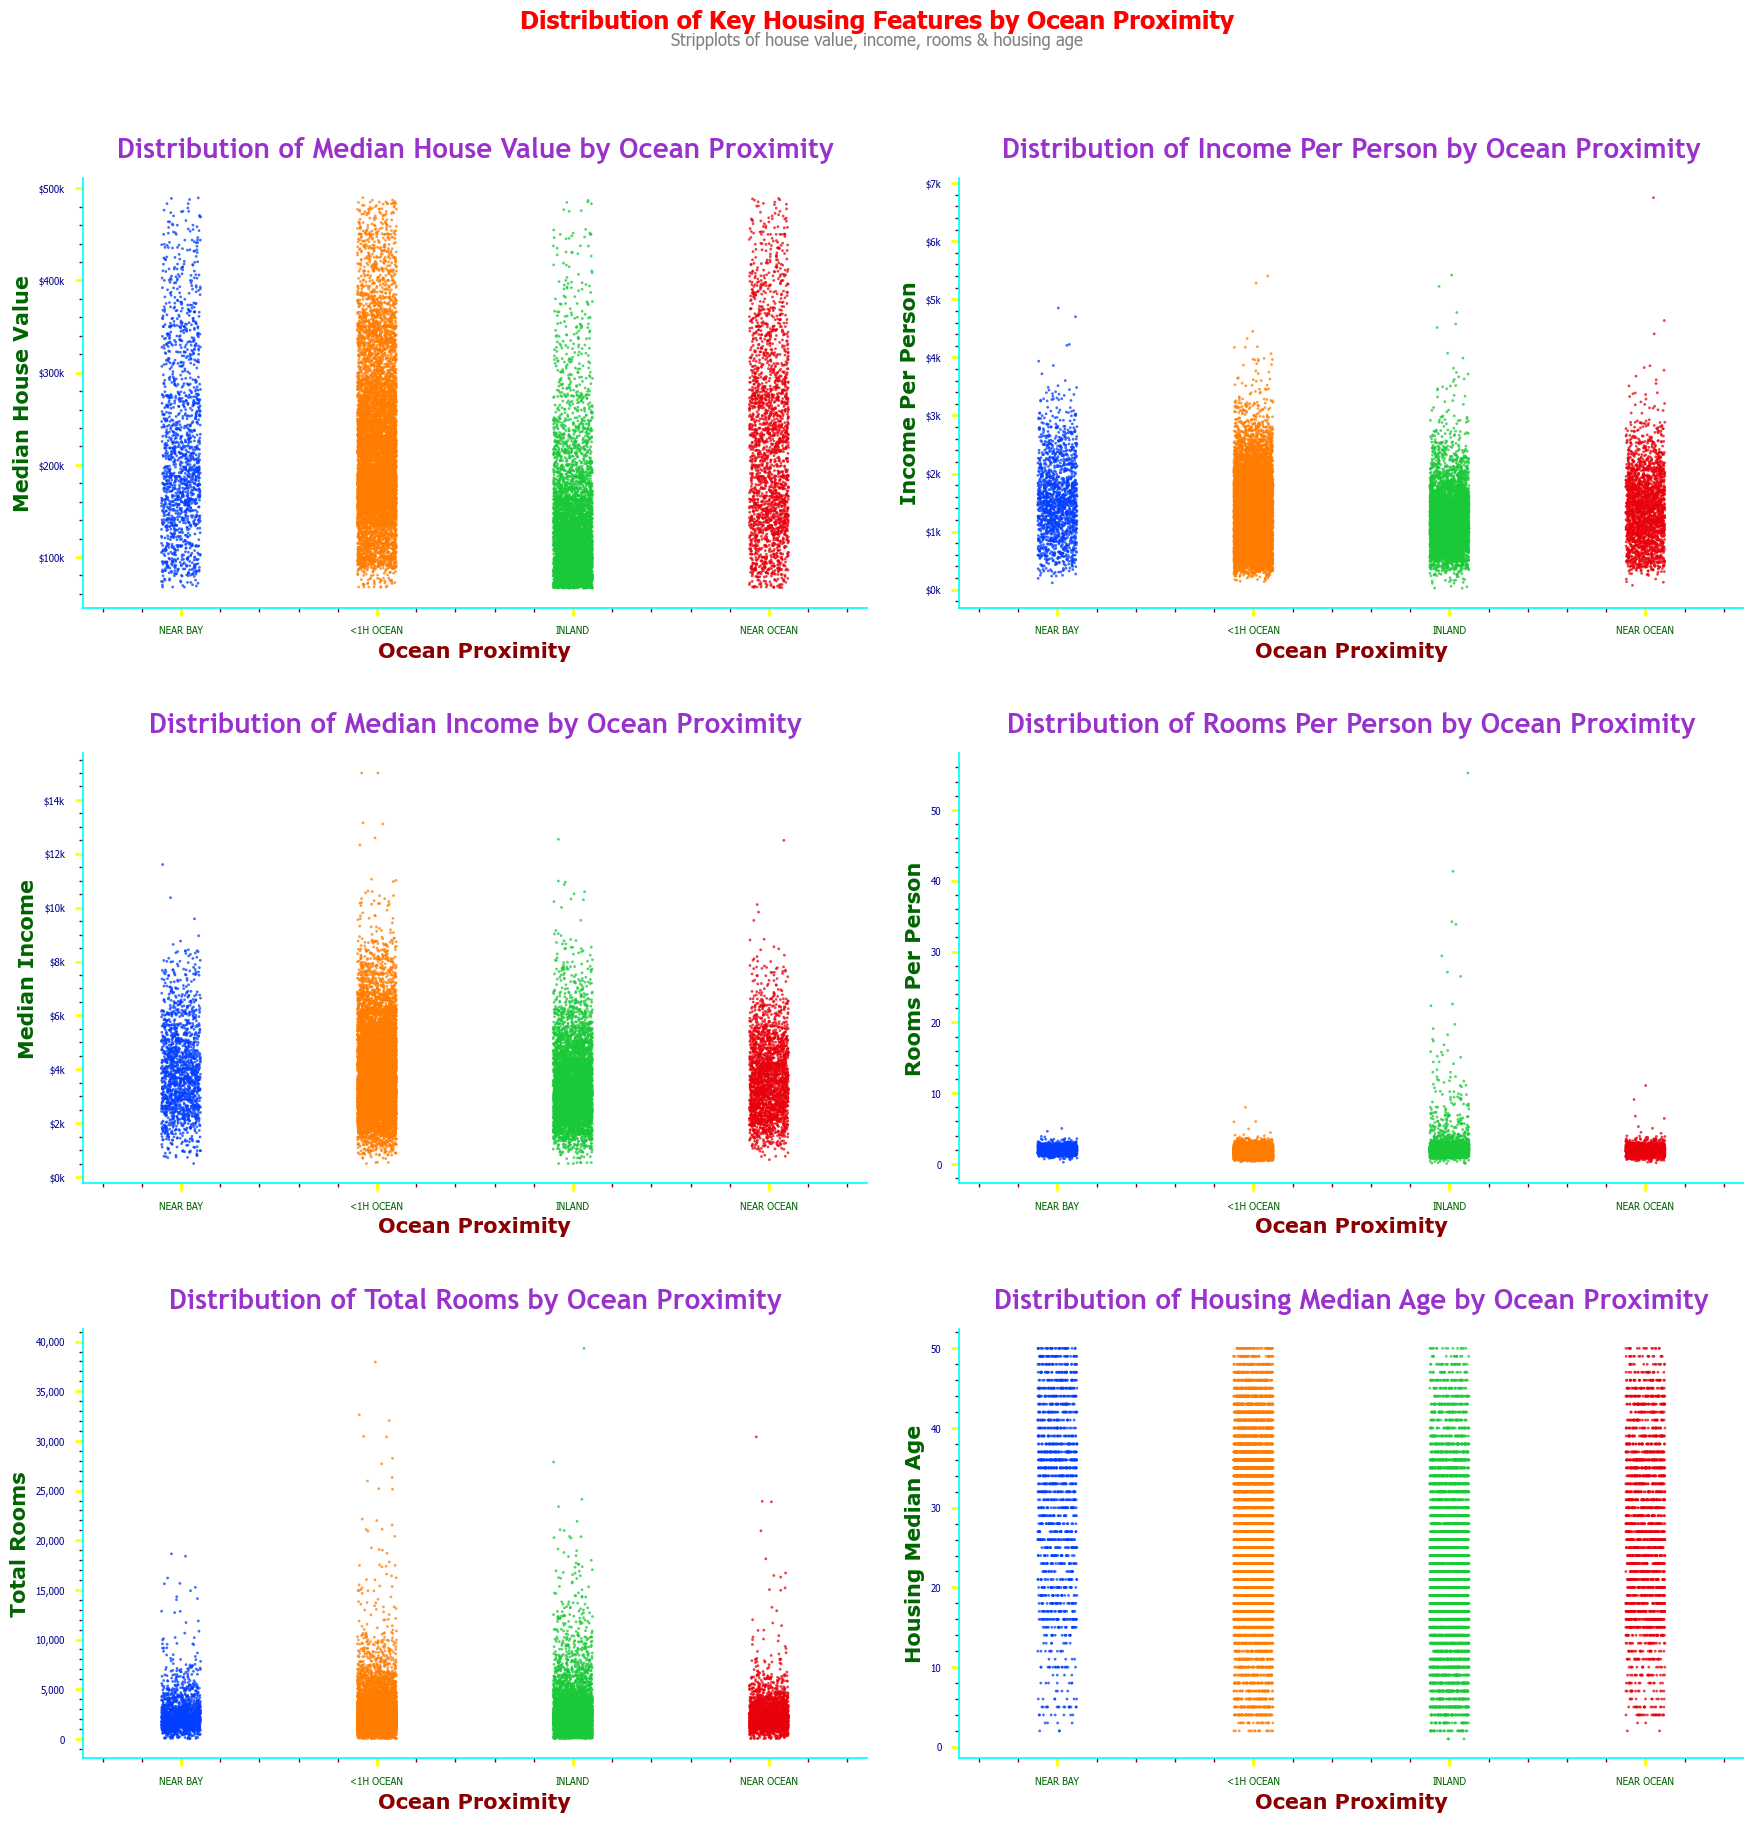

In [420]:
# ── Formatter Functions ───────────────────────────────────────────────────────
def dollar_k_formatter(x, pos):
    """e.g. \$100k, \$200k"""
    return f'${x/1000:,.0f}k'

def dollar_formatter(x, pos):
    """e.g. \$100, \$200"""
    return f'${x:,.0f}'

def count_k_formatter(x, pos):
    """e.g. 100k, 200k"""
    return f'{x/1000:,.0f}k'

def count_formatter(x, pos):
    """e.g. 100, 200"""
    return f'{x:,.0f}'

# ── Column Definitions ────────────────────────────────────────────────────────
columns        = ['median_house_value', 'income_per_person', 'median_income', 
                  'rooms_per_person', 'total_rooms', 'housing_median_age']
currency_cols  = ['median_income', 'median_house_value', 'income_per_person']
non_currency_cols = ['rooms_per_person', 'population', 'households', 
                     'total_rooms', 'total_bedrooms']

# # ── Boxplot Style ─────────────────────────────────────────────────────────────
# boxplot_style = {
#     'flierprops'   : {'marker': '*', 'markerfacecolor': 'gold', 'markersize': 6},
#     'capprops'     : {'color': 'salmon', 'linewidth': 2},
#     'whiskerprops' : {'color': 'grey', 'linewidth': 2},
#     'medianprops'  : {'color': 'magenta', 'linewidth': 1},
#     'boxprops'     : {'edgecolor': 'black', 'linewidth': 2},
# }
 
# # ── Annotation Style Properties ───────────────────────────────────────────────
# arrow_props = dict(
#     arrowstyle       = "->",
#     color            = 'red',
#     linewidth        = 1,
#     linestyle        = 'dotted',
#     alpha            = 1,
#     connectionstyle  = 'arc3,rad=0'
# )
# bbox_props = dict(
#     boxstyle   = "round4",
#     pad        = 0.1,
#     facecolor  = 'white',
#     alpha      = 0.45,
#     edgecolor  = 'gold'
# )
# nobs_bbox = dict(
#     boxstyle   = "round4",
#     pad        = 0.1,
#     facecolor  = 'white',
#     alpha      = 0.25,
#     edgecolor  = 'gold'
# )

# percentiles = [5, 25, 50, 75, 95]

# ── Grid Layout ───────────────────────────────────────────────────────────────
ncols = 2
nrows = 3   # 3 rows x 2 cols = 6 subplots (one per column)

fig, axes = plt.subplots(ncols=ncols, nrows=nrows, 
                         figsize=(18, nrows * 6), # Dynamically scales figure height
                         facecolor='white', dpi=100)

# ── Main Title & Subtitle ─────────────────────────────────────────────────────
fig.suptitle(
    "Distribution of Key Housing Features by Ocean Proximity",
    fontsize=18, fontweight="bold", fontfamily="Tahoma", color="red",
    y=1.02,
)
fig.text(
    0.5, 1.00,
    "Stripplots of house value, income, rooms & housing age",
    fontsize=12, fontstyle="italic", fontfamily="Tahoma",
    color="grey", ha="center",
)
# ─────────────────────────────────────────────────────────────────────────────

axes = axes.flatten()  # Flatten 2D array → 1D for easy iteration

# ── Main Loop ─────────────────────────────────────────────────────────────────
for idx, col in enumerate(columns):
    stripplot = axes[idx] # Each column gets its own subplot

    # ── Stripplot ──────────────────────────────────────────────────────────────
    sns.stripplot(data=housing, x='ocean_proximity', y=col, hue='ocean_proximity', jitter=True, dodge=False, 
                  palette='bright', size=4, marker='.', alpha=0.75, ax=stripplot)

    # ── Titles & Labels ───────────────────────────────────────────────────────
    stripplot.set_title(f'Distribution of {col.replace("_", " ").title()} by Ocean Proximity', # .upper(), .lower(), 'title()
                   fontdict=title_font, pad=15)
    stripplot.set_xlabel('Ocean Proximity', fontdict=x_label_font)
    stripplot.set_ylabel(col.replace('_', ' ').title(), fontdict=y_label_font) # .upper(), .lower(), .title()

    # ── Tick Parameters ───────────────────────────────────────────────────────
    stripplot.minorticks_on()
    stripplot.tick_params(axis='x', bottom=True, top=False, length=6, width=2, color='yellow', direction='out', labelsize=7, labelcolor='darkgreen', labelfontfamily='tahoma', labelrotation=None)
    stripplot.tick_params(axis='y', left=True, right=False, length=6, width=2, color='yellow', direction='out', labelsize=7, labelcolor='darkblue', labelfontfamily='tahoma', labelrotation=None)
    stripplot.tick_params(axis='x', which='minor', bottom=True, top=False, length=3, width=1, color='darkred')
    stripplot.tick_params(axis='y', which='minor', left=True, right=False,  length=3, width=1, color='darkred')

    # ── Y-Axis Formatter ──────────────────────────────────────────────────────
    if col in currency_cols:
        stripplot.yaxis.set_major_formatter(FuncFormatter(dollar_k_formatter))
    elif col in non_currency_cols:
        stripplot.yaxis.set_major_formatter(FuncFormatter(count_formatter))

    # # ── Percentile Annotations ────────────────────────────────────────────────
    # categories = housing['ocean_proximity'].unique()

    # for i, category in enumerate(categories):
    #     subset = housing[housing['ocean_proximity'] == category][col]

    #     for percentile in percentiles:
    #         value = np.percentile(subset, percentile)

    #         stripplot.annotate(
    #             f'{percentile}th pctl: {value:,.0f}',
    #             xy       = (i, value),
    #             xytext   = (i + 0.15, value + 0.2 * value),
    #             ha       = 'left',
    #             va       = 'center',
    #             family   = 'consolas',
    #             fontstyle= 'normal',
    #             fontsize = 7,
    #             fontweight = 'bold',
    #             color    = 'midnightblue',
    #             alpha    = 0.75,
    #             rotation = None,
    #             arrowprops = arrow_props,
    #             bbox       = bbox_props
    #         )

    # # ── Median & Observation Count Annotations ────────────────────────────────
    # medians = housing.groupby('ocean_proximity')[col].median()
    # nobs    = housing['ocean_proximity'].value_counts().sort_index()

    # for op in medians.index:
    #     pos        = list(medians.index).index(op)
    #     median_val = medians[op]
    #     nobs_val   = nobs[op]

    #     stripplot.text(
    #         pos, median_val + 2,
    #         f"n: {nobs_val:,.0f}",
    #         ha         = 'center',
    #         va         = 'center',
    #         family     = 'consolas',
    #         fontstyle  = 'normal',
    #         fontsize   = 8,
    #         fontweight = 'bold',
    #         color      = 'gold',
    #         alpha      = 0.75,
    #         rotation   = None,
    #         bbox       = nobs_bbox
    #     )

# ── Hide Unused Subplots ──────────────────────────────────────────────────────
for j in range(len(columns), len(axes)):
    axes[j].set_visible(False)

# ── Adjust subplot params ──────────────────────────────────────────────────────
plt.tight_layout(pad=2, h_pad=3, w_pad=2) # Adds breathing room between subplots

# ── Save plot as png ──────────────────────────────────────────────────────
# # my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\Assets"
# my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\2_Descriptive_Data_Analysis\Assets"
# plt.savefig(my_path + '/Py_00_Stripplot.png',transparent=None,dpi='figure',format=None,metadata=None,bbox_inches='tight',pad_inches=0.1,facecolor='auto',edgecolor='yellow',backend=None)

# ── Display plot as png ──────────────────────────────────────────────────────
plt.show()

##### `📊 Barplot - Ocean Proximity Statistics`.

**`Calculate Statitics`**.

In [462]:
ln = (housing["ocean_proximity"].value_counts().to_frame("count").reset_index()\
.assign(proportion=lambda x: x["count"] / x["count"].sum())
)
ln

# # Styled - Not for plotting
# ln = (housing["ocean_proximity"].value_counts().to_frame("count").reset_index()\
# .assign(proportion=lambda x: x["count"] / x["count"].sum())\
# .style.format({"count": "{:,.0f}","proportion": "{:.2%}"})
# )
# ln

# opp = housing_full["ocean_proximity"].value_counts(normalize=True).to_frame().reset_index().style.format({"proportion": "{:,.2%}"})
# opp

# housing_full["ocean_proximity"].value_counts().reset_index()

,ocean_proximity,count,proportion
0,<1H OCEAN,8267,0.472859
1,INLAND,5375,0.307442
2,NEAR OCEAN,2295,0.131270
3,NEAR BAY,1546,0.088429


**`Barplot - Ocean Proximity Statistics`**.

'<1H OCEAN' - 1st, 8,267, 47.29%
'INLAND' - 2nd, 5,375, 30.74%
'NEAR OCEAN' - 3rd, 2,295, 13.13%


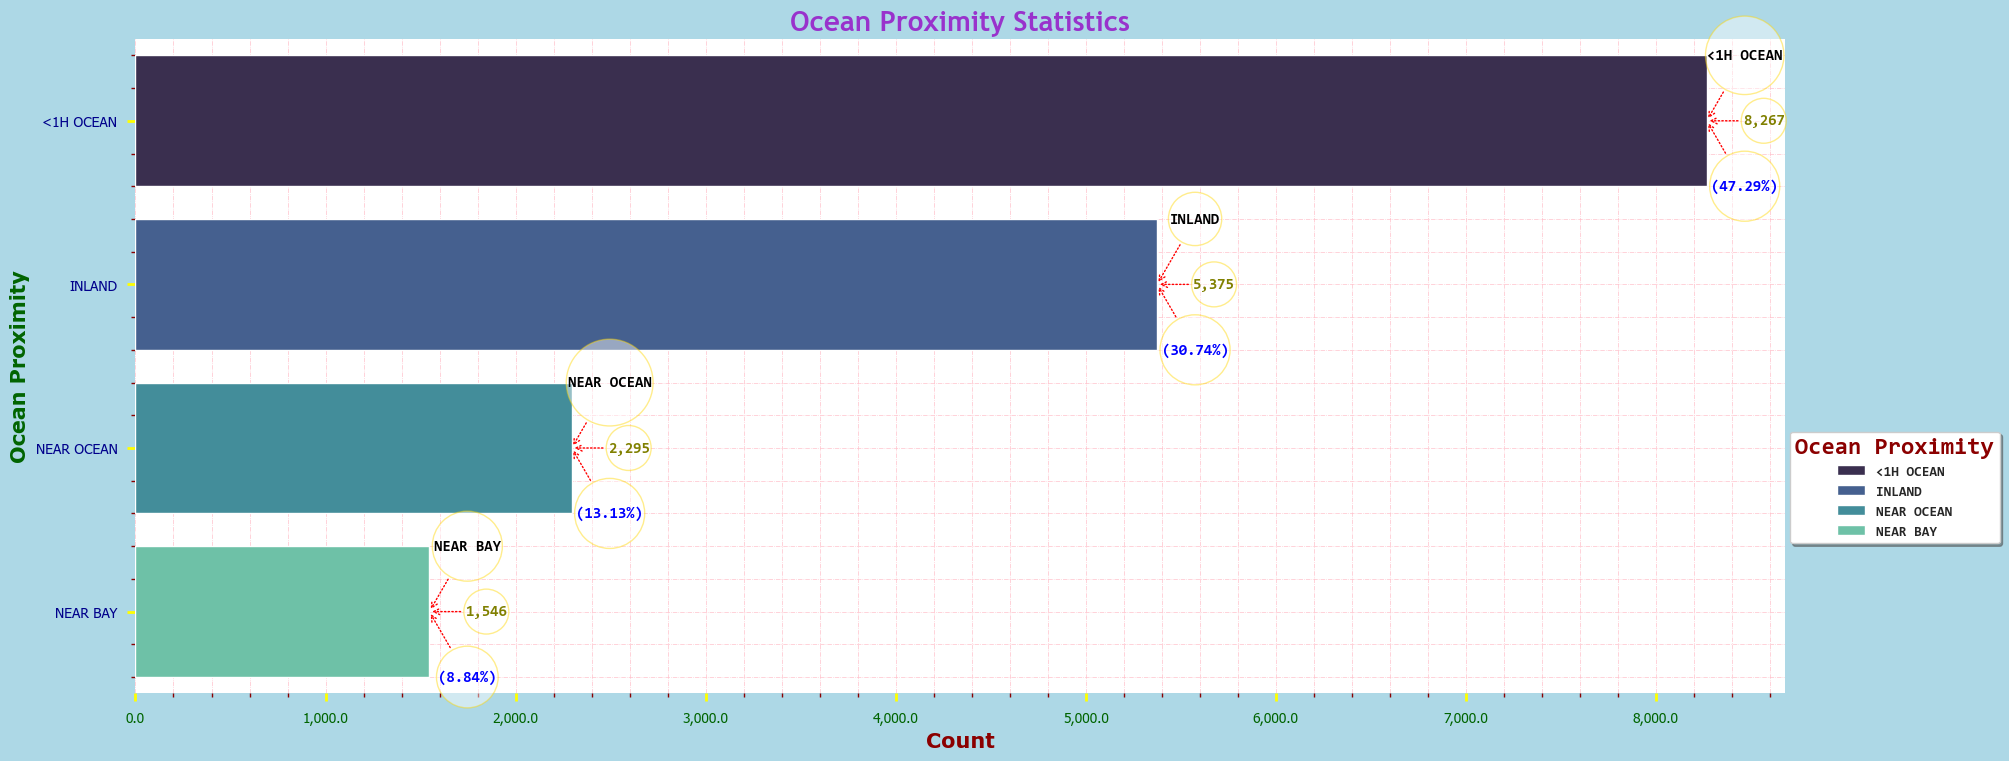

In [463]:
# Barplot - Ocean Proximity Statistics.

# Step 1: Prepare plot
fig, bplot = plt.subplots(ncols=1,nrows=1,figsize=(5,5),layout='constrained',facecolor='lightblue',dpi=100)

#==#


# Step 2: Plot 'count  ' vs 'category'
sns.barplot(data=ln,x=ln['count'],y=ln['ocean_proximity'],
hue=ln['ocean_proximity'],order=ln['ocean_proximity'],hue_order=ln['ocean_proximity'], 
estimator='mean',errorbar=('ci', 95),n_boot=1000,seed=None,units=None,weights=None,orient=None,color=None, 
palette='mako',saturation=0.75,fill=True,hue_norm=None,width=0.8,dodge=None,gap=0,log_scale=None,native_scale=False, 
formatter=None,legend='full',capsize=0,err_kws=None,ci='deprecated',errcolor=None,ax=bplot) # palette: mako, viridis, rocket, plasma, inferno, flare_r, cubehelix display big data with more visual variety

#==#

# Step 3: Set figure size, title, labels, formatter, ticks, spines, facecolor, grid & legend
bplot.figure.set_size_inches(20,7.5)
bplot.set_title('Ocean Proximity Statistics',loc='center',fontdict=title_font)
bplot.set_xlabel('Count',loc='center',fontdict=x_label_font)
bplot.set_ylabel('Ocean Proximity',loc='center',fontdict=y_label_font)
bplot.xaxis.set_major_formatter(StrMethodFormatter('{x:,}'))
# bplot.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0%}'))

bplot.tick_params(axis='x', bottom=True, top=False, length=6, width=2, color='yellow', direction='out', labelsize=10, labelcolor='darkgreen', labelfontfamily='tahoma', labelrotation=None)
bplot.tick_params(axis='y', left=True, right=False, length=6, width=2, color='yellow', direction='out', labelsize=10, labelcolor='darkblue', labelfontfamily='tahoma', labelrotation=None)
bplot.tick_params(axis='x', which='minor', bottom=True, top=False, length=3, width=1, color='darkred')
bplot.tick_params(axis='y', which='minor', left=True, right=False,  length=3, width=1, color='darkred')

bplot.minorticks_on()

bplot.spines[['top','right']].set_visible(False)
bplot.spines[['bottom','left']].set_visible(False)

bplot.set_facecolor('white')

bplot.grid(which='both',linestyle='dashdot',color='pink',linewidth=0.5)

# bplot.autoscale()
# bplot.axis('equal')
# bplot.set_xlim(left=0)
# bplot.set_ylim(bottom=0)
# bplot.set_ylim(0,355000)
# bplot.set_xscale('log')
# bplot.set_yscale('log')
# bplot.set_yscale('linear')  # Try removing log scale

title_props=dict(family='consolas',style='normal',weight='bold',size='x-large')
legend_props=dict(family='consolas',style='normal',weight='bold',size='small')
legend = bplot.legend(loc='best',bbox_to_anchor=(1.13, 0.4),borderaxespad=0,title='Ocean Proximity',title_fontproperties=title_props,prop=legend_props,frameon=True,shadow=True,fancybox=True)
legend.get_title().set_color("darkred")

#==#

# Step 4: Annotate ocean_proximity, count & percentage share in arrow & bbox circle format - Category, Count & %

# Annotation format properties
arrow = dict(arrowstyle="->",color='red',mutation_aspect=1,linewidth=1,linestyle='dotted',capstyle='round',joinstyle='round',alpha=1,connectionstyle='arc3,rad=0')
box=dict(boxstyle="circle",pad=0.1,facecolor='white',alpha=0.45,edgecolor='gold')

# Unique item categories
items = ln['ocean_proximity'].unique().tolist()

# Annotate ocean_proximity in arrow & bbox circle format - Category
for index, row in ln.iloc[:].iterrows(): # Use [:-1] to skip last row if needed
    item = row['ocean_proximity'] # Extract item name
    if item in items:
        y_coord = items.index(item) # map item to y coordinate
        bplot.annotate(text=f"{item}",
        xy=(row['count'], y_coord), xytext=(row['count'] + 200, y_coord - 0.40), # (row['count'] + > 1 for right, < 1 for left), (y_coord + > 1 for down, < 1 for up) 
        color='black',
        ha='center', va='center', family='consolas', fontstyle='normal',
        fontsize=11, fontweight='bold', rotation=0,
        bbox=box, arrowprops=arrow)

# Annotate count in arrow & bbox circle format - Count
for index, row in ln.iloc[:].iterrows(): # Use [:-1] to exclude last row if needed
    if not pd.isna(row['count']): # Only annotate if count is not NaN
        item = row['ocean_proximity'] # Extract item name
        if item in items:
            y_coord = items.index(item) # map item to y coordinate
            bplot.annotate(text=f'{row['count']:,.0f}', 
            xy=(row['count'], y_coord), xytext=(row['count'] + 300 , y_coord + 0.0), # (row['count'] + > 1 for right, < 1 for left), (y_coord + > 1 for down, < 1 for up) 
            color='olive' if row['count'] >= 0 else 'red',
            ha='center', va='center',
            family='consolas', fontstyle='normal',
            fontsize=11, fontweight='bold', rotation=0,
            bbox=box, arrowprops=arrow)

# Annotate proportion in arrow & bbox circle format - %
for index, row in ln.iloc[:].iterrows(): # [:-1] - Exclude last row ('Total')
    if not pd.isna(row['proportion']): # Only annotate if pct_total_sales is not NaN
        item = row['ocean_proximity'] # Extract item name
        if item in items:
            y_coord = items.index(item) # map item to y coordinate
            bplot.annotate(text=f'({row['proportion']:,.2%})', 
            xy=(row['count'], y_coord), xytext=(row['count'] + 200 , y_coord + 0.40), # (row['count'] + > 1 for right, < 1 for left), (y_coord + > 1 for down, < 1 for up) 
            color='blue' if row['proportion']>=0 else 'red',
            ha='center', va='center', family='consolas', fontstyle='normal', 
            fontsize=11, fontweight='bold',rotation=0,
            bbox=box, arrowprops=arrow)

#==#

# Step 5: Annotate rank, count & category of top sales in arrow & bbox round format - Rank, Count & Category

# Remove rows where 'ocean_proximity' or 'count' is NaN
df_clean = ln.dropna(subset=['ocean_proximity', 'count', 'proportion'])

# Sort by count in descending order and select top 3
top_counts = df_clean.sort_values(by='count', ascending=False).head(3)

# Display the top 3 highest counts
for i, row in top_counts.iterrows():
    rank = ['1st', '2nd', '3rd'][top_counts.index.get_loc(i)]
    print(f"'{row['ocean_proximity']}' - {rank}, {row['count']:,.0f}, {row['proportion']:,.2%}")

# Build the annotation string by joining multiple lines with newline characters
annotation_text = '\n'.join([
    f"{['1st', '2nd', '3rd'][i]} | {row['ocean_proximity']} | {row['count']:,.0f} | {row['proportion']:,.2%}" # select ranking label, count & category
    for i, row in top_counts.reset_index(drop=True).iterrows()]) # Reset the index to 0, 1, 2 so i aligns with '1st', '2nd', '3rd'.

# Annotate text to axes in arrow format
bplot.annotate(annotation_text,xy=(8000, 4),xytext=(8000, 4),
            ha='center',va='bottom', 
            family='consolas',fontstyle='italic',fontsize=14,fontweight='bold', 
            color='brown',rotation=0,
            bbox=dict(boxstyle='round',facecolor='yellow',alpha=0.5,edgecolor='gold'),arrowprops=dict(facecolor='red',shrink=0.05))  

#==#

# # Step 6: Save plot as png
# # my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\Assets"
# my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\2_Descriptive_Data_Analysis\Assets"
# plt.savefig(my_path + '/Py_00_Ocean_Proximity_Statistics_Barplot.png',transparent=None,dpi='figure',format=None,metadata=None,bbox_inches='tight',pad_inches=0.1,facecolor='auto',edgecolor='yellow',backend=None)

#==#

# Step 7: Display plot
plt.show()

#### `📈 📉 Bivariate Analysis`.

- **`The analysis of two variables, for the purpose of determining the empirical relationship between them`**. 
- **`It can be helpful in testing simple hypotheses of association`**.
- --

**`👁️⃤ Correlation Matix` - `Correlation Analysis Of Key Metrics`**.
- --
- **`We use a correlation matrix to`**:
  - **`Identify patterns and trends in your data`**.
  - **`Understand the relationships between variables`**.
  - **`Test hypotheses about the relationships between variables`**.
  - **`Build predictive models`**.
- --

**`Step 1`: Display dataframe statistics to identify our `target variable`**.

In [423]:
housing.describe()

,longitude,latitude,population,households,total_rooms,total_bedrooms,people_per_house,rooms_per_house,rooms_per_person,income_per_person,bedrooms_ratio,housing_median_age,median_income,median_house_value,MHV_cluster,price_cluster,wealth_cluster,geo_cluster,market_segment_cluster,Cluster
count,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000,17483.000000
mean,-119.468310,35.521775,1487.633244,517.170737,2721.921066,556.355717,2.968699,5.413871,1.952131,1357.876083,0.212795,26.812904,3789.156455,196252.765544,0.867929,0.868958,0.868958,0.601155,1.920094,4.108048
std,1.982938,2.128271,1176.175883,395.424031,2259.648966,434.936574,1.209135,2.390333,1.143132,612.347312,0.055880,11.449693,1543.169666,91522.959503,0.915115,0.915076,0.915076,0.489675,0.929175,2.850134
min,-124.300000,32.540000,3.000000,2.000000,2.000000,2.000000,0.692308,0.846154,0.061605,25.490196,0.100000,1.000000,499.900000,66200.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-121.605000,33.910000,819.500000,287.000000,1478.000000,304.000000,2.463165,4.441347,1.517024,908.298999,0.175800,17.000000,2653.800000,125700.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
50%,-118.410000,34.190000,1217.000000,423.000000,2190.000000,448.000000,2.847458,5.245136,1.919526,1293.795181,0.201908,27.000000,3563.800000,177400.000000,1.000000,1.000000,1.000000,1.000000,2.000000,5.000000
75%,-117.960000,37.660000,1803.500000,624.000000,3247.000000,668.000000,3.297257,6.022637,2.248211,1726.303052,0.238885,36.000000,4686.950000,247800.000000,2.000000,2.000000,2.000000,1.000000,3.000000,7.000000
max,-114.310000,41.950000,35682.000000,6082.000000,39320.000000,6445.000000,83.171429,132.533333,55.222222,6750.000000,1.000000,50.000000,15000.100000,489800.000000,2.000000,2.000000,2.000000,1.000000,4.000000,9.000000


**`Step 2`: Then compare all key metrics to the target variable - `median_house_value`**.

In [424]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False) # Sorted from highest to lowest.
# corr_matrix # Unsorted.

median_house_value        1.000000
income_per_person         0.679062
median_income             0.634155
MHV_cluster               0.558860
price_cluster             0.558132
wealth_cluster            0.558132
rooms_per_person          0.142806
total_rooms               0.131865
rooms_per_house           0.104243
households                0.078362
geo_cluster               0.071319
total_bedrooms            0.058401
housing_median_age        0.027203
Cluster                   0.018148
population                0.005782
longitude                -0.037052
latitude                 -0.137370
people_per_house         -0.145168
bedrooms_ratio           -0.216261
market_segment_cluster   -0.463555
Name: median_house_value, dtype: float64

**`📊 Key Insights`**:
- --
- **`Strong Positive Correlations`**
  - **income_per_person `(0.6790)` is by far the `strongest predictor` of house value followed by **median_income `(0.6341)`** — `higher income areas` tend to have `significantly more expensive homes`. This is your most important feature**.
- --
- **`Weak Positive Correlations`**
  - **rooms_per_person `(0.1428)` - `More rooms per person ` suggests `less overcrowding`, marginally linked to `higher value`**.
  - **total_rooms `(0.1318)` — `More rooms` suggests `marginally higher value`**.
  - **rooms_per_house `(0.1042)`, households `(0.0783)`, geo_cluster `(0.0713)`, total_bedrooms `(0.0584)` — `Negligible positive relationships`**.
  - **housing_median_age `(0.0272)`, population `(0.0057)`— `Negligible positive relationships`**.
- --
- **`Negative Correlations`**
  - **longitude `(-0.0370)` - `Moving east` correlates with `slightly lower prices`**.
  - **latitude `(-0.1373)` — `Moving north` correlates with `lower prices` (likely reflects California geography)**.
  - **people_per_house `(-0.1451)` — `More people per house` suggests `overcrowding`, weakly linked to `lower values`**.
  - **bedrooms_ratio `(-0.2162)` — `Higher bedroom ratio` correlates with `lower value`**.
  - **market_segment_cluster `(-0.4635)` — X**.
  - **longitude, population, bedroom_ratio, market_segment_cluster — `Very weak negative relationships`**.
  - **(`more bedrooms relative to rooms` = `smaller, cheaper properties`)**.
---
- **`🎯 Conclusion`**
  - **income_per_person `dominates` — `Our anchor feature`**.
  - **population, people_per_house and longitude have `correlations close to 0`, meaning they have `negligible negative relationships` with house prices**.
  - **people_per_house `(-0.1451)` is the `3rd strongest negative predictor` in the dataset**.
  - **bedrooms_ratio `(-0.2162)` is the `2nd strongest negative predictor` in the dataset**. 
  - **market_segment_cluster `(-0.4635)` is the `1st strongest negative predictor` in the dataset**. 
  - **Geographic features `(latitude/longitude)` show `weak linear correlations` individually. However, `combined together` they represent `location` which is a `powerful predictor` of house prices**.

##### `📊 Pairplot - Exploratory Pairwise Analysis - House Value, Median Income & Income Per Person by Ocean Proximity`.

- `Scatter matrix of median_house_value, median_income & income_per_person by Ocean Proximity`.

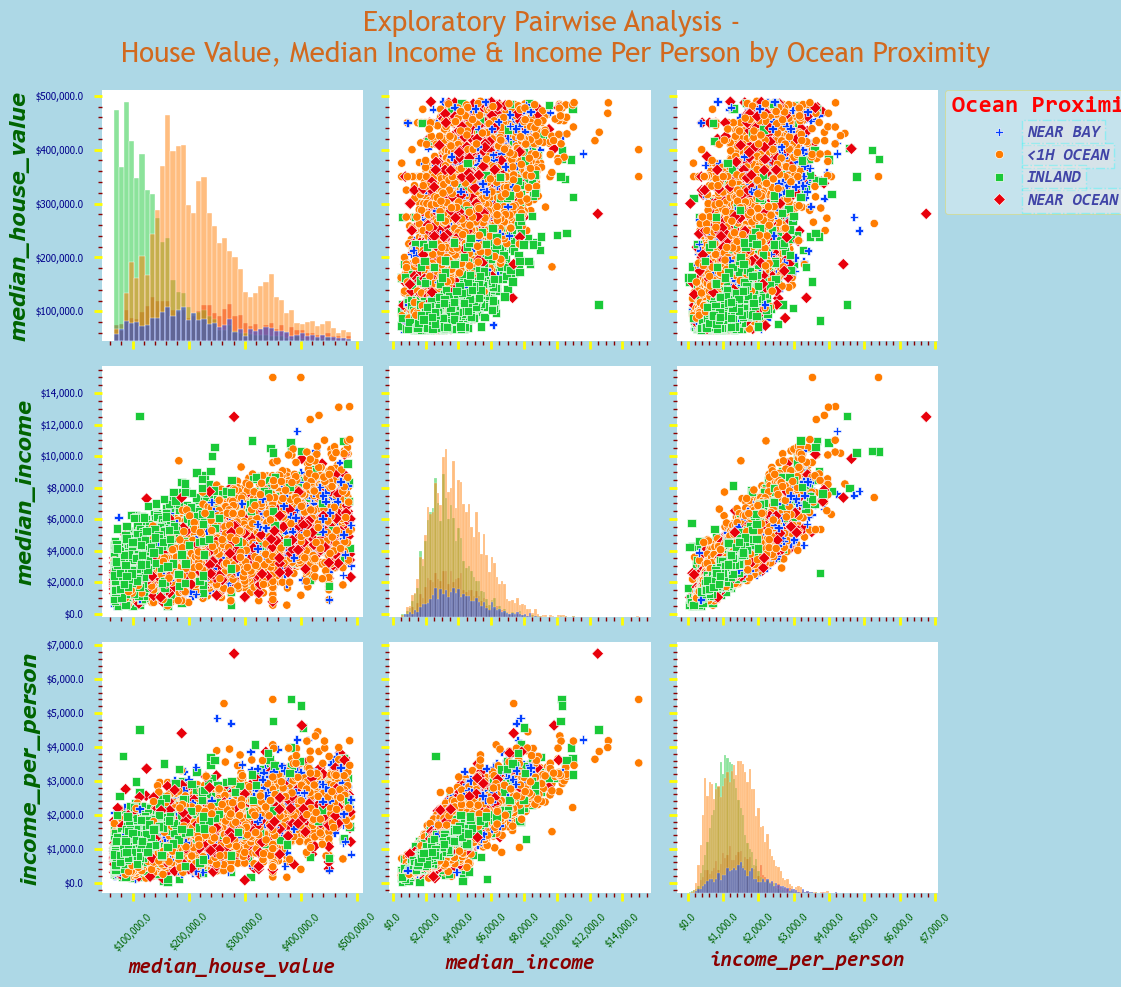

In [425]:
# Pairplot - Exploratory Pairwise Analysis - House Value, Median Income & Income Per Person by Ocean Proximity

# Define numerical values
x_var = ['median_house_value', 'median_income', 'income_per_person']
y_var = ['median_house_value', 'median_income', 'income_per_person']

# Define makers
markers = ["P", "o", "s", "D"]

# Plot pairplot
g = sns.pairplot(data = housing, x_vars=x_var, y_vars=y_var, hue='ocean_proximity', hue_order=None, palette='bright',
kind='scatter', diag_kind='hist', markers=markers, height=2.5, aspect=1, corner=False, dropna=False, plot_kws=None, diag_kws=None, grid_kws=None, size=None)
# diag_kind='auto', 'hist'

# Customize figure size
g.figure.set_size_inches(12, 10)

# Customize suplot positioning & spacing
g.figure.subplots_adjust(left=None,bottom=None,right=None,top=0.9,wspace=0.1,hspace=0.1)

# # Customize figure layout
# g.figure.tight_layout(pad=5,h_pad=1.5,w_pad=1.5,rect=(0, 0, 1, 1)) # ('left','bottom','right','top'))

# Customize suptitle
suptitle_font = {'family':'trebuchet ms','color':'chocolate','style':'normal','weight':'bold'}
g.figure.suptitle("Exploratory Pairwise Analysis - "+"\nHouse Value, Median Income & Income Per Person by Ocean Proximity",size=20,fontdict=suptitle_font)

#==#

# Loop through axes in the pairplot to apply additional settings
for pplot in g.axes.flatten():
    if pplot is not None:  # Check if ax exists (to avoid errors in corner plots)
        
        # Turn on minor ticks
        pplot.minorticks_on()
        
        # Apply the formatter to both axes
        pplot.xaxis.set_major_formatter(StrMethodFormatter('${x:,}'))
        pplot.yaxis.set_major_formatter(StrMethodFormatter('${x:,}'))

        # Set axis label fonts (xlabel)
        pplot.xaxis.label.set_family('consolas')  # Set x-axis label font family
        pplot.xaxis.label.set_style('italic')  # Set x-axis label font style
        pplot.xaxis.label.set_weight('bold')  # Set x-axis label font weight
        pplot.xaxis.label.set_size(15)  # Set x-axis label font size
        pplot.xaxis.label.set_color('darkred')  # Set x-axis label color
        
         # Set axis label fonts (ylabel)
        pplot.yaxis.label.set_family('verdana')  # Set y-axis label font family
        pplot.yaxis.label.set_style('italic')  # Set y-axis label font style
        pplot.yaxis.label.set_weight('bold')  # Set y-axis label font weight
        pplot.yaxis.label.set_size(15)  # Set y-axis label font size
        pplot.yaxis.label.set_color('darkgreen')  # Set y-axis label color
       
        # Major tick settings
        # pplot.tick_params(axis='both',length=13,width=5,colors='chocolate',direction='out',
        # labelfontfamily='tahoma',labelsize='medium',labelcolor='darkblue',labelrotation=None)#grid_linewidth=1)
        pplot.tick_params(axis='x', bottom=True, top=False, length=6, width=2, color='yellow', direction='out', labelsize=7, labelcolor='darkgreen', labelfontfamily='tahoma', labelrotation=45)
        pplot.tick_params(axis='y', left=True, right=False, length=6, width=2, color='yellow', direction='out', labelsize=7, labelcolor='darkblue', labelfontfamily='tahoma', labelrotation=None)
        
        # Minor tick settings
        pplot.tick_params(axis='x', which='minor', bottom=True, top=False, length=3, width=1, color='darkred')
        pplot.tick_params(axis='y', which='minor', left=True, right=False,  length=3, width=1, color='darkred')

        # Hide spines
        pplot.spines['top'].set_visible(False)
        pplot.spines['right'].set_visible(False)
        pplot.spines['bottom'].set_visible(False)
        pplot.spines['left'].set_visible(False)
        
        # Grid settings
        pplot.grid(which='minor',linestyle='dotted',color='white',linewidth=0.5)
        # pplot.autoscale()
        # pplot.axis('equal')
        # pplot.set_xlim(left=0)
        # pplot.set_ylim(bottom=0)
        # pplot.set_xscale('log')
        # pplot.set_yscale('log')

#==#

# Customize the legend
legend = g.legend # Assign variable to legend
legend.set_bbox_to_anchor((0.97, 0.835)) # Set location of bbox_to_anchor [subplots adjust]
# legend.set_bbox_to_anchor((1.06, 0.765)) # Set location of bbox_to_anchor [tight_layout]
# legend.set_bbox_to_anchor((1.06, 0.765)) # Set location of bbox_to_anchor [tight_layout & subplots adjust]
legend.set_title("Ocean Proximity",prop=dict(family='consolas',style='normal',weight='bold',size='x-large')) # Set title & properties
legend.get_title().set_color('red') # Change the color of the legend title separately
legend.get_title().set_alpha(1) # Change alpha of the title appearance
legend.set_frame_on(True) # Set frame
legend.get_frame().set_color('white')  # Set frame color
legend.get_frame().set_edgecolor('gold') # Set frame edgecolor
legend.get_frame().set_linewidth(0.7) # Set frame width
legend.get_frame().set_alpha(0.3)  # Makes the frame opaque (0-1)

# Apply legend properties for the labels
for text in legend.get_texts():
    text.set_fontfamily('consolas') # Set text font family
    text.set_fontstyle('italic') # Set text font style
    text.set_fontweight('bold') # Set text font weight
    text.set_fontsize('medium') # Set text font size
    text.set_color('darkblue') # Set text color
    text.set_alpha(0.7) # Set text alpha
    text.set_bbox(dict(boxstyle='square',fc='mistyrose',ec='cyan',ls='dashdot',lw=1,alpha=0.3)) # Set bbox properties

# Save plot as png
# # my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\Assets"
# my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\2_Descriptive_Data_Analysis\Assets"
# plt.savefig(my_path + '/Py_00_Pairplot.png',transparent=None,dpi='figure',format=None,metadata=None,bbox_inches='tight',pad_inches=0.1,facecolor='auto',edgecolor='yellow',backend=None)

# Display plot as png
plt.show()

##### `📊 Scatterplot - Feature Correlation Analysis Against Median House Value`.

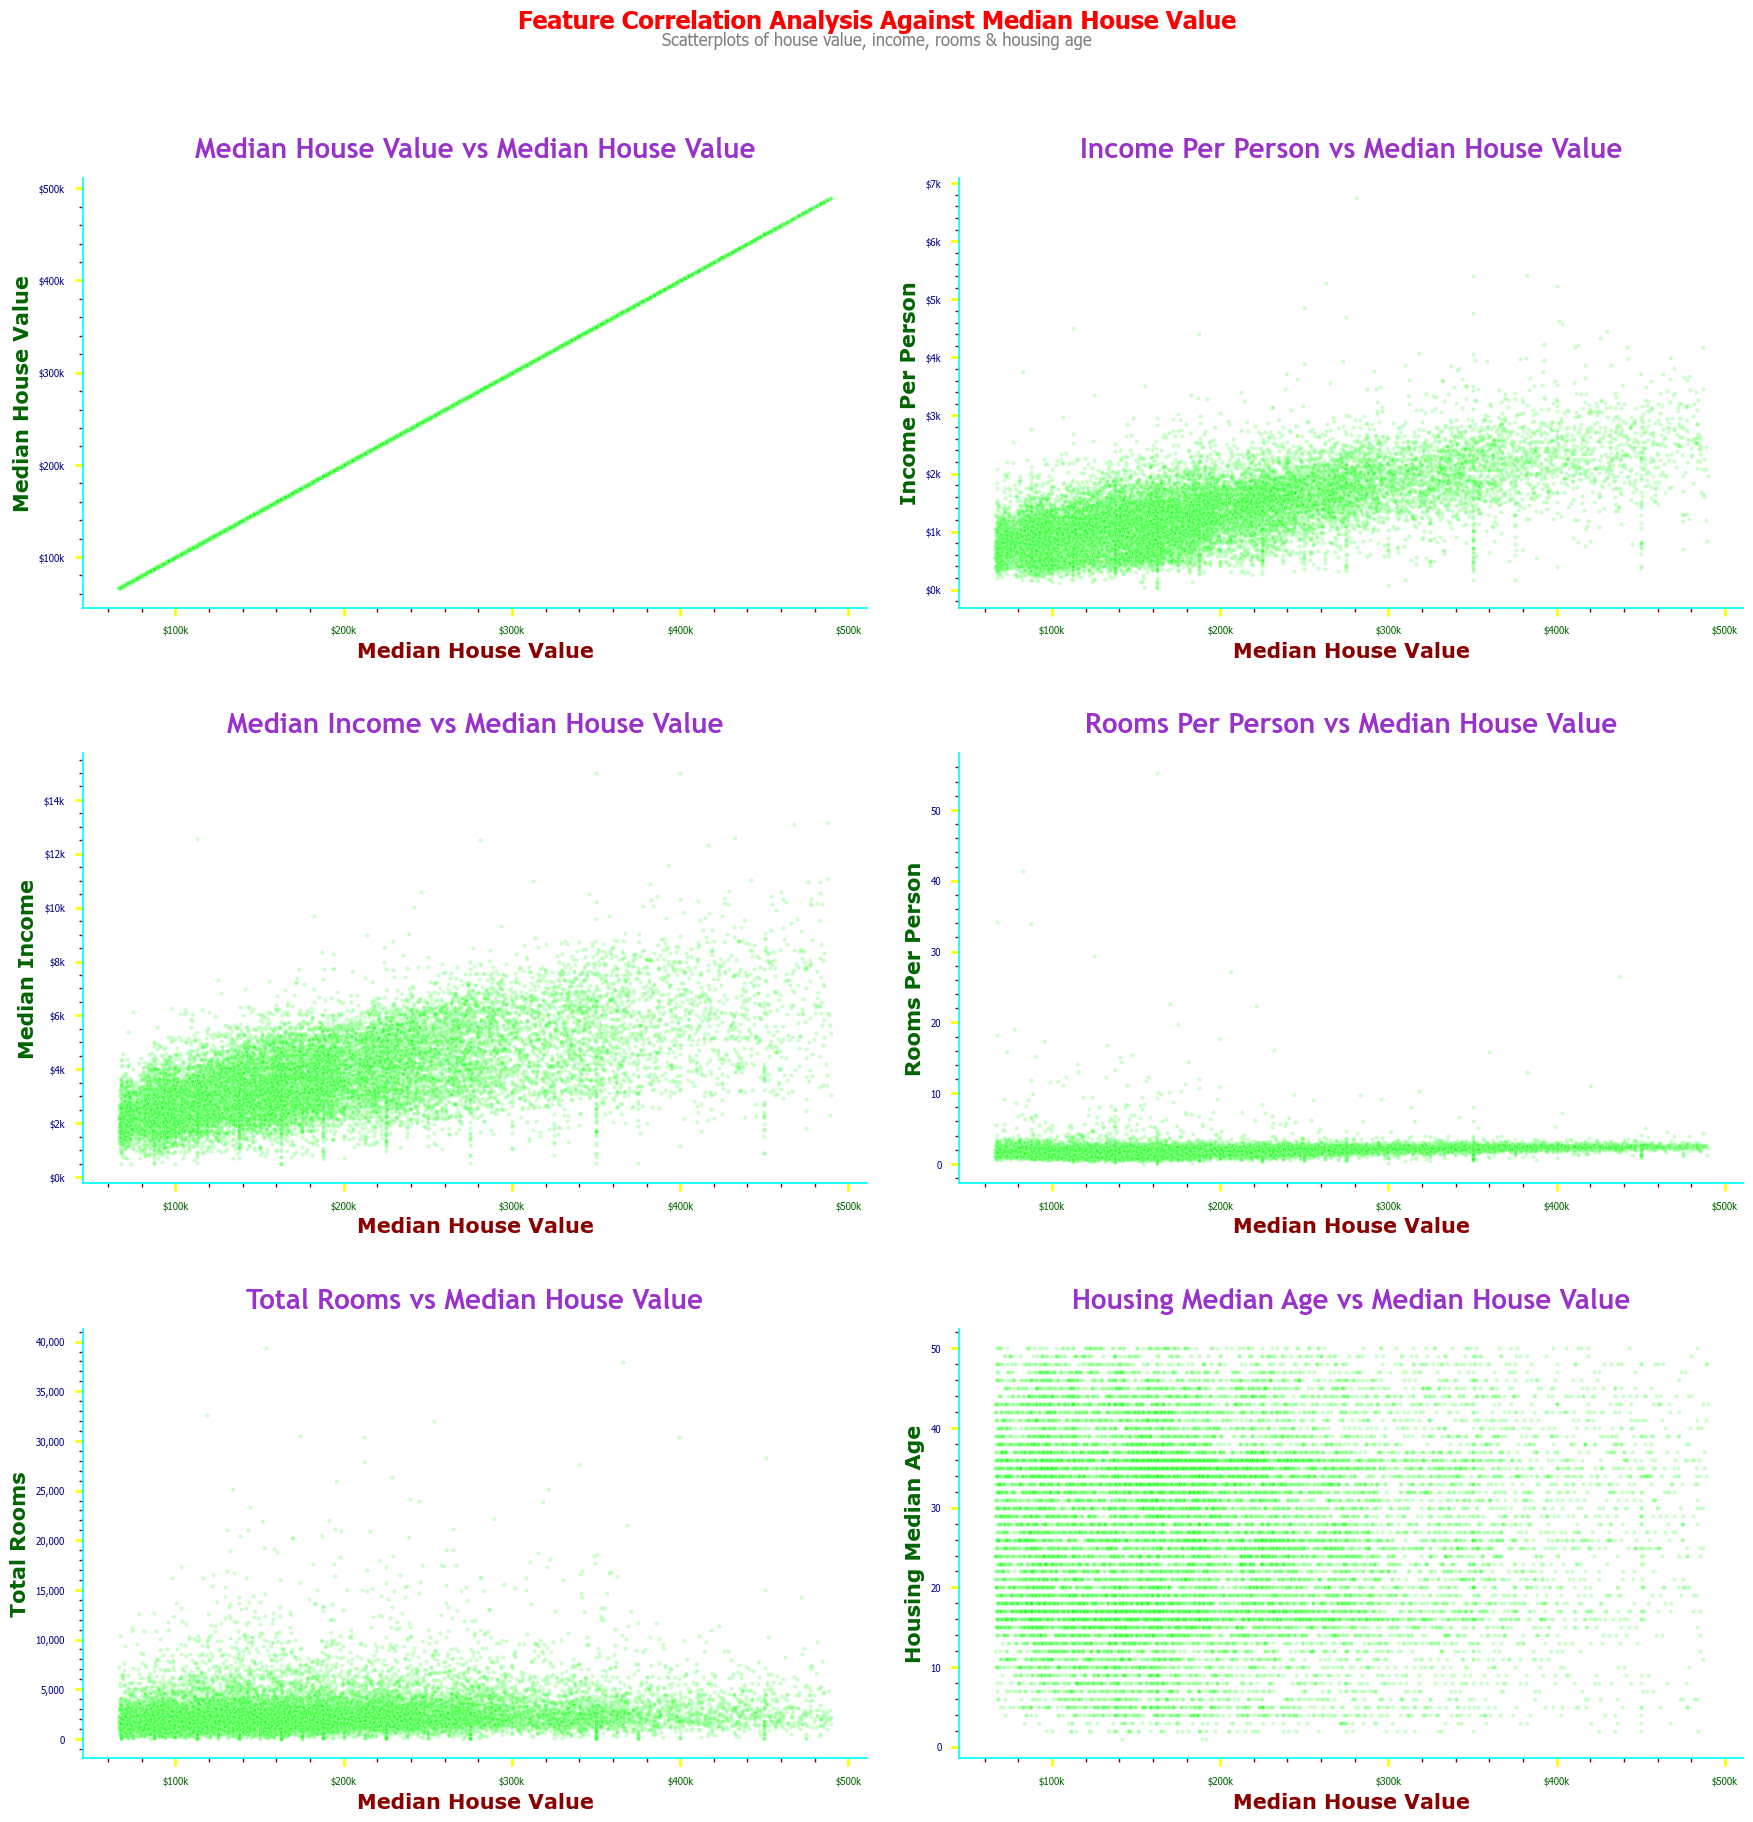

In [426]:
# ── Formatter Functions ───────────────────────────────────────────────────────
def dollar_k_formatter(x, pos):
    """e.g. \$100k, \$200k"""
    return f'${x/1000:,.0f}k'

def dollar_formatter(x, pos):
    """e.g. \$100, \$200"""
    return f'${x:,.0f}'

def count_k_formatter(x, pos):
    """e.g. 100k, 200k"""
    return f'{x/1000:,.0f}k'

def count_formatter(x, pos):
    """e.g. 100, 200"""
    return f'{x:,.0f}'

# ── Column Definitions ────────────────────────────────────────────────────────
columns        = ['median_house_value', 'income_per_person', 'median_income', 
                  'rooms_per_person', 'total_rooms', 'housing_median_age']
currency_cols  = ['median_income', 'median_house_value', 'income_per_person']
non_currency_cols = ['rooms_per_person', 'population', 'households', 
                     'total_rooms', 'total_bedrooms']

# # ── Boxplot Style ─────────────────────────────────────────────────────────────
# boxplot_style = {
#     'flierprops'   : {'marker': '*', 'markerfacecolor': 'gold', 'markersize': 6},
#     'capprops'     : {'color': 'salmon', 'linewidth': 2},
#     'whiskerprops' : {'color': 'grey', 'linewidth': 2},
#     'medianprops'  : {'color': 'magenta', 'linewidth': 1},
#     'boxprops'     : {'edgecolor': 'black', 'linewidth': 2},
# }
 
# # ── Annotation Style Properties ───────────────────────────────────────────────
# arrow_props = dict(
#     arrowstyle       = "->",
#     color            = 'red',
#     linewidth        = 1,
#     linestyle        = 'dotted',
#     alpha            = 1,
#     connectionstyle  = 'arc3,rad=0'
# )
# bbox_props = dict(
#     boxstyle   = "round4",
#     pad        = 0.1,
#     facecolor  = 'white',
#     alpha      = 0.45,
#     edgecolor  = 'gold'
# )
# nobs_bbox = dict(
#     boxstyle   = "round4",
#     pad        = 0.1,
#     facecolor  = 'white',
#     alpha      = 0.25,
#     edgecolor  = 'gold'
# )

# percentiles = [5, 25, 50, 75, 95]

# ── Grid Layout ───────────────────────────────────────────────────────────────
ncols = 2
nrows = 3   # 3 rows x 2 cols = 6 subplots (one per column)

fig, axes = plt.subplots(ncols=ncols, nrows=nrows, 
                         figsize=(18, nrows * 6), # Dynamically scales figure height
                         facecolor='white', dpi=100)

# ── Main Title & Subtitle ─────────────────────────────────────────────────────
fig.suptitle(
    "Feature Correlation Analysis Against Median House Value",
    fontsize=18, fontweight="bold", fontfamily="Tahoma", color="red",
    y=1.02,
)
fig.text(
    0.5, 1.00,
    "Scatterplots of house value, income, rooms & housing age",
    fontsize=12, fontstyle="italic", fontfamily="Tahoma",
    color="grey", ha="center",
)
# ─────────────────────────────────────────────────────────────────────────────

axes = axes.flatten()  # Flatten 2D array → 1D for easy iteration

# ── Main Loop ─────────────────────────────────────────────────────────────────
for idx, col in enumerate(columns):
    scatterplot = axes[idx] # Each column gets its own subplot

    # ── Box Plot ──────────────────────────────────────────────────────────────
    sns.scatterplot(data=housing, x=housing['median_house_value'], y=col,
                    marker='.', sizes=(1, 100), color='lime', ec='white', alpha=0.2, ax=scatterplot)

    # ── Titles & Labels ───────────────────────────────────────────────────────
    scatterplot.set_title(f'{col.replace("_", " ").title()} vs Median House Value', # .upper(), .lower(), 'title()
                   fontdict=title_font, pad=15)
    scatterplot.set_xlabel('Median House Value', fontdict=x_label_font)
    scatterplot.set_ylabel(col.replace('_', ' ').title(), fontdict=y_label_font) # .upper(), .lower(), .title()

    # ── Tick Parameters ───────────────────────────────────────────────────────
    scatterplot.minorticks_on()
    scatterplot.tick_params(axis='x', bottom=True, top=False, length=6, width=2, color='yellow', direction='out', labelsize=7, labelcolor='darkgreen', labelfontfamily='tahoma', labelrotation=None)
    scatterplot.tick_params(axis='y', left=True, right=False, length=6, width=2, color='yellow', direction='out', labelsize=7, labelcolor='darkblue', labelfontfamily='tahoma', labelrotation=None)
    scatterplot.tick_params(axis='x', which='minor', bottom=True, top=False, length=3, width=1, color='darkred')
    scatterplot.tick_params(axis='y', which='minor', left=True, right=False,  length=3, width=1, color='darkred')

    # ── X-Axis Formatter ──────────────────────────────────────────────────────
    # X is always 'median_house_value' → always use dollar_k_formatter
    scatterplot.xaxis.set_major_formatter(FuncFormatter(dollar_k_formatter))

    # ── Y-Axis Formatter ──────────────────────────────────────────────────────
    if col in currency_cols:
        scatterplot.yaxis.set_major_formatter(FuncFormatter(dollar_k_formatter))
    elif col in non_currency_cols:
        scatterplot.yaxis.set_major_formatter(FuncFormatter(count_formatter))

    # # ── Percentile Annotations ────────────────────────────────────────────────
    # categories = housing['ocean_proximity'].unique()

    # for i, category in enumerate(categories):
    #     subset = housing[housing['ocean_proximity'] == category][col]

    #     for percentile in percentiles:
    #         value = np.percentile(subset, percentile)

    #         scatterplot.annotate(
    #             f'{percentile}th pctl: {value:,.0f}',
    #             xy       = (i, value),
    #             xytext   = (i + 0.15, value + 0.2 * value),
    #             ha       = 'left',
    #             va       = 'center',
    #             family   = 'consolas',
    #             fontstyle= 'normal',
    #             fontsize = 7,
    #             fontweight = 'bold',
    #             color    = 'midnightblue',
    #             alpha    = 0.75,
    #             rotation = None,
    #             arrowprops = arrow_props,
    #             bbox       = bbox_props
    #         )

    # # ── Median & Observation Count Annotations ────────────────────────────────
    # medians = housing.groupby('ocean_proximity')[col].median()
    # nobs    = housing['ocean_proximity'].value_counts().sort_index()

    # for op in medians.index:
    #     pos        = list(medians.index).index(op)
    #     median_val = medians[op]
    #     nobs_val   = nobs[op]

    #     scatterplot.text(
    #         pos, median_val + 2,
    #         f"n: {nobs_val:,.0f}",
    #         ha         = 'center',
    #         va         = 'center',
    #         family     = 'consolas',
    #         fontstyle  = 'normal',
    #         fontsize   = 8,
    #         fontweight = 'bold',
    #         color      = 'gold',
    #         alpha      = 0.75,
    #         rotation   = None,
    #         bbox       = nobs_bbox
    #     )

# ── Hide Unused Subplots ──────────────────────────────────────────────────────
for j in range(len(columns), len(axes)):
    axes[j].set_visible(False)

# ── Adjust subplot params ──────────────────────────────────────────────────────
plt.tight_layout(pad=2, h_pad=3, w_pad=2) # Adds breathing room between subplots

# ── Save plot as png ──────────────────────────────────────────────────────
# # my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\Assets"
# my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\2_Descriptive_Data_Analysis\Assets"
# plt.savefig(my_path + '/Py_00_Scatterplot.png',transparent=None,dpi='figure',format=None,metadata=None,bbox_inches='tight',pad_inches=0.1,facecolor='auto',edgecolor='yellow',backend=None)

# ── Display plot as png ──────────────────────────────────────────────────────
plt.show()

#### `🤹‍♂️ Multivariate Analysis`.

`Examining three or more variables to understand complex, simultaneous relationships`.

**`📊 1. Heatmap` - `Correlation analysis of key metrics`**.

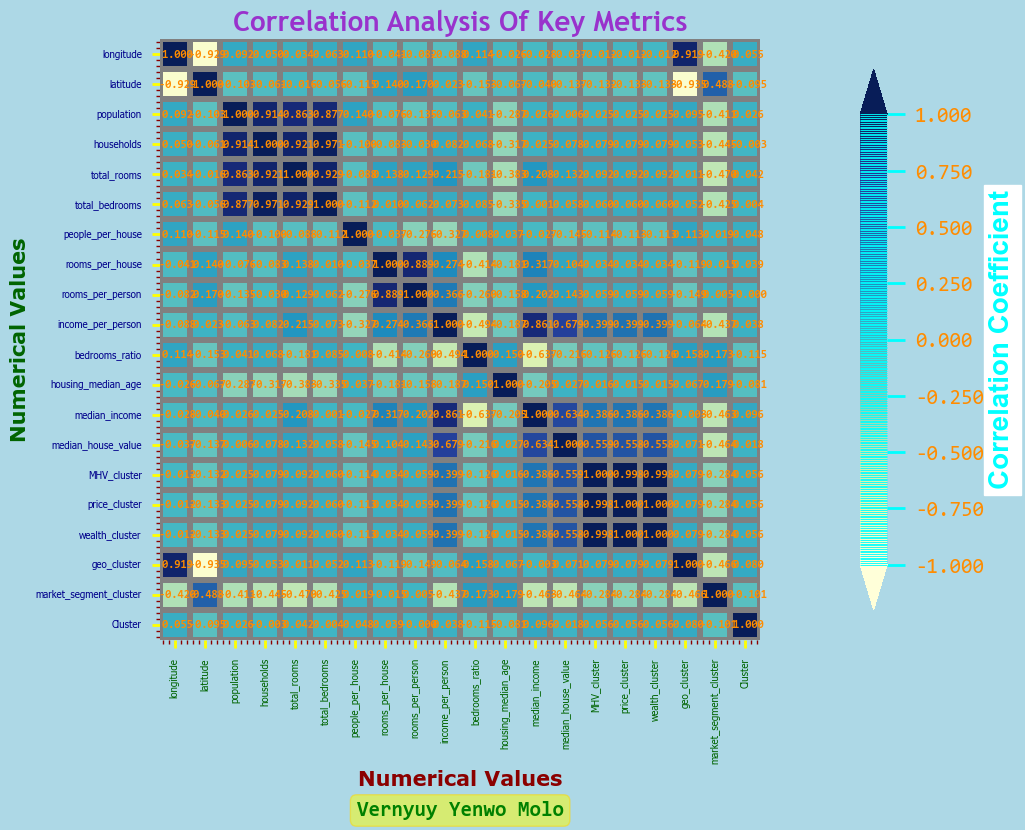

In [427]:
# Heatmap - Correlation analysis of key metrics.

# Correlation Matrix of Numerical Features
correlation_matrix = housing.select_dtypes(include='number').corr() # housing.corr(numeric_only=True)
correlation_matrix

# Figure properties
fig, ax = plt.subplots(ncols=1,nrows=1,figsize=(21,8),layout='constrained',facecolor='lightblue',dpi=100)

#==#

# Format colobar value
# fmt = lambda x,pos: ' £{:,.0f}'.format(x) # £
# fmt = lambda x,pos: ' ${:,.0f}'.format(x) # $
fmt = lambda x,pos: '{:,.3f}'.format(x) # Count

#==#

# Keyword arguements for plot appearance
annot_kws = dict(family='consolas',size=8,style='normal',weight='bold',color='darkorange',alpha=1,rotation=0,ha='center',va='center',) # backgroundcolor='pink')
cbar_kws = {"orientation":"vertical","shrink":0.9,'extend':'both','extendfrac':0.1,"drawedges":True,'label':'Correlation Coefficient','format':fmt,}
kwargs = {'linewidths':4,'linecolor':'gray','linestyle':'dashed','alpha':1,}#'rasterized':True,'edgecolor':'pink',"capstyle":'projecting','linewidth':2}

#==#

# Create a mask using numpy's triu function
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

#==#

# Create heatmap of the correlation matrix. ['copper_r',summer','Blues','Oranges,'pink_r','YlGn','YlOrBr','YlGnBu','hot_r','GnBu_r']
ax = sns.heatmap(correlation_matrix,vmin=-1,vmax=1,cmap='YlGnBu',center=None,robust=True,annot=True,fmt='.3f',annot_kws=annot_kws,
cbar=True,cbar_kws=cbar_kws,cbar_ax=None,square=True,xticklabels='auto',yticklabels='auto',mask=None,ax=ax,**kwargs) # fmt must be in string format. # centre=True (No gradient)

#==#

# ax.figure.set_size_inches(40, 20)
ax.figure.set_size_inches(21, 8)
# ax.figure.set_size_inches(15, 7.5)
# ax.figure.set_size_inches(10, 10)
# ax.figure.set_size_inches(8, 11)
ax.set_title('Correlation Analysis Of Key Metrics',loc='center',fontdict=title_font)
ax.set_xlabel('Numerical Values',loc='center',fontdict=x_label_font)
ax.set_ylabel('Numerical Values',loc='center',fontdict=y_label_font)
ax.tick_params(axis='x', bottom=True, top=False, length=6, width=2, color='yellow', direction='out', labelsize=7, labelcolor='darkgreen', labelfontfamily='tahoma', labelrotation=90)
ax.tick_params(axis='y', left=True, right=False, length=6, width=2, color='yellow', direction='out', labelsize=7, labelcolor='darkblue', labelfontfamily='tahoma', labelrotation=None)
ax.tick_params(axis='x', which='minor', bottom=True, top=False, length=3, width=1, color='darkred')
ax.tick_params(axis='y', which='minor', left=True, right=False,  length=3, width=1, color='darkred')
ax.minorticks_on()

#==#

# Change colobar font properties

# Use matplotlib.colorbar.Colorbar object
cbar = ax.collections[0].colorbar
# here to set the labelsize by 15
cbar.ax.tick_params(axis='y',length=13,width=2,color='cyan',direction='out',labelsize=15,labelcolor='darkorange',labelfontfamily='consolas',labelrotation=None)

# Change colobar label properties
ax.figure.axes[-1].yaxis.label.set_fontname('sans serif')
ax.figure.axes[-1].yaxis.label.set_fontsize(20)
ax.figure.axes[-1].yaxis.label.set_fontstyle('normal')
ax.figure.axes[-1].yaxis.label.set_fontweight('bold')
ax.figure.axes[-1].yaxis.label.set_color('cyan')
ax.figure.axes[-1].yaxis.label.set_backgroundcolor('white')

#==#

# Manually format the annotations with £/$/Count
for text in ax.texts:
    # text.set_text(f"£ {float(text.get_text()):,.0f}") # £
    # text.set_text(f" ${float(text.get_text()):,.0f}") # $
    text.set_text(f" {float(text.get_text()):,.3f}") # Count
    # text.set_fontsize(10)
    # text.set_fontweight('bold')

#==#

# Add signature to figure in bbox round format
ax.text(0.50, -0.30,'Vernyuy Yenwo Molo',ha='center',va='bottom',transform=ax.transAxes,  # Use axes coords (0 to 1)
        family='consolas',fontstyle='normal',
        fontsize=15,fontweight='bold',color='green',rotation=0,
        bbox=dict(boxstyle='round',facecolor='yellow',alpha=0.5,edgecolor='gold'))

#==#

# # my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\Assets"
# my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\3_Diagnostic_Sales_Analysis\Assets"
# plt.savefig(my_path + '/Py_0X_Strategic_Insights_Correlation_Analysis_Of_Key_Metrics_Heatmap.png',transparent=None,dpi='figure',format=None,metadata=None,bbox_inches='tight',pad_inches=0.1,facecolor='auto',edgecolor='yellow',backend=None)

#==#

plt.show()

**`📊 2. Scatter Matrix`**.

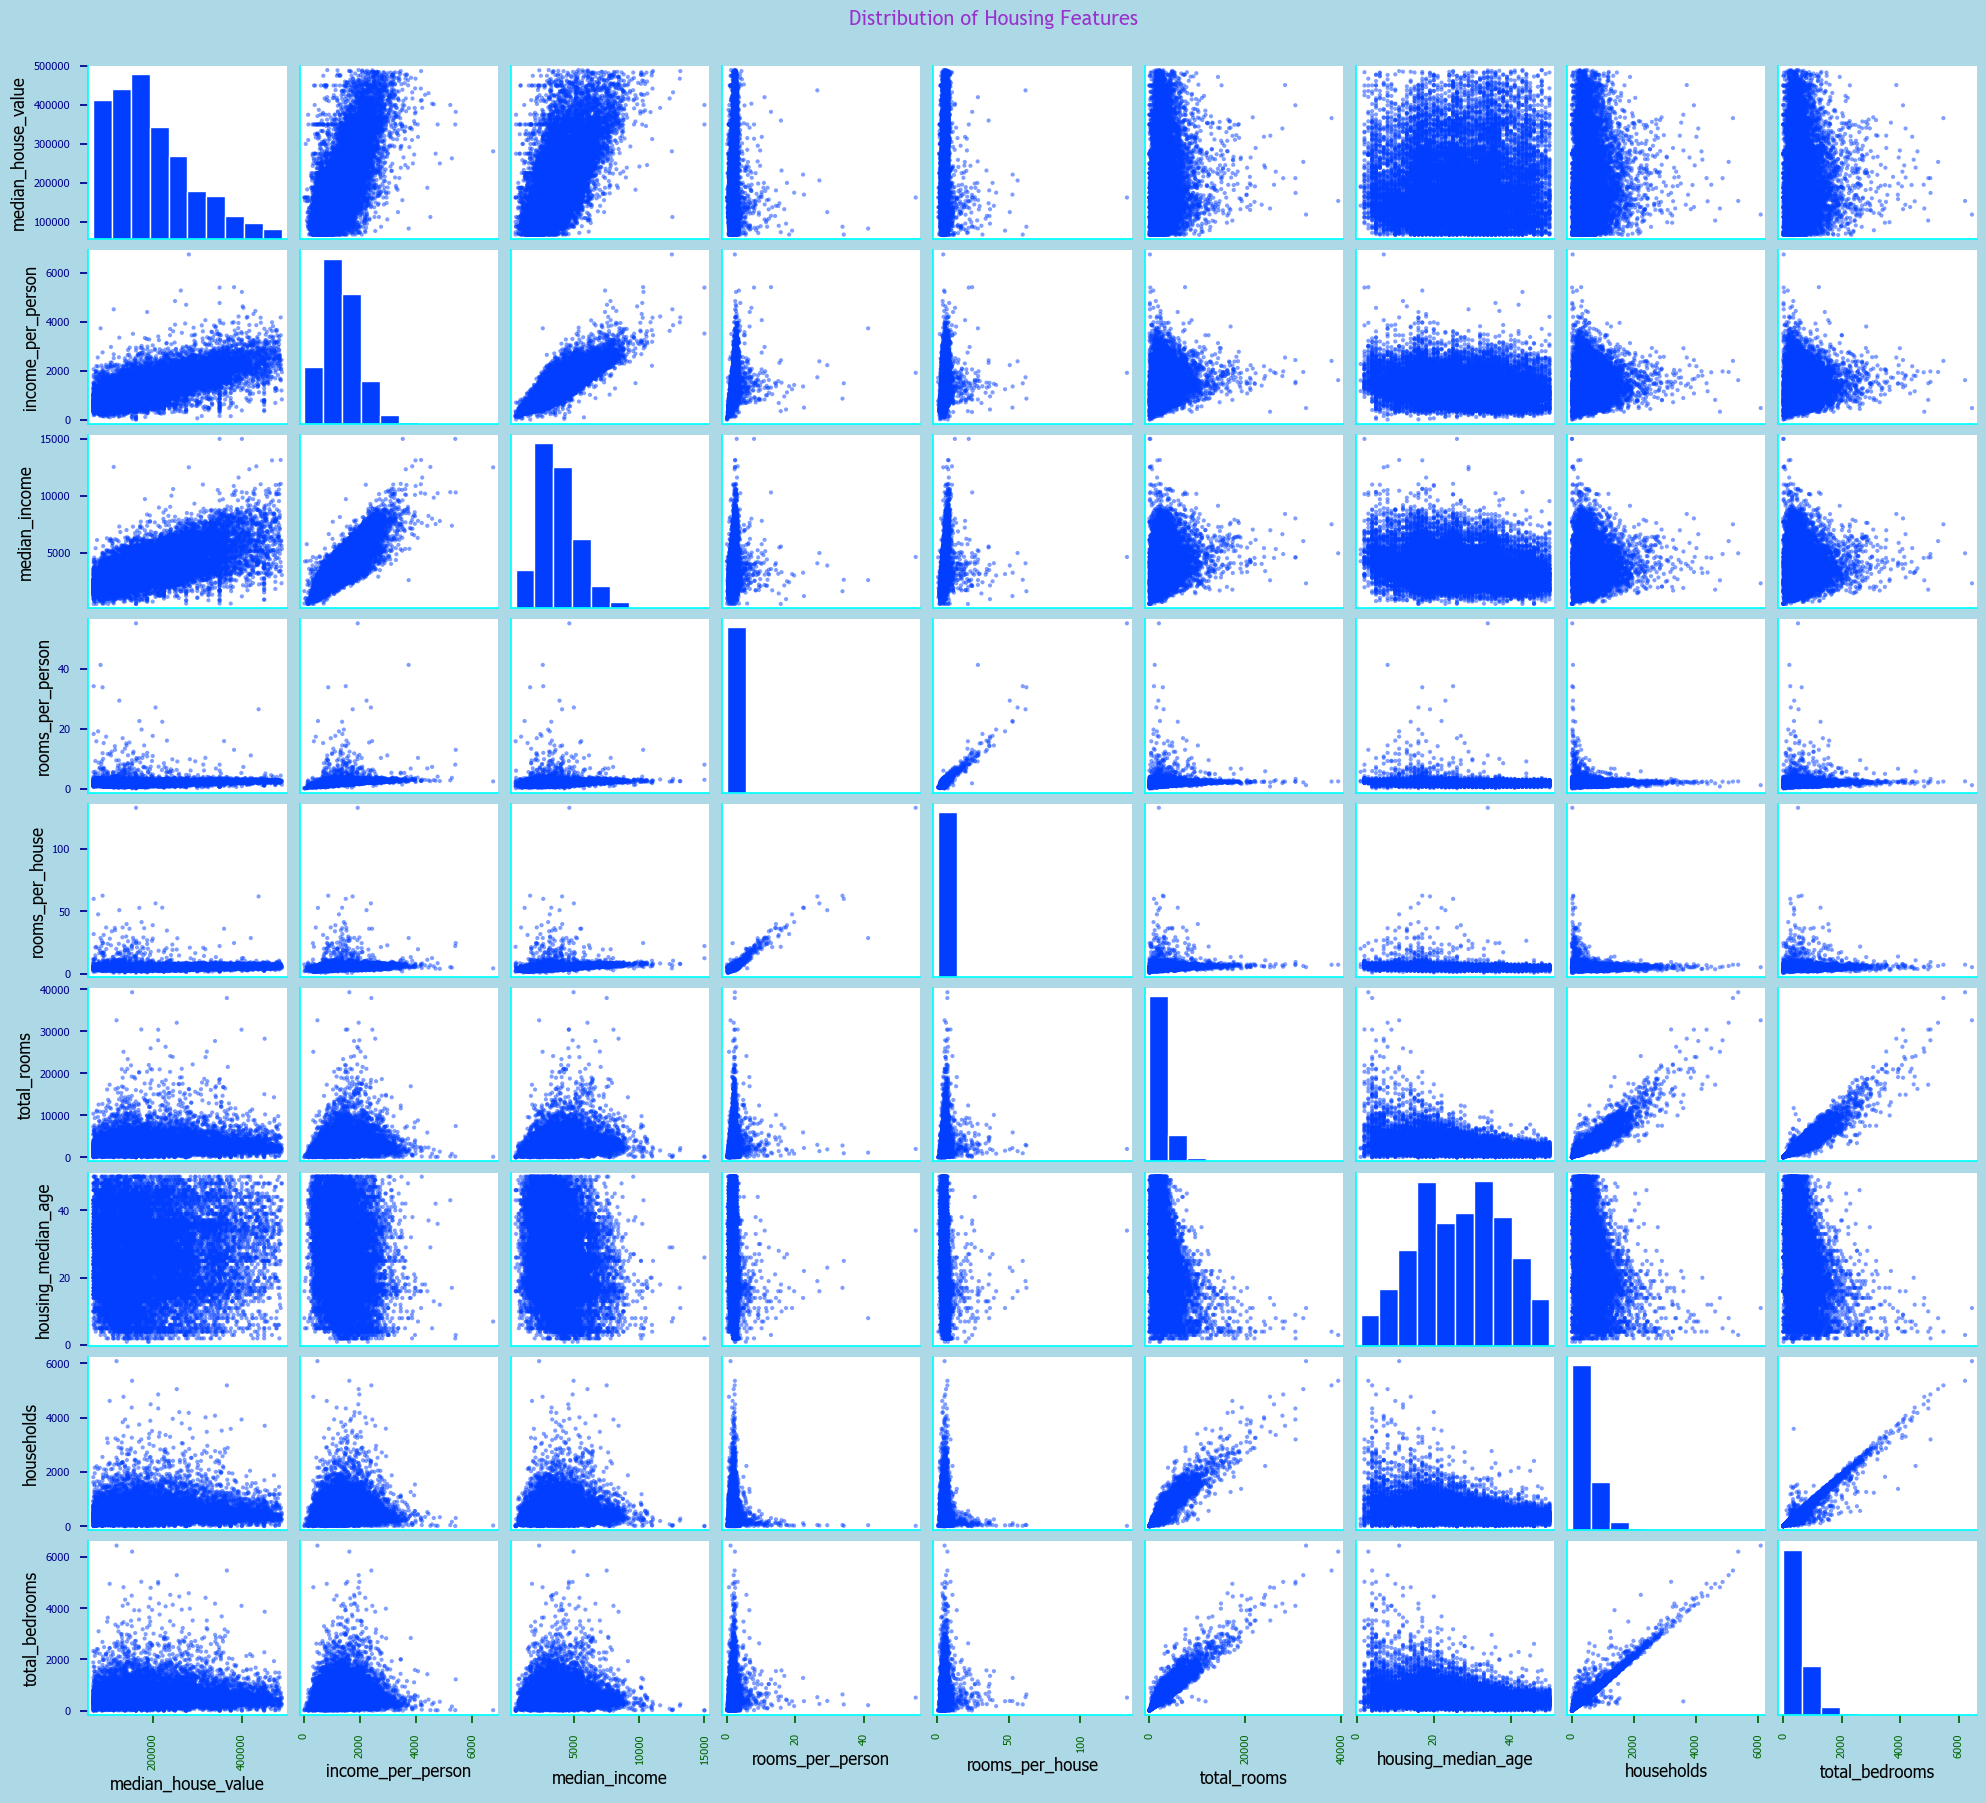

In [428]:
from pandas.plotting import scatter_matrix

attributes = ['median_house_value', 'income_per_person', 'median_income', 'rooms_per_person', 'rooms_per_house', 'total_rooms', 'housing_median_age', 'households', 'total_bedrooms']

# Plot histograms and capture the returned axes
scatter_matrix(housing[attributes], figsize=(20, 18))

# # Plot histograms and capture the returned axes
# axes = scatter_matrix(housing[attributes], figsize=(20, 18))

# # Define $k formatter function
# def dollar_k_formatter(x, pos):
#     return f'${x/1000:,.2f}k'    # e.g. \$100k, \$200k

# # Define $k formatter function
# def count_k_formatter(x, pos):
#     return f'{x/1000:,.2f}k'    # e.g. \100k, \200k

# # Define specific columns and their formatters
# currency_cols = ['median_income', 'median_house_value', 'income_per_person']   # $ format
# # percent_cols  = []                                         # % format
# non_currency_cols  = ['population', 'households', 'total_rooms', 'total_bedrooms'] # , format

# # Add ylabel to each subplot
# for axsp in axes.flatten():
#     col_name = axsp.get_title()  # 👈 Get column name from subplot title
#     if axsp.has_data():
#         # ax.set_ylabel('Frequency', fontdict=y_label_font)
#         axsp.yaxis.set_major_formatter(StrMethodFormatter('{x:,}')) #
#         axsp.minorticks_on()
#         axsp.tick_params(axis='x', labelsize=7.5, labelrotation=None)
#         axsp.tick_params(axis='y', labelrotation=None)
#         axsp.tick_params(axis='x', which='minor', bottom=True, length=3, width=1, color='darkred')
#         axsp.tick_params(axis='y', which='minor', bottom=True, length=3, width=1, color='darkred')
#         # axsp.autoscale()
#         # asp.axis('equal')
#         # axsp.set_xlim(left=0)
#         # axsp.set_ylim(bottom=0)
#         # axsp.set_xscale('log')
#         # axsp.set_yscale('log')
#         # axsp.set_yscale('linear')  # Try removing log scale
    
#     # Apply specific x-axis formatters based on column name
#     if col_name in currency_cols:
#             # ax.xaxis.set_major_formatter(StrMethodFormatter('$ {x:,}'))   # $ format
#             axsp.xaxis.set_major_formatter(FuncFormatter(dollar_k_formatter))  # $k format
#     elif col_name in non_currency_cols:
#             # ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,}'))     # format
#             axsp.xaxis.set_major_formatter(FuncFormatter(count_k_formatter))  # k format

plt.suptitle("Distribution of Housing Features", fontdict=title_font, x=0.5, y=1.00) # Overview of Housing Dataset Variables, Statistical Distribution of Housing Attributes
plt.tight_layout(pad=1, h_pad=0.3, w_pad=0.3, rect=None)
plt.show()

### `💾 Save Modified DataFrame To Python Docs Folder`.

In [ ]:
# 📁 Define base CSV directory
csv_files_dir = os.path.expanduser("~/Python-Documents/os/CSV Files")

# 🧱 Create directory if it doesn't exist
os.makedirs(csv_files_dir, exist_ok=True)

# 📄 Define full CSV file path
csv_path = os.path.join(csv_files_dir, "California_Housing_Market_Data_Analysis_modified_2.csv")

# 💾 Save modified dataset to CSV file
housing.to_csv(csv_path, index=False)

print("Modified CSV file saved to:", csv_path)

### `🤖📌 Machine Learning Project Objectives`.

**`What are the objectives of the machine learning project?`**:
- --
  - **1 `📌 To predict median house values based on features like income, room ratios, housing age and location`**.

  - **2 `📌 To identify and analyse the distribution of housing values across key California locations`**.
     
  - **3 `📌 To segment California housing markets into meaningful clusters using KMeans clustering`**.
     
  - **4 `📌 To determine the best housing investment strategy (PB&H, F&F or AFD) per geographic location`**.
  
  - **4 `📌 To visualise geographic housing patterns across California using geospatial mapping`**.
     
  - **5 `📌 To explore the relationship between ocean proximity, median income and median house value`**.
     
  - **6 `📌 To provide data-driven prescriptive recommendations for housing strategy selection by location`**.

### `🧑🏻‍🏫🎓 Supervised Learning — Median House Price Prediction: A Comparison Of Linear Regression, Gradient Boosting And XGBoost`.

##### `📜 Machine Learning Terminology`.

**`📝 Model Evaluation Metrics — Key Definitions & Interpretations`**:
- --
  - **📌`RMSE`** — Average error in dollars, penalises large errors.
    - https://dev.to/mondal_sabbha/understanding-mae-mse-and-rmse-key-metrics-in-machine-learning-4la2
    - *`RMSE is the square root of MSE (the average of the squared differences between the predicted and actual values)`*.
      - It brings the metric back to the original scale of the data, making it easier to interpret than MSE.
      - It is on the same scale as the original data, making it more interpretable. 
    - *`Like MSE, RMSE also penalises large errors, but since it’s on the original scale, it can provide a more intuitive measure of the error magnitude`*
      - It is preferred when you want a metric that penalises large errors but still needs the results to be in the same unit as the original data.
      - It is widely used in contexts where the distribution of error magnitudes matters and where being on the same scale as the data is crucial.
    - *`It combines the benefits of MSE and MAE, offering an error metric that penalises large errors and remains interpretable`*.
- --
  - **`📌MAE `** — Average absolute error in dollars, easier to interpret.
    - *`MAE is the average absolute difference between predicted and actual values`*. 
    - *`It provides a clear, straightforward interpretation of the average error`*. 
      - If MAE is 5, on average, the model’s predictions are 5 units off from the actual values. 
    - *`It is less sensitive to outliers compared to MSE and RMSE because it doesn’t square the error terms`*.
      - It is preferred when you want a direct understanding of the average error without exaggerating the impact of large errors. 
      - It is particularly useful when the dataset has outliers or when the cost of errors is linear.
    - *`It is more robust to outliers and gives an average error in the same unit as the data, making it easy to interpret`*.
- --
  - **`📌R²`** — How much variance the model explains.
  
    - **`1.0`** = *`perfect✅`*, **`0.0`** = *`terrible❌`*.
    - *`Anything above 0.80 is considered good for this dataset✅`*.

##### `👁️⃤  Correlation Matix` - `Correlation Snalysis Of Key Metrics`.

In [429]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False) # Sorted from highest to lowest.
# corr_matrix # Unsorted.

median_house_value        1.000000
income_per_person         0.679062
median_income             0.634155
MHV_cluster               0.558860
price_cluster             0.558132
wealth_cluster            0.558132
rooms_per_person          0.142806
total_rooms               0.131865
rooms_per_house           0.104243
households                0.078362
geo_cluster               0.071319
total_bedrooms            0.058401
housing_median_age        0.027203
Cluster                   0.018148
population                0.005782
longitude                -0.037052
latitude                 -0.137370
people_per_house         -0.145168
bedrooms_ratio           -0.216261
market_segment_cluster   -0.463555
Name: median_house_value, dtype: float64

**`📊 Key Insights`**:
- --
- **`Strong Positive Correlations`**
  - **income_per_person `(0.6790)` is by far the `strongest predictor` of house value followed by **median_income `(0.6341)`** — `higher income areas` tend to have `significantly more expensive homes`. This is your most important feature**.
- --
- **`Weak Positive Correlations`**
  - **rooms_per_person `(0.1428)` - `More rooms per person ` suggests `less overcrowding`, marginally linked to `higher value`**.
  - **total_rooms `(0.1318)` — `More rooms` suggests `marginally higher value`**.
  - **rooms_per_house `(0.1042)`, households `(0.0783)`, geo_cluster `(0.0713)`, total_bedrooms `(0.0584)` — `Negligible positive relationships`**.
  - **housing_median_age `(0.0272)`, population `(0.0057)`— `Negligible positive relationships`**.
- --
- **`Negative Correlations`**
  - **longitude `(-0.0370)` - `Moving east` correlates with `slightly lower prices`**.
  - **latitude `(-0.1373)` — `Moving north` correlates with `lower prices` (likely reflects California geography)**.
  - **people_per_house `(-0.1451)` — `More people per house` suggests `overcrowding`, weakly linked to `lower values`**.
  - **bedrooms_ratio `(-0.2162)` — `Higher bedroom ratio` correlates with `lower value`**.
  - **market_segment_cluster `(-0.4635)` — X**.
  - **longitude, population, bedroom_ratio, market_segment_cluster — `Very weak negative relationships`**.
  - **(`more bedrooms relative to rooms` = `smaller, cheaper properties`)**.
---
- **`🎯 Conclusion`**
  - **income_per_person `dominates` — `Our anchor feature`**.
  - **population, people_per_house and longitude have `correlations close to 0`, meaning they have `negligible negative relationships` with house prices**.
  - **people_per_house `(-0.1451)` is the `3rd strongest negative predictor` in the dataset**.
  - **bedrooms_ratio `(-0.2162)` is the `2nd strongest negative predictor` in the dataset**. 
  - **market_segment_cluster `(-0.4635)` is the `1st strongest negative predictor` in the dataset**. 
  - **Geographic features `(latitude/longitude)` show `weak linear correlations` individually. However, `combined together` they represent `location` which is a `powerful predictor` of house prices**.

##### `✔️ Step 1 - Select Features`.

In [430]:
# Create X - strong/useful features to keep
# Features: use lat/lon for clustering + other features for prediction
X = housing[[
    'income_per_person',    # Engineered — strongest correlator (0.75) — affordability metric
    'median_income',        # Strong predictor — highest individual correlation (0.69)
    # 'MHV_cluster',          # ❌ Leakage — built using median_house_value (target variable)
    # 'wealth_cluster',       # ❌ Leakage — built using median_house_value (target variable)
    # 'price_cluster',        # ❌ Leakage — built using median_house_value (target variable)
    'rooms_per_person',     # Engineered — captures overcrowding in cheaper areas
    'rooms_per_house',      # Engineered — captures property size per household
    'geo_cluster',          # Derived from lat/lon clustering
    'housing_median_age',   # Age of property — impacts valuation
    'latitude',             # Geographic pattern — north/south price variation
    'longitude',            # Geographic pattern — east/west price variation
    'people_per_house',     # Engineered — captures
    'bedrooms_ratio',       # Engineered — bedroom proportion signals property type
    # 'total_rooms',          # Already "encoded" inside bedrooms_ratio
    # 'total_bedrooms',       # Already "encoded" inside bedrooms_ratio
    # 'housing_median_age',   # Drop near-zero correlators
    # 'population',           # Already "encoded" inside people_per_house / # Drop near-zero correlators.
]]

# Dropping
# 'total_bedrooms', 'households' & population — multicollinearity risk with other features

# Create Y with our Target variable
y = housing['median_house_value']

##### `🧼 Step 2 - Data Preprocessing (Handle Missing Values & Scale)`.

**`📝 Preprocessing Pipeline — Key Components`**:
- --
- **`Pipeline`** — **`Chains steps together so they run in order automatically`**.
- **`SimpleImputer`** — **`Fills any missing values with the median of that column`**. **`We use median over mean as it's more robust to outliers`**.
- **`StandardScaler`** — **`Scales all features to the same range`**. **`Prevents features with large values (e.g. total_rooms) dominating the model`**.
- **`fit_transform on X_train`** — **`Learns the median/scale FROM training data then applies it`**.

In [431]:
# from sklearn.pipeline import Pipeline # Chains steps together so they run in order automatically.
# from sklearn.preprocessing import StandardScaler # Scales all features to the same range.
# from sklearn.impute import SimpleImputer # Fills any missing values with the median of that column.

# # Handle missing values & scale
# preprocessor = Pipeline([
#     ('imputer', SimpleImputer(strategy='median')),
#     ('scaler', StandardScaler())
# ])

# X_train = preprocessor.fit_transform(X_train) # Learns the median/scale FROM training data then applies it.
# X_test = preprocessor.transform(X_test)
# #  Scaling is especially important for Linear Regression and SVMs!!

**`Verify After Loading`**.

In [432]:
# Verify after loading.
print(housing.shape)       # should show (rows, cols)

(17483, 32)


**`Display First Two Rows Of Dataframe`**

In [433]:
# Display first two rows of dataframe.
print(housing.head(2))

   longitude  latitude  population  households  total_rooms  total_bedrooms  people_per_house  rooms_per_house  rooms_per_person  income_per_person  bedrooms_ratio  housing_median_age  median_income  median_house_value ocean_proximity  MHV_cluster MHV_cluster_name  price_cluster  price_cluster_name  wealth_cluster wealth_cluster_name  geo_cluster     geo_cluster_name  market_segment_cluster market_segment_cluster_name Risk Return       Best Strategy     Annotated Summary  Cluster Best Strategy Short   location_name
0    -122.23     37.88       322.0       126.0        880.0           129.0          2.555556         6.984127          2.732919        3257.686957        0.146591                41.0         8325.2            452600.0        NEAR BAY            1        🏆 Premium              1  Affluent Districts               1        Luxury Zones            0  Northern California                       1          🏙️ Urban Mid-Range  Low   High  Premium Buy & Hold  💎 Premium Buy & Hold    

##### `✂️ Step 3 - Split Data`.

In [434]:
# Splitting dataset into Training set 60%, Validation Set 20%, and Test Set 20%
from sklearn.model_selection import train_test_split

# ── FIRST SPLIT ──────────────────────────────────────────────────────────────
# X = feature matrix, y = target labels (your full dataset)
# test_size=0.4 → reserves 40% of the data for later (validation + test), the remaining 60% becomes the TRAINING set
# random_state=42 → seeds the random number generator for reproducibility
# (using 42 is a common convention, any integer works
X_train, X_valtest, y_train, y_valtest = train_test_split(X, y, test_size=0.4, random_state=42)


# ── SECOND SPLIT ─────────────────────────────────────────────────────────────
# Now we split the 40% remainder (X_valtest, y_valtest) into two equal halves
# test_size=0.5 → splits the 40% pool into:
# → 50% of 40% = 20% VALIDATION set
# → 50% of 40% = 20% TEST set
# random_state=14 → different seed so this split is independently randomised
# (TO CONFIRM: x_valtest and y_valtest contains 20% validation and 20% test data)
X_val, X_test, y_val, y_test = train_test_split(X_valtest, y_valtest, test_size=0.5, random_state=14)


# ── VERIFICATION ─────────────────────────────────────────────────────────────
# Prints the number of samples in each split to confirm the sizes are correct
# Expected output (e.g. for 1000 samples): (600, 600, 200, 200, 200, 200)
#  X_train / y_train → 60% used to FIT / TRAIN the model
#  X_val   / y_val   → 20% used to TUNE hyperparameters & catch overfitting
#  X_test  / y_test  → 20% used ONCE at the end to evaluate final performance
len(X_train), len(y_train), len(X_val), len(y_val), len(X_test), len(y_test)

(10489, 10489, 3497, 3497, 3497, 3497)

In [435]:
# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# print(f"Training set: {X_train.shape}")
# print(f"Test set:     {X_test.shape}")

##### `👾 Step 4 - Start With Baseline Models`.

**`📝 Preprocessing Pipeline — Key Components`**:
- --
- **`Why 3 models?`** — **`We test simple to complex to find the best starting point`**.
    - **`LinearRegression`** — **`Simple, fast, good baseline`**.
    - **`DecisionTree`** — **`Captures non-linear patterns but can overfit`**.
    - **`RandomForest`** — **`Multiple trees combined, usually performs best of the three`**.
- --
- **`cross_val_score`** — **`Splits training data into 5 folds and tests each. More reliable than a single train/test evaluation`**.
- **`cv=5`** — **`5 fold cross validation`**.
- **`RMSE`** — **`Average error in house value (dollars)`**.
- **`Lower is better`**
- **`neg_root_mean_squared_error`** — **`Sklearn returns negative RMSE, we negate it with`**
- **`scores.mean()`** **`to get positive value`**.

In [436]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor()
}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, scoring='neg_root_mean_squared_error',cv=5)
    print(f"{name}: RMSE = {-scores.mean():,.2f}")

Linear Regression: RMSE = 57,161.73
Decision Tree: RMSE = 62,452.14
Random Forest: RMSE = 44,764.63


`Display score statistics`.

In [437]:
pd.Series(-scores).describe()

count        5.000000
mean     44764.625126
std       1922.745936
min      42289.627174
25%      43649.731740
50%      44733.114886
75%      45919.224542
max      47231.427287
dtype: float64

##### `📏 Step 5 - Evaluate Models`.

**`👾 Linear Regression Model - Training Evaluation`**

In [438]:
# Linear Regression Model - Training Evaluation

from sklearn.linear_model import LinearRegression

# Create an empty Linear regression model
Linreg = LinearRegression()

# Use .fit(x,y) to prepare the data for prediction
Linreg.fit(X_train, y_train)

# To retrieve the intercept:
print('Intercept (train):', Linreg.intercept_)
# To retrieve the slope:
print('Slopes (train):', Linreg.coef_)

from sklearn.metrics import r2_score
# 'y_pred_Linreg_train' is predicted y using the X_train data
y_pred_Linreg_train = Linreg.predict(X_train)

print('\n=== Training Evaluation Results ===')
# r2_score_Linreg_train is R-sq in lin reg involving training dataset
r2_score_Linreg_train = r2_score(y_train, y_pred_Linreg_train)

print('\n=== R² Score ===')
print(f'-Linreg_train_R²_score: {r2_score_Linreg_train:,.4f}.')
# print('-Linreg_train_R²_score:', r2_score_Linreg_train)
print('=== Insights ===')
print(f'-The model explains {r2_score_Linreg_train:,.1%} variance in house prices')

if r2_score_Linreg_train < 0.1:
    print(f'-There is no relationship between actual values (y_train) and predicted values (y_pred_Linreg_train)\n')
elif r2_score_Linreg_train > 0.1 and r2_score_Linreg_train < 0.3:
    print(f'-There is a weak relationship between actual values (y_train) and predicted values (y_pred_Linreg_train)\n')
elif r2_score_Linreg_train> 0.3 and r2_score_Linreg_train < 0.5:
    print(f'-There is a moderate-to-weak relationship between actual values (y_train) and predicted values (y_pred_Linreg_train)\n')
elif r2_score_Linreg_train > 0.5 and r2_score_Linreg_train < 0.7:
    print(f'-There is a moderate-to-strong relationship between actual values (y_train) and predicted values (y_pred_Linreg_train)\n')
elif r2_score_Linreg_train > 0.7:
    print('-There is a strong linear relationship between actual values (y_train) and predicted values (y_pred_Linreg_train)\n')

print('=== MAE & RMSE ===')

from sklearn.metrics import mean_squared_error
# Predicting MAE (average absolute difference between predicted and actual values) -- Training set results

# print('-Linreg_train_MAE:', mean_absolute_error(y_train, y_pred_Linreg_train))
print(f'-Linreg_train_MAE: {mean_absolute_error(y_train, y_pred_Linreg_train):,.2f}')
mae_Linreg_train = mean_absolute_error(y_train, y_pred_Linreg_train)
# Predicting RMSE (the average of the squared differences between the predicted and actual values) -- Training set results
rmse_Linreg_train = (np.sqrt(mean_squared_error(y_train, y_pred_Linreg_train)))
# print('-Linreg_train_RMSE:', rmse_Linreg_train)
print(f'-Linreg_train_RMSE: {rmse_Linreg_train:,.2f}')

print('=== Insights ===')
print(f'-On average, predictions are off by {mae_Linreg_train:,.2f}(MAE)')
print(f'-On average, predictions are off by {rmse_Linreg_train:,.2f}(RMSE)')

# Check for negatives
negative_preds = (y_pred_Linreg_train < 0).sum()
print(f'Negative Predictions: {negative_preds}')  # Likely 0

Intercept (train): -3351687.6869972833
Slopes (train): [ 6.20343363e+01  1.98619906e+01  8.24977060e+03 -1.22312987e+03
  1.83690645e+04  6.41479163e+02 -3.33960262e+04 -3.74784150e+04
  1.06186718e+03  2.64766692e+05]

=== Training Evaluation Results ===

=== R² Score ===
-Linreg_train_R²_score: 0.6104.
=== Insights ===
-The model explains 61.0% variance in house prices
-There is a moderate-to-strong relationship between actual values (y_train) and predicted values (y_pred_Linreg_train)

=== MAE & RMSE ===
-Linreg_train_MAE: 42,077.05
-Linreg_train_RMSE: 57,040.01
=== Insights ===
-On average, predictions are off by 42,077.05(MAE)
-On average, predictions are off by 57,040.01(RMSE)
Negative Predictions: 3


**`👾 Linear Regression Model - Validation Evaluation`**.

In [439]:
# Linear Regression Model - Validation Evaluation
# The validation set acts as a "second unseen dataset" to further confirm the model generalises well.
# This is a final sanity check before before deployment of the trained model into a real-world application e.g.,
# using it to predict actual house prices on brand new, unseen data outside of your dataset entirely.

# Predicting R2 Score using validation set but intercept(train) and slopes(train) from training results
y_pred_Linreg_val = Linreg.intercept_ + np.dot(X_val, Linreg.coef_.T)

print('=== Final sanity check before deployment ===')
print('\n=== Validation Evaluation Results ===')

# r2_score_Linreg_val is R-sq in Lin reg involving validation dataset
r2_score_Linreg_val = r2_score(y_val, y_pred_Linreg_val)

print('\n=== R² Score ===')
print(f'-Linreg_val_R²_score: {r2_score_Linreg_val:,.4f}')
# print('-Linreg_val_R²_score:', r2_score_Linreg_test)
print('=== Insights ===')
print(f'-The model explains {r2_score_Linreg_val:,.1%} variance in house prices')

if r2_score_Linreg_val < 0.1:
    print(f'-There is a no relationship between actual y (y_val) and predicted y (y_pred_Linreg_val)\n')
elif r2_score_Linreg_val > 0.1 and r2_score_Linreg_val < 0.3:
    print(f'-There is a weak relationship between actual y (y_val) and predicted y (y_pred_Linreg_val)\n')
elif r2_score_Linreg_val > 0.3 and r2_score_Linreg_val < 0.5:
    print(f'-There is a moderate-to-weak relationship between actual y (y_val) and predicted y (y_pred_Linreg_val)\n')
elif r2_score_Linreg_val > 0.5 and r2_score_Linreg_val < 0.7:
    print(f'-There is a moderate-to-strong relationship between actual y (y_val) and predicted y (y_pred_Linreg_val)\n')
elif r2_score_Linreg_val > 0.7:
    print('-There is a strong linear relationship between actual y (y_val) and predicted y (y_pred_Linreg_val)\n')

print('=== MAE & RMSE ===')

mae_Linreg_val = (mean_absolute_error(y_val, y_pred_Linreg_val))
# print('-Lin_reg_val_MAE:', mae_Linreg_val)
print(f'-Lin_reg_val_MAE: {mae_Linreg_val:,.4f}')

rmse_Linreg_val = (np.sqrt(mean_squared_error(y_val, y_pred_Linreg_val)))
# print('-Lin_reg_val_RMSE:', rmse_Linreg_val)
print(f'-Lin_reg_val_RMSE: {rmse_Linreg_val:,.4f}')

print('=== Insights ===')
print(f'-On average, predictions are off by {mae_Linreg_val:,.2f}(MAE)')
print(f'-On average, predictions are off by {rmse_Linreg_val:,.2f}(RMSE)')

# Check for negatives
negative_preds = (y_pred_Linreg_val < 0).sum()
print(f'Negative Predictions: {negative_preds}')  # Likely 0

=== Final sanity check before deployment ===

=== Validation Evaluation Results ===

=== R² Score ===
-Linreg_val_R²_score: 0.6249
=== Insights ===
-The model explains 62.5% variance in house prices
-There is a moderate-to-strong relationship between actual y (y_val) and predicted y (y_pred_Linreg_val)

=== MAE & RMSE ===
-Lin_reg_val_MAE: 41,395.3766
-Lin_reg_val_RMSE: 55,642.6391
=== Insights ===
-On average, predictions are off by 41,395.38(MAE)
-On average, predictions are off by 55,642.64(RMSE)
Negative Predictions: 4


**`👾 Linear Regression Model - Test Evaluation`**.

In [440]:
# Linear Regression Model - Test Evaluation

from sklearn.linear_model import LinearRegression

# Create an empty Linear regression model
Linreg = LinearRegression()

# Use .fit(x,y) to prepare the data for prediction
Linreg.fit(X_train, y_train)

# To retrieve the intercept:
print('Intercept (train):', Linreg.intercept_)
# To retrieve the slope:
print('Slopes (train):', Linreg.coef_)

from sklearn.metrics import r2_score
# 'y_pred_Linreg_test' is predicted y using the X_test data
y_pred_Linreg_test = Linreg.predict(X_test)

print('\n=== Test Evaluation Results ===')

# r2_score_Linreg_test is R-sq in lin reg involving test dataset
r2_score_Linreg_test = r2_score(y_test, y_pred_Linreg_test)

print('\n=== R² Score ===')
print(f'-Linreg_train_R²_score: {r2_score_Linreg_test:,.4f}')
# print('-Linreg_test_R²_score:', r2_score_Linreg_test)
print('=== Insights ===')
print(f'-The model explains {r2_score_Linreg_test:,.1%} variance in house prices')

if r2_score_Linreg_test < 0.1:
    print(f'-There is no relationship between actual values (y_test) and predicted values (y_pred_Linreg_test)\n')
elif r2_score_Linreg_test > 0.1 and r2_score_Linreg_test < 0.3:
    print(f'-There is a weak relationship between actual values (y_test) and predicted values (y_pred_Linreg_test)\n')
elif r2_score_Linreg_test> 0.3 and r2_score_Linreg_test < 0.5:
    print(f'-There is a moderate-to-weak relationship between actual values (y_test) and predicted values (y_pred_Linreg_test)\n')
elif r2_score_Linreg_test > 0.5 and r2_score_Linreg_test < 0.7:
    print(f'-There is a moderate-to-strong relationship between actual values (y_test) and predicted values (y_pred_Linreg_test)\n')
elif r2_score_Linreg_test > 0.7:
    print('-There is a strong linear relationship between actual values (y_test) and predicted values (y_pred_Linreg_test)\n')

print('=== MAE & RMSE ===')

from sklearn.metrics import mean_squared_error
# Predicting MAE (average absolute difference between predicted and actual values) -- Training set results
mae_Linreg_test = mean_absolute_error(y_test, y_pred_Linreg_test)
# print('-Linreg_test_MAE:', mean_absolute_error(y_test, y_pred_Linreg_test))
print(f'-Linreg_test_MAE: {mean_absolute_error(y_test, y_pred_Linreg_test):,.2f}')

# Predicting RMSE (the average of the squared differences between the predicted and actual values) -- Training set results
rmse_Linreg_test = (np.sqrt(mean_squared_error(y_test, y_pred_Linreg_test)))
# print('-Linreg_test_RMSE:', rmse_Linreg_test)
print(f'-Linreg_test_RMSE: {rmse_Linreg_test:,.2f}')

print('=== Insights ===')
print(f'-On average, predictions are off by {mae_Linreg_test:,.2f}(MAE)')
print(f'-On average, predictions are off by {rmse_Linreg_test:,.2f}(RMSE)')

# Check for negatives
negative_preds = (y_pred_Linreg_test < 0).sum()
print(f'Negative Predictions: {negative_preds}')  # Likely 0

Intercept (train): -3351687.6869972833
Slopes (train): [ 6.20343363e+01  1.98619906e+01  8.24977060e+03 -1.22312987e+03
  1.83690645e+04  6.41479163e+02 -3.33960262e+04 -3.74784150e+04
  1.06186718e+03  2.64766692e+05]

=== Test Evaluation Results ===

=== R² Score ===
-Linreg_train_R²_score: 0.6111
=== Insights ===
-The model explains 61.1% variance in house prices
-There is a moderate-to-strong relationship between actual values (y_test) and predicted values (y_pred_Linreg_test)

=== MAE & RMSE ===
-Linreg_test_MAE: 42,082.86
-Linreg_test_RMSE: 57,744.90
=== Insights ===
-On average, predictions are off by 42,082.86(MAE)
-On average, predictions are off by 57,744.90(RMSE)
Negative Predictions: 5


**`👾 GBoost - Advanced Model`**

**`📝 Preprocessing Pipeline — Key Components`**:
- --
- **`GradientBoostingRegressor`** — **`Powerful and flexible tool for a wide range of regression problems, from predicting house prices to forecasting demand`**. 
  - **`Its effectiveness comes from its ability to model complex, non-linear relationships in the data`**.

- **`n_estimators=500`** — **`Number of trees to build (More trees = better but slower)`**
- **`learning_rate=0.05`** — **`How much each tree contributes (Lower = more conservative, less overfitting)`**.
- **`max_depth=6`** — **`How deep each tree can grow (Deeper = more complex patterns captured)`**.
- **`random_state=42`** — **`Ensures reproducible results`**.

In [441]:
# GBoost - Advanced Model

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

# ── Gradient Boosting ──────────────────────────────────────────────────────────
# Tree-based models predict based on actual training data values
# Since y_train is all positive, predictions will rarely go negative
gb_model = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_val)

# Evaluate
gb_r2  = r2_score(y_val, y_pred_gb)
gb_mae  = mean_absolute_error(y_val, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_val, y_pred_gb))

print('=== GBoost Results ===\n')

print('=== GBoost R² Score ===')
print(f'GBoost R²: {gb_r2:.4f}')
print('=== Insights ===')
print(f'-The model explains {gb_r2:,.1%} variance in house prices')

if gb_r2 < 0.1:
    print(f'-There is no relationship between actual values (y_val) and predicted values (y_pred_gb)\n')
elif gb_r2 > 0.1 and gb_r2 < 0.3:
    print(f'-There is a weak relationship between actual values (y_val) and predicted values (y_pred_gb)\n')
elif gb_r2> 0.3 and gb_r2 < 0.5:
    print(f'-There is a moderate-to-weak relationship between actual values (y_val) and predicted values (y_pred_gb)\n')
elif gb_r2 > 0.5 and gb_r2 < 0.7:
    print(f'-There is a moderate-to-strong relationship between actual values (y_val) and predicted values (y_pred_gb)\n')
elif gb_r2 > 0.7:
    print('-There is a strong linear relationship between actual values (y_val) and predicted values (y_pred_gb)\n')

print('=== GBoost MAE & RMSE ===')
print(f'GBoost MAE : {gb_mae:,.2f}')
print(f'GBoost RMSE: {gb_rmse:,.2f}')

print('=== Insights ===')
print(f'-On average, predictions are off by {gb_mae:,.2f}(MAE)')
print(f'-On average, predictions are off by {gb_rmse:,.2f}(RMSE)\n')

# Check for negatives
negative_preds = (y_pred_gb < 0).sum()
print(f'Negative Predictions: {negative_preds}')  # Likely 0

# Calulate GBoost RMSE to MAE ratio
ratio = (gb_rmse)/ (gb_mae)
print(f'GBoost RMSE / GBoost MAE Ratio: {ratio:,.2f}')
if ratio > 1:
    print('Some predictions are very far off')
else:
    print('Errors are consistent')

if (f'{gb_r2:.4f}') > (f'{r2_score_Linreg_test:,.2f}') \
    and (f'{gb_mae:,.2f}') < (f'{mean_absolute_error(y_test, y_pred_Linreg_test):,.2f}') \
        and (f'{gb_rmse:,.2f}') < (f'{rmse_Linreg_test:,.2f}'):
    print('\nGBoost model is better than the linear regression model (test evaluation)!')
else:
    print('\nLets revaluate with a new model!!')

=== GBoost Results ===

=== GBoost R² Score ===
GBoost R²: 0.8113
=== Insights ===
-The model explains 81.1% variance in house prices
-There is a strong linear relationship between actual values (y_val) and predicted values (y_pred_gb)

=== GBoost MAE & RMSE ===
GBoost MAE : 27,426.95
GBoost RMSE: 39,462.81
=== Insights ===
-On average, predictions are off by 27,426.95(MAE)
-On average, predictions are off by 39,462.81(RMSE)

Negative Predictions: 0
GBoost RMSE / GBoost MAE Ratio: 1.44
Some predictions are very far off

GBoost model is better than the linear regression model (test evaluation)!


**`👾 XGBoost (Stronger Advanced Model)`**.

**`📝 Preprocessing Pipeline — Key Components`**:
- --
- **`XGBRegressor`** — **`Builds trees sequentially, each tree correcting errors of the previous`**.
- **`n_estimators=500`** — **`Number of trees to build (More trees = better but slower)`**
- **`learning_rate=0.05`** — **`How much each tree contributes (Lower = more conservative, less overfitting)`**.
- **`max_depth=6`** — **`How deep each tree can grow (Deeper = more complex patterns captured)`**.
- **`subsample=0.8`** — **`Randomly sample 80% of data per tree`**.
- **`colsample_bytree=0.8`** — **`Randomly sample 80% of features per tree`**.
- **`random_state=42`** — **`Ensures reproducible results`**.
- **`n_jobs`** — **`Use all CPU cores`**.
- **`eval_set`** — **`Monitor val performance`**.
- **`verbose`** — **`Print every 100 iterations`**.

In [442]:
#  XGBoost (Stronger Advanced Model)

# pip install xgboost
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators    = 500,
    learning_rate   = 0.05,
    max_depth       = 6,
    subsample       = 0.8,       # Randomly sample 80% of data per tree
    colsample_bytree= 0.8,       # Randomly sample 80% of features per tree
    random_state    = 42,
    n_jobs          = -1         # Use all CPU cores
)

xgb_model.fit(
    X_train, y_train,
    eval_set        = [(X_val, y_val)],   # Monitor val performance
    verbose         = 100                  # Print every 100 iterations
)

y_pred_xgb = xgb_model.predict(X_val)

# Evaluate
xgb_r2  = r2_score(y_val, y_pred_xgb)
xgb_mae  = mean_absolute_error(y_val, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_val, y_pred_xgb))

print('\n=== XGBoost Results ===\n')

print('=== XGBoost R² Score ===')
print(f'XGBoost R²  : {xgb_r2:.4f}')
print('=== Insights ===')
print(f'-The model explains {xgb_r2:,.1%} variance in house prices')

if xgb_r2 < 0.1:
    print(f'-There is no relationship between actual values (y_val) and predicted values (y_pred_xgb)\n')
elif xgb_r2 > 0.1 and xgb_r2 < 0.3:
    print(f'-There is a weak relationship between actual values (y_val) and predicted values (y_pred_xgb)\n')
elif xgb_r2 > 0.3 and xgb_r2 < 0.5:
    print(f'-There is a moderate-to-weak relationship between actual values (y_val) and predicted values (y_pred_xgb)\n')
elif xgb_r2 > 0.5 and xgb_r2 < 0.7:
    print(f'-The is a moderate-to-strong relationship between actual values (y_val) and predicted values (y_pred_xgb)\n')
elif xgb_r2 > 0.7:
    print('-There is a strong linear relationship between actual values (y_val) and predicted values (y_pred_xgb)\n')

print('=== XGBoost MAE & RMSE ===')
print(f'XGBoost MAE : {xgb_mae:,.2f}')
print(f'XGBoost RMSE: {xgb_rmse:,.2f}')

print('=== Insights ===')
print(f'-On average, predictions are off by {xgb_mae:,.2f}(MAE)')
print(f'-On average, predictions are off by {xgb_rmse:,.2f}(RMSE)\n')

# RMSE : 41,567.97
# RMSE > MAE tells us there are still SOME large errors
# (as seen in your results table with 200k+ errors)
# Ratio: 41,567 / 28,799 = 1.44 → acceptable but room to improve

# Check for negatives
negative_preds = (y_pred_xgb < 0).sum()
print(f'Negative Predictions: {negative_preds}')  # Likely 0

# Calulate GBoost RMSE to MAE ratio
ratio = (xgb_rmse)/ (xgb_mae)
print(f'XGBoost RMSE / XGBoost MAE Ratio: {ratio:,.2f}')
if ratio > 1:
    print('Some predictions are very far off')
else:
    print('Errors are consistent')

if (f'{xgb_r2:.4f}') > (f'{gb_r2:,.2f}') \
    and (f'{xgb_mae:,.2f}') < (f'{gb_mae:,.2f}') \
        and (f'{xgb_rmse:,.2f}') < (f'{gb_rmse:,.2f}'):
    print('\nXGBoost model  is better than the GBoost model!')
    print('We proceed with the XGBoost model!')
else:
    print('\nLets revaluate with a new model!')

[0]	validation_0-rmse:88288.74914
[100]	validation_0-rmse:42898.98030
[200]	validation_0-rmse:40483.73002
[300]	validation_0-rmse:39698.23410
[400]	validation_0-rmse:39377.75007
[499]	validation_0-rmse:39263.79749

=== XGBoost Results ===

=== XGBoost R² Score ===
XGBoost R²  : 0.8132
=== Insights ===
-The model explains 81.3% variance in house prices
-There is a strong linear relationship between actual values (y_val) and predicted values (y_pred_xgb)

=== XGBoost MAE & RMSE ===
XGBoost MAE : 27,379.43
XGBoost RMSE: 39,263.80
=== Insights ===
-On average, predictions are off by 27,379.43(MAE)
-On average, predictions are off by 39,263.80(RMSE)

Negative Predictions: 0
XGBoost RMSE / XGBoost MAE Ratio: 1.43
Some predictions are very far off

XGBoost model  is better than the GBoost model!
We proceed with the XGBoost model!


##### `🔎 Step 6 - Find Where Model Is Most Wrong`.

**`Find Outliers`**.

In [443]:
# # Find where model is most wrong
# errors = np.abs(y_val - y_pred_xgb)
# outlier_mask = errors > errors.quantile(0.95)  # Top 5% worst predictions
# print(f'Outliers found: {outlier_mask.sum()}')

**`Remove Outliers From Training Data Only And Visualise`**.

In [444]:
# # Remove outliers from training data only and visualise

# # ── Visualise distribution first ─────────────────────────────────────────────
# import seaborn as sns

# fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# axes[0].boxplot(y_train)
# axes[0].set_title('Before Capping')
# axes[1].hist(y_train, bins=50)
# axes[1].set_title('Price Distribution')
# plt.show()

# # ── Cap using IQR Method ──────────────────────────────────────────────────────
# Q1 = y_train.quantile(0.25)
# Q3 = y_train.quantile(0.75)
# IQR = Q3 - Q1

# lower = Q1 - 1.5 * IQR
# upper = Q3 + 1.5 * IQR

# print(f'Lower Cap: £{lower:,.0f}')
# print(f'Upper Cap: £{upper:,.0f}')

# # ── Filter outliers from TRAINING data only ───────────────────────────────────
# mask = (y_train >= lower) & (y_train <= upper)
# X_train_clean = X_train[mask]
# y_train_clean = y_train[mask]

# print(f'Removed: {(~mask).sum()} outliers')
# print(f'Training size: {len(y_train)} → {len(y_train_clean)}')

**`Hyperparameter Tuning (XGBoost  Tuned)`**.

**`Notes`**:
- --
- **`GridSearchCV`** — **`Tests every combination of parameters to find the best`**'.
- **`XGBRegressor`** — **`Builds trees sequentially, each tree correcting errors of the previous`**.
- **`random_state=42`** — **`Ensures reproducible results`**.
- **`n_jobs`** — **`Use all CPU cores`**.
- **`param_grid`** — **`3x3x3 = 27 combinations will be tested`**.
- **`verbose=1`** — **`Prints progress so you know it's running`**. 
  - **`This will not take long`**.
- **`cv`** — **`5-fold cross validation`**.
- **`verbose`** — **`Print every 100 iterations`**.
- **`best_params`** — **`Will tell you the winning combination`**.
- **`best_score_`** — **`RMSE of the best combination`**.
- **`best_estimator_`** — **`Returns the actual trained model with the best parameters, ready to make predictions`**.

In [445]:
# # Hyperparameter Tuning (XGBoost  Tuned)

# from sklearn.model_selection import GridSearchCV

# # ── Define parameter grid ─────────────────────────────────────────────────────
# param_grid = {
#     'n_estimators'    : [300, 500],
#     'learning_rate'   : [0.01, 0.05],
#     'max_depth'       : [4, 6, 8],
#     'subsample'       : [0.8, 1.0],
#     'colsample_bytree': [0.8, 1.0]
# }

# # ── Run GridSearchCV ──────────────────────────────────────────────────────────
# xgb_grid = GridSearchCV(
#     estimator  = XGBRegressor(random_state=42, n_jobs=-1),
#     param_grid = param_grid,
#     scoring    = 'neg_root_mean_squared_error',
#     cv         = 5,        # 5-fold cross validation
#     verbose    = 1,
#     n_jobs     = -1        # Use all CPU cores
# )

# xgb_grid.fit(X_train_clean, y_train_clean)

# # ── Best Parameters & Score ───────────────────────────────────────────────────
# print(f'Best Parameters : {xgb_grid.best_params_}')
# print(f'Best CV RMSE    : {-xgb_grid.best_score_:,.2f}')

# # ── Evaluate Best Model ───────────────────────────────────────────────────────
# best_xgb       = xgb_grid.best_estimator_
# y_pred_best    = best_xgb.predict(X_val)

# best_r2   = r2_score(y_val, y_pred_best)
# best_mae  = mean_absolute_error(y_val, y_pred_best)
# best_rmse = np.sqrt(mean_squared_error(y_val, y_pred_best))

# print(f'\nBest XGBoost R²  : {best_r2:.4f}')
# print(f'Best XGBoost MAE : {best_mae:,.2f}')
# print(f'Best XGBoost RMSE: {best_rmse:,.2f}')

##### `🧠 Step 7 - Analyse Median House Price Predictions!🎉`.

**`Linear Regression Training Evaluation Model - y_train vs Predicted`**.

In [446]:
# Linear Regression Model - y_train vs Predicted

# ✅ CORRECT — Label and formula match
comparison = pd.DataFrame({
    'y_train'                : (y_train).round(0),
    'Lin Reg Model Predicted': (y_pred_Linreg_train).round(0),
    'Actual - Predicted'    : (y_train - y_pred_Linreg_train).round(0)    # ← Actual MINUS Predicted
}).reset_index(drop=True)

print(comparison.head(10).to_string())

# ── Summary stats on residuals ────────────────────────────────────────────────
print('\nLinear Regression Training Evaluation Model Results')
print('-' * 60)
print(f'Mean Residual (bias check): ${(y_train - y_pred_Linreg_train).mean():>5,.2f}')
print(f'Close to 0 = model is unbiased       ✅')
print(f'Positive = model underestimates    ⚠️') 
print(f'Negative = model overestimates     ⚠️')
print('-' * 60)
print(f'Std Residual (spread) : ${(y_train - y_pred_Linreg_train).std():>5,.2f}')
print(f'Min Residual (worst overprediction) : ${(y_train - y_pred_Linreg_train).min():>5,.2f}')
print(f'Max Residual (worst underprediction): ${(y_train - y_pred_Linreg_train).max():>5,.2f}')
print('-' * 60)
print(f'MAE (avg error) : ${mean_absolute_error(y_train, y_pred_Linreg_train):>5,.2f}')
print(f'RMSE (penalises large errors) : ${np.sqrt(mean_squared_error(y_train, y_pred_Linreg_train)):>5,.2f}')
print(f'R² (fit quality|1.0 = perfect) : {r2_score(y_train, y_pred_Linreg_train):>5,.3%}')

    y_train  Lin Reg Model Predicted  Actual - Predicted
0  164900.0                 199781.0            -34881.0
1  166100.0                  86198.0             79902.0
2  135600.0                 170166.0            -34566.0
3  346500.0                 225998.0            120502.0
4  136800.0                 144194.0             -7394.0
5  112200.0                 134156.0            -21956.0
6  411200.0                 296246.0            114954.0
7  212500.0                 169728.0             42772.0
8  259600.0                 261318.0             -1718.0
9  132700.0                  75084.0             57616.0

Linear Regression Training Evaluation Model Results
------------------------------------------------------------
Mean Residual (bias check): $ 0.00
Close to 0 = model is unbiased       ✅
Positive = model underestimates    ⚠️
Negative = model overestimates     ⚠️
------------------------------------------------------------
Std Residual (spread) : $57,042.73
Min Residual 

**`📊 Key Takeaway`**:
- --
**`Linear Regression Training Evaluation Model`**:
- --
  - **`Mean Residual of 0.00`** — **`mathematically perfect balance but hides large individual errors`**.
- --

**`Linear Regression Validation Evaluation Model - Actual vs Predicted`**.

In [447]:
# Linear Regression Model - Actual vs Predicted

# ✅ CORRECT — Label and formula match
comparison = pd.DataFrame({
    'Actual'                : (y_val).round(0),
    'Lin Reg Model Predicted': (y_pred_Linreg_val).round(0),
    'Actual - Predicted'    : (y_val - y_pred_Linreg_val).round(0)    # ← Actual MINUS Predicted
}).reset_index(drop=True)

print(comparison.head(10).to_string())

# ── Summary stats on residuals ────────────────────────────────────────────────
print('\nLinear Regression Validation Evaluation Model Results')
print('-' * 60)
print(f'Mean Residual (bias check): ${(y_val - y_pred_Linreg_val).mean():>5,.2f}')
print(f'Close to 0 = model is unbiased       ✅')
print(f'Positive = model underestimates    ⚠️') 
print(f'Negative = model overestimates     ⚠️')
print('-' * 60)
print(f'Std Residual (spread) : ${(y_val - y_pred_Linreg_val).std():>5,.2f}')
print(f'Min Residual (worst overprediction) : ${(y_val - y_pred_Linreg_val).min():>5,.2f}')
print(f'Max Residual (worst underprediction): ${(y_val - y_pred_Linreg_val).max():>5,.2f}')
print('-' * 60)
print(f'MAE (avg error) : ${mean_absolute_error(y_val, y_pred_Linreg_val):>5,.2f}')
print(f'RMSE (penalises large errors) : ${np.sqrt(mean_squared_error(y_val, y_pred_Linreg_val)):>5,.2f}')
print(f'R² (fit quality|1.0 = perfect) : {r2_score(y_val, y_pred_Linreg_val):>5,.3%}')

     Actual  Lin Reg Model Predicted  Actual - Predicted
0  247900.0                 214515.0             33385.0
1  332600.0                 265552.0             67048.0
2  116300.0                 136721.0            -20421.0
3  155100.0                 237096.0            -81996.0
4  265000.0                 253248.0             11752.0
5   84400.0                 101197.0            -16797.0
6   67500.0                 152003.0            -84503.0
7  128800.0                  80287.0             48513.0
8  450400.0                 368259.0             82141.0
9   84500.0                 116884.0            -32384.0

Linear Regression Validation Evaluation Model Results
------------------------------------------------------------
Mean Residual (bias check): $-673.64
Close to 0 = model is unbiased       ✅
Positive = model underestimates    ⚠️
Negative = model overestimates     ⚠️
------------------------------------------------------------
Std Residual (spread) : $55,646.52
Min Resid

**`📊 Key Takeaway`**:
- --
**`Linear Regression Validation Evaluation Model`**:
- --
 - **`🥇 Lowest Mean Residual ($-637)`** — **`consistently underestimates!`**.
 - **`⚠️ Row 1: $67K underestimated - 🟠 Third worst of all 3 models  | ⚠️ GBoost slightly declined 🔺\$1K    | ⚠️ XGBoost moderately declined 🔺\$15K`**.
 - **`⚠️ Row 3: -$81K overestimated - 🔴 Worst of all 3 models        | ✅ GBoost greatly improved 🔻\$77K    | ✅ XGBoost greatly improved 🔻\$61K`**.
 - **`⚠️ Row 6: -$84K overestimated - 🔴 Worst of all 3 models        | ✅ GBoost greatly improved 🔻\$51K    | ✅ XGBoost moderately improved 🔻\$33K`**.
 - **`⚠️ Row 8: $82K underestimated - 🔴 Worst of all 3 models        | ✅ GBoost moderately improved 🔻\$36K | ✅ XGBoost greatly improved 🔻\$68K`.** 
- --
 - **`💡 Fundamentally flawed for Budget & Premium properties`**.
- --

**`GBoost Model - Actual vs Predicted`**.

In [448]:
# GBoost Model - Actual vs Predicted

# ✅ CORRECT — Label and formula match
comparison = pd.DataFrame({
    'Actual'                : (y_val).round(0),
    'GBoost Model Predicted': (y_pred_gb).round(0),
    'Actual - Predicted'    : (y_val - y_pred_gb).round(0)    # ← Actual MINUS Predicted
}).reset_index(drop=True)

print(comparison.head(10).to_string())

# ── Summary stats on residuals ────────────────────────────────────────────────
print('\nGBoost Model Results')
print('-' * 60)
print(f'Mean Residual (bias check): ${(y_val - y_pred_gb).mean():>5,.2f}')
print(f'Close to 0 = model is unbiased       ✅')
print(f'Positive = model underestimates    ⚠️') 
print(f'Negative = model overestimates     ⚠️')
print('-' * 60)
print(f'Std Residual (spread) : ${(y_val - y_pred_gb).std():>5,.2f}')
print(f'Min Residual (worst overprediction) : ${(y_val - y_pred_gb).min():>5,.2f}')
print(f'Max Residual (worst underprediction): ${(y_val - y_pred_gb).max():>5,.2f}')
print('-' * 60)
print(f'MAE (avg error) : ${mean_absolute_error(y_val, y_pred_gb):>5,.2f}')
print(f'RMSE (penalises large errors) : ${np.sqrt(mean_squared_error(y_val, y_pred_gb)):>5,.2f}')
print(f'R² (fit quality|1.0 = perfect) : {r2_score(y_val, y_pred_gb):>5,.3%}')

     Actual  GBoost Model Predicted  Actual - Predicted
0  247900.0                241412.0              6488.0
1  332600.0                263936.0             68664.0
2  116300.0                145216.0            -28916.0
3  155100.0                149896.0              5204.0
4  265000.0                286383.0            -21383.0
5   84400.0                 83859.0               541.0
6   67500.0                100736.0            -33236.0
7  128800.0                103982.0             24818.0
8  450400.0                403816.0             46584.0
9   84500.0                 72938.0             11562.0

GBoost Model Results
------------------------------------------------------------
Mean Residual (bias check): $74.78
Close to 0 = model is unbiased       ✅
Positive = model underestimates    ⚠️
Negative = model overestimates     ⚠️
------------------------------------------------------------
Std Residual (spread) : $39,468.38
Min Residual (worst overprediction) : $-221,124.66
Max 

In [449]:
# # GBoost Model - Actual vs Predicted

# #==#

# # Step 1: Define Residuals
# residuals = y_val - y_pred_gb

# #==#

# # Step 2: Build Comparison DataFrame
# comparison = pd.DataFrame({
#     'Actual'                : (y_val).round(0),
#     'GBoost Model Predicted': (y_pred_gb).round(0),
#     'Actual - Predicted'    : (residuals).round(0)
# }).reset_index(drop=True)

# print(comparison.head(5).to_string())

# #==#

# # Step 3: Summary Stats On Residuals
# print(f'\nMean Residual Before : {residuals.mean():,.2f}')
# # Close to 0    = model is unbiased       ✅
# # Positive      = model underestimates    ⚠️
# # Negative      = model overestimates     ⚠️

# #==#

# # Step 4: Calculate IQR Bounds
# Q1  = residuals.quantile(0.25)
# Q3  = residuals.quantile(0.75)
# IQR = Q3 - Q1

# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR

# print(f"\nQ1          : {Q1:,.2f}")
# print(f"Q3          : {Q3:,.2f}")
# print(f"IQR         : {IQR:,.2f}")
# print(f"Lower Bound : {lower_bound:,.2f}")
# print(f"Upper Bound : {upper_bound:,.2f}")

# #==#

# # Step 5: Apply IQR Mask — Remove Outliers
# mask = (residuals >= lower_bound) & (residuals <= upper_bound)

# y_val_clean     = y_val[mask]
# y_pred_gb_clean = y_pred_gb[mask]
# residuals_clean = residuals[mask]

# print(f"\nOriginal Size : {len(residuals):,}")
# print(f"Outliers Found: {(~mask).sum():,}")
# print(f"Clean Size    : {mask.sum():,}")

# #==#

# # Step 6: Rebuild Clean Comparison DataFrame
# comparison_clean = pd.DataFrame({
#     'Actual'                : y_val_clean.round(0),
#     'GBoost Model Predicted': y_pred_gb_clean.round(0),
#     'Actual - Predicted'    : residuals_clean.round(0)
# }).reset_index(drop=True)

# print(comparison_clean.head(5).to_string())

# #==#

# # Step 7: Compare Mean Residuals Before & After
# print(f"\nMean Residual Before : {residuals.mean():,.2f}")
# print(f"Mean Residual After  : {residuals_clean.mean():,.2f}")
# # Closer to 0 after cleaning = outliers were influencing model ✅

**`📊 Key Insights`**:
- --
**`GBoost Model`**:
- --
 - **`🥇 Lowest Mean Residual ($74.78)`** — **`consistently underestimates!`**.
 - **`⚠️ Row 1: $68K underestimated | LR Model: \$67K]   | 🔺\$1K,  ⚠️ very slight decline`.**
 - **`✅ Row 3: $3K underestimated  | LR Model: \-$82K]  | 🔽\$77K, ✅ great improvement!`**.
 - **`⚠️ Row 6: -$33K overestimated | [LR Model: \-$84K] | 🔽\$51K, ✅ moderate improvement!`**.
 - **`⚠️ Row 8: $47K underestimated | [LR Model: \$82K]  | 🔻\$36K, ✅ moderate improvement!`**. 
- --
 - **`💡 Fundamentally flawed for Budget & Premium properties`**.
- --

**`XGBoost Model - Actual vs Predicted 🎉`**.

In [450]:
# XGBoost Model - Actual vs Predicted

# ✅ CORRECT — Label and formula match
comparison = pd.DataFrame({
    'Actual'                : (y_val).round(0),
    'XGBoost Model Predicted': (y_pred_xgb).round(0),
    'Actual - Predicted'    : (y_val - y_pred_xgb).round(0)    # ← Actual MINUS Predicted
}).reset_index(drop=True)

print(comparison.head(10).to_string())

# ── Summary stats on residuals ────────────────────────────────────────────────
print('\nXGBoost Model Results')
print('-' * 60)
print(f'Mean Residual (bias check): ${(y_val - y_pred_xgb).mean():>5,.2f}')
print(f'Close to 0 = model is unbiased       ✅')
print(f'Positive = model underestimates    ⚠️') 
print(f'Negative = model overestimates     ⚠️')
print('-' * 60)
print(f'Std Residual (spread) : ${(y_val - y_pred_xgb).std():>5,.2f}')
print(f'Min Residual (worst overprediction) : ${(y_val - y_pred_xgb).min():>5,.2f}')
print(f'XGBoost Max Residual (worst underprediction): ${(y_val - y_pred_xgb).max():>5,.2f}')
print('-' * 60)
print(f'MAE (avg error) : ${mean_absolute_error(y_val, y_pred_xgb):>5,.2f}')
print(f'RMSE (penalises large errors) : ${np.sqrt(mean_squared_error(y_val, y_pred_xgb)):>5,.2f}')
print(f'R² (fit quality|1.0=perfect): {r2_score(y_val, y_pred_xgb):>5,.3%}')

     Actual  XGBoost Model Predicted  Actual - Predicted
0  247900.0                 240554.0              7346.0
1  332600.0                 250131.0             82469.0
2  116300.0                 133443.0            -17143.0
3  155100.0                 175546.0            -20446.0
4  265000.0                 271340.0             -6340.0
5   84400.0                  84854.0              -454.0
6   67500.0                 118935.0            -51435.0
7  128800.0                 109425.0             19375.0
8  450400.0                 436198.0             14202.0
9   84500.0                  76874.0              7626.0

XGBoost Model Results
------------------------------------------------------------
Mean Residual (bias check): $173.80
Close to 0 = model is unbiased       ✅
Positive = model underestimates    ⚠️
Negative = model overestimates     ⚠️
------------------------------------------------------------
Std Residual (spread) : $39,269.03
Min Residual (worst overprediction) : $-21

**`📊 Key Takeaway`**:
- --
**`XGBoost Model`**:
- --
 - **`🥈 Lowest Mean Residual ($173.80)`** — **`consistently underestimates!`**.
 - **`⚠️ Row 1: $82K underestimated | LR Model: \$67K]   | 🔺\$15K, ⚠️ moderate decline`.**
 - **`✅ Row 3: -$20K overestimated | LR Model: \-$82K]  | 🔽\$61K, ✅ great improvement!`**.
 - **`⚠️ Row 6: -$51K overestimated | [LR Model: \-$84K] | 🔽\$33K, ✅ moderate improvement!`**.
 - **`⚠️ Row 8: $14K underestimated | [LR Model: \$82K]  | 🔻\$68K, ✅ great improvement!`**. 
- --
 - **`🔴 Fundamentally flawed for Budget & Premium properties`**.
- --
**`🎯 Conclusion`**:
 - **`✅ XGBoost edges out dramatically on row 8`**.
 - **`✅ XGBoost has the lowest MAE — $27,379.43`**.
 - **`✅ XGBoost has the lowest RMSE — $39,263.80`**.
 - **`🏅 XGBoost wins overall — despite lowest Mean Residual — $173.80`**.
 - **`🔴 Both models share the same fatal flaw — fundamentally unreliable for Budget & Premium properties`**.

##### `📊🏠💰 Step 8 - Visualise Median House Value Predictions!🎉`.

**`Scatterplot - Linear Regression Model (Training Evaluation) - y_train vs Predicted`**.

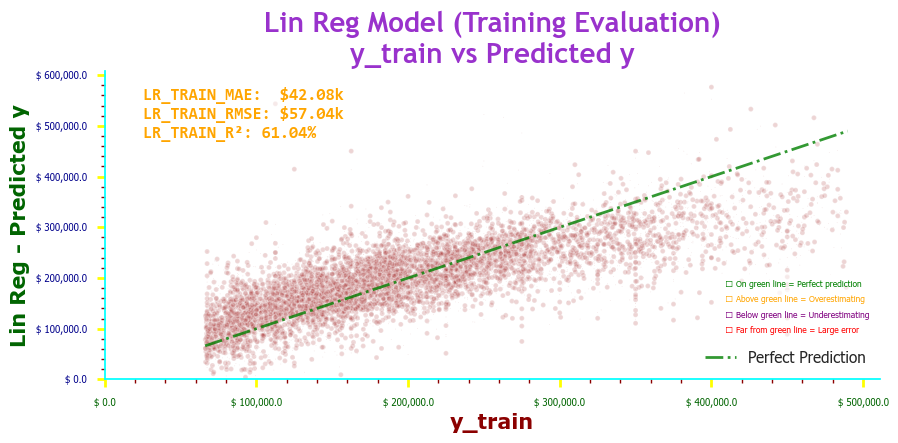

In [451]:
# Plot scatterplot and capture the returned axes
fig, lrmsp1 = plt.subplots(ncols=1, nrows=1, figsize=(10,4), layout=None, facecolor='white', dpi=100) # lightblue

#==#

# # Highlighting errors (residuals)
# for i in range(len(y_train)):
#     plt.vlines(y_train.iloc[i], y_train.iloc[i], y_pred_Linreg_train[i], 
#                color='gray', linestyle='dashed', alpha=0.2)

#==#

# Add metrics text
plt.text(0.05, 0.95, f'LR_TRAIN_MAE:  ${mae_Linreg_train/1000:,.2f}k\nLR_TRAIN_RMSE: ${rmse_Linreg_train/1000:,.2f}k\nLR_TRAIN_R²: {r2_score_Linreg_train:,.2%}', transform=plt.gca().transAxes,
color='orange', fontfamily='consolas', fontsize=12, fontweight='bold', ha='left', va='top', bbox=dict(facecolor='white', alpha=0.5))

#==#

# Add interpretation texts
plt.text(0.80, 0.30, '✅ On green line = Perfect prediction',
         transform=plt.gca().transAxes,
         fontsize=6, color='green',
         bbox=dict(facecolor='white', alpha=0.5))

plt.text(0.80, 0.25, '📈 Above green line = Overestimating',
         transform=plt.gca().transAxes,
         fontsize=6, color='orange',
         bbox=dict(facecolor='white', alpha=0.5))

plt.text(0.80, 0.20, '📉 Below green line = Underestimating',
         transform=plt.gca().transAxes,
         fontsize=6, color='purple',
         bbox=dict(facecolor='white', alpha=0.5))

plt.text(0.80, 0.15, '❌ Far from green line = Large error',
         transform=plt.gca().transAxes,
         fontsize=6, color='red',
         bbox=dict(facecolor='white', alpha=0.5))

#==#

lrmsp1.scatter(y_train, y_pred_Linreg_train, marker='.', sizes=(1, 50), c='brown', ec='white', alpha=0.2)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], c='green', ls='dashdot', lw=2, alpha=0.8, label='Perfect Prediction') # marker='H', ms=1, mfc='yellow', mec='cyan', label='prediction')
# It only looks like it's there twice because both X and Y use the same range! 🚀
lrmsp1.set_title('Lin Reg Model (Training Evaluation)'+'\ny_train vs Predicted y', fontdict=title_font)
lrmsp1.set_xlabel('y_train', loc='center', fontdict=x_label_font) # Independent Variable
lrmsp1.set_ylabel('Lin Reg - Predicted y', loc='center', fontdict=y_label_font) # Dependent Variable
# lrmsp1.grid(linestyle='dashdot', color='pink', linewidth=0.5)
lrmsp1.xaxis.set_major_formatter(StrMethodFormatter('$ {x:,}')) # £/$
# lrmsp1.xaxis.set_major_formatter(StrMethodFormatter('{x:,.1%}')) # %
lrmsp1.yaxis.set_major_formatter(StrMethodFormatter('$ {x:,}')) # £/$
# lrmsp1.xaxis.set_major_formatter(StrMethodFormatter('{x:,.1%}')) # %
lrmsp1.minorticks_on()
lrmsp1.tick_params(axis='x', bottom=True, top=False, length=6, width=2, color='yellow', direction='out', labelsize=7, labelcolor='darkgreen', labelfontfamily='tahoma', labelrotation=None)
lrmsp1.tick_params(axis='y', left=True, right=False, length=6, width=2, color='yellow', direction='out', labelsize=7, labelcolor='darkblue', labelfontfamily='tahoma', labelrotation=None)
lrmsp1.tick_params(axis='x', which='minor', bottom=True, top=False, length=3, width=1, color='darkred')
lrmsp1.tick_params(axis='y', which='minor', left=True, right=False,  length=3, width=1, color='darkred')
# lrmsp1.autoscale()
# lrmsp1.axis('equal')
lrmsp1.set_xlim(left=0)
lrmsp1.set_ylim(bottom=0)
# lrmsp1.set_xscale('log')
# lrmsp1.set_yscale('log')
# lrmsp1.set_yscale('linear')  # Try removing log scale
plt.legend(loc='lower right')

#==#

# # Save plot as png
# # my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\Assets"
# my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\2_Descriptive_Data_Analysis\Assets"
# plt.savefig(my_path + '/Py_00_MHV_Prediction_Lin_Reg_Model_Training_Eval_Scatterplot.png',transparent=None,dpi='figure',format=None,metadata=None,bbox_inches='tight',pad_inches=0.1,facecolor='auto',edgecolor='yellow',backend=None)

#==#

plt.show()

**`Scatterplot - Linear Regression Model (Test Evaluation) - Actual vs Predicted`**.

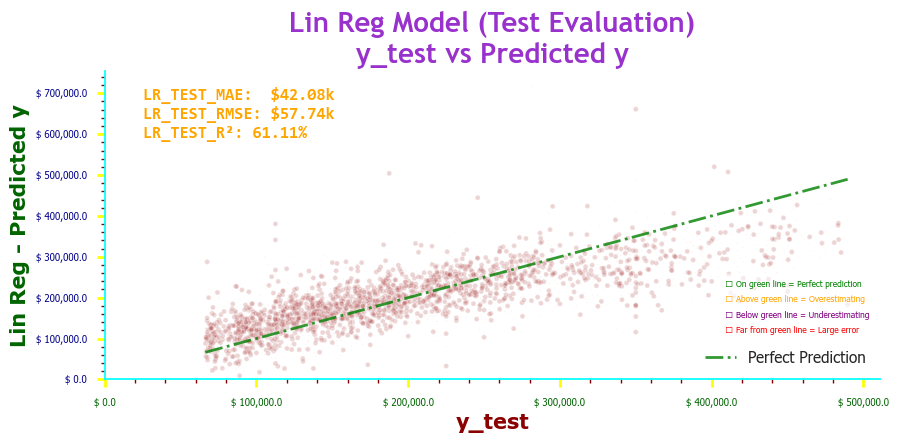

In [452]:
# Plot scatterplot and capture the returned axes
fig, lrmsp2 = plt.subplots(ncols=1, nrows=1, figsize=(10,4), layout=None, facecolor='white', dpi=100) # lightblue

#==#

# # Highlighting errors (residuals)
# for i in range(len(y_test)):
#     plt.vlines(y_test.iloc[i], y_test.iloc[i], y_pred_Linreg_test[i], 
#                color='gray', linestyle='dashed', alpha=0.2)

#==#

# Add metrics text
plt.text(0.05, 0.95, f'LR_TEST_MAE:  ${mae_Linreg_test/1000:,.2f}k\nLR_TEST_RMSE: ${rmse_Linreg_test/1000:,.2f}k\nLR_TEST_R²: {r2_score_Linreg_test:,.2%}', transform=plt.gca().transAxes,
color='orange', fontfamily='consolas', fontsize=12, fontweight='bold', ha='left', va='top', bbox=dict(facecolor='white', alpha=0.5))

#==#

# Add interpretation texts
plt.text(0.80, 0.30, '✅ On green line = Perfect prediction',
         transform=plt.gca().transAxes,
         fontsize=6, color='green',
         bbox=dict(facecolor='white', alpha=0.5))

plt.text(0.80, 0.25, '📈 Above green line = Overestimating',
         transform=plt.gca().transAxes,
         fontsize=6, color='orange',
         bbox=dict(facecolor='white', alpha=0.5))

plt.text(0.80, 0.20, '📉 Below green line = Underestimating',
         transform=plt.gca().transAxes,
         fontsize=6, color='purple',
         bbox=dict(facecolor='white', alpha=0.5))

plt.text(0.80, 0.15, '❌ Far from green line = Large error',
         transform=plt.gca().transAxes,
         fontsize=6, color='red',
         bbox=dict(facecolor='white', alpha=0.5))

#==#

lrmsp2.scatter(y_test, y_pred_Linreg_test, marker='.', sizes=(1, 50), c='brown', ec='white', alpha=0.2)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], c='green', ls='dashdot', lw=2, alpha=0.8, label='Perfect Prediction') # marker='H', ms=1, mfc='yellow', mec='cyan', label='prediction')
# It only looks like it's there twice because both X and Y use the same range! 🚀
lrmsp2.set_title('Lin Reg Model (Test Evaluation)'+'\ny_test vs Predicted y', fontdict=title_font)
lrmsp2.set_xlabel('y_test', loc='center', fontdict=x_label_font) # Independent Variable
lrmsp2.set_ylabel('Lin Reg - Predicted y', loc='center', fontdict=y_label_font) # Dependent Variable
# lrmsp2.grid(linestyle='dashdot', color='pink', linewidth=0.5)
lrmsp2.xaxis.set_major_formatter(StrMethodFormatter('$ {x:,}')) # £/$
# lrmsp2.xaxis.set_major_formatter(StrMethodFormatter('{x:,.1%}')) # %
lrmsp2.yaxis.set_major_formatter(StrMethodFormatter('$ {x:,}')) # £/$
# lrmsp2.xaxis.set_major_formatter(StrMethodFormatter('{x:,.1%}')) # %
lrmsp2.minorticks_on()
lrmsp2.tick_params(axis='x', bottom=True, top=False, length=6, width=2, color='yellow', direction='out', labelsize=7, labelcolor='darkgreen', labelfontfamily='tahoma', labelrotation=None)
lrmsp2.tick_params(axis='y', left=True, right=False, length=6, width=2, color='yellow', direction='out', labelsize=7, labelcolor='darkblue', labelfontfamily='tahoma', labelrotation=None)
lrmsp2.tick_params(axis='x', which='minor', bottom=True, top=False, length=3, width=1, color='darkred')
lrmsp2.tick_params(axis='y', which='minor', left=True, right=False,  length=3, width=1, color='darkred')
# lrmsp2.autoscale()
# lrmsp2.axis('equal')
lrmsp2.set_xlim(left=0)
lrmsp2.set_ylim(bottom=0)
# lrmsp2.set_xscale('log')
# lrmsp2.set_yscale('log')
# lrmsp2.set_yscale('linear')  # Try removing log scale
plt.legend(loc='lower right')

#==#

# # Save plot as png
# # my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\Assets"
# my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\2_Descriptive_Data_Analysis\Assets"
# plt.savefig(my_path + '/Py_00_MHV_Prediction_Lin_Reg_Model_Test_Eval_Scatterplot.png',transparent=None,dpi='figure',format=None,metadata=None,bbox_inches='tight',pad_inches=0.1,facecolor='auto',edgecolor='yellow',backend=None)

#==#
plt.show()

**`Scatterplot - Linear Regression Model (Validation Evaluation) - Actual vs Predicted`**.

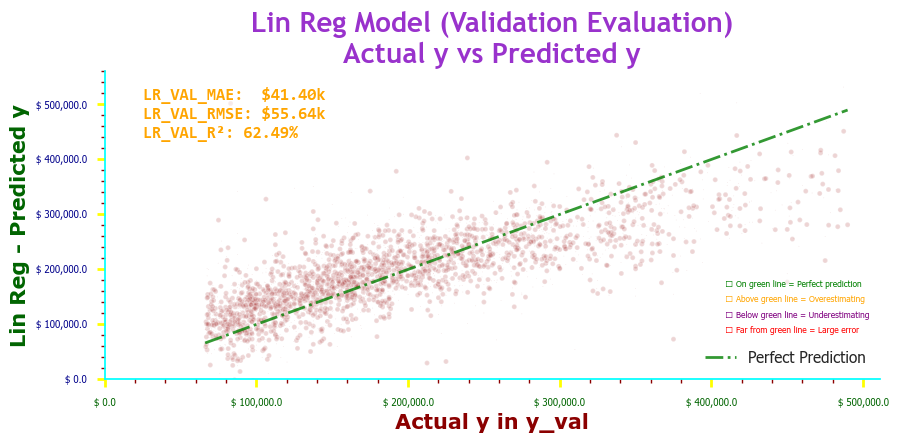

In [453]:
# Plot scatterplot and capture the returned axes
fig, lrmsp3 = plt.subplots(ncols=1, nrows=1, figsize=(10,4), layout=None, facecolor='white', dpi=100) # lightblue

#==#

# # Highlighting errors (residuals)
# for i in range(len(y_val)):
#     plt.vlines(y_val.iloc[i], y_val.iloc[i], y_pred_Linreg_val[i], 
#                color='gray', linestyle='dashed', alpha=0.2)

#==#

# Add metrics text
plt.text(0.05, 0.95, f'LR_VAL_MAE:  ${mae_Linreg_val/1000:,.2f}k\nLR_VAL_RMSE: ${rmse_Linreg_val/1000:,.2f}k\nLR_VAL_R²: {r2_score_Linreg_val:,.2%}', transform=plt.gca().transAxes,
color='orange', fontfamily='consolas', fontsize=12, fontweight='bold', ha='left', va='top', bbox=dict(facecolor='white', alpha=0.5))

#==#

# Add interpretation texts
plt.text(0.80, 0.30, '✅ On green line = Perfect prediction',
         transform=plt.gca().transAxes,
         fontsize=6, color='green',
         bbox=dict(facecolor='white', alpha=0.5))

plt.text(0.80, 0.25, '📈 Above green line = Overestimating',
         transform=plt.gca().transAxes,
         fontsize=6, color='orange',
         bbox=dict(facecolor='white', alpha=0.5))

plt.text(0.80, 0.20, '📉 Below green line = Underestimating',
         transform=plt.gca().transAxes,
         fontsize=6, color='purple',
         bbox=dict(facecolor='white', alpha=0.5))

plt.text(0.80, 0.15, '❌ Far from green line = Large error',
         transform=plt.gca().transAxes,
         fontsize=6, color='red',
         bbox=dict(facecolor='white', alpha=0.5))

#==#

lrmsp3.scatter(y_val, y_pred_Linreg_val, marker='.', sizes=(1, 50), c='brown', ec='white', alpha=0.2)
# It only looks like it's there twice because both X and Y use the same range! 🚀
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], c='green', ls='dashdot', lw=2, alpha=0.8, label='Perfect Prediction') # marker='H', ms=1, mfc='yellow', mec='cyan', label='prediction')
lrmsp3.set_title('Lin Reg Model (Validation Evaluation)'+'\nActual y vs Predicted y', fontdict=title_font)
lrmsp3.set_xlabel('Actual y in y_val', loc='center', fontdict=x_label_font) # Independent Variable
lrmsp3.set_ylabel('Lin Reg - Predicted y', loc='center', fontdict=y_label_font) # Dependent Variable
# lrmsp3.grid(linestyle='dashdot', color='pink', linewidth=0.5)
lrmsp3.xaxis.set_major_formatter(StrMethodFormatter('$ {x:,}')) # £/$
# lrmsp3.xaxis.set_major_formatter(StrMethodFormatter('{x:,.1%}')) # %
lrmsp3.yaxis.set_major_formatter(StrMethodFormatter('$ {x:,}')) # £/$
# lrmsp3.xaxis.set_major_formatter(StrMethodFormatter('{x:,.1%}')) # %
lrmsp3.minorticks_on()
lrmsp3.tick_params(axis='x', bottom=True, top=False, length=6, width=2, color='yellow', direction='out', labelsize=7, labelcolor='darkgreen', labelfontfamily='tahoma', labelrotation=None)
lrmsp3.tick_params(axis='y', left=True, right=False, length=6, width=2, color='yellow', direction='out', labelsize=7, labelcolor='darkblue', labelfontfamily='tahoma', labelrotation=None)
lrmsp3.tick_params(axis='x', which='minor', bottom=True, top=False, length=3, width=1, color='darkred')
lrmsp3.tick_params(axis='y', which='minor', left=True, right=False,  length=3, width=1, color='darkred')
# lrmsp3.autoscale()
# lrmsp3.axis('equal')
lrmsp3.set_xlim(left=0)
lrmsp3.set_ylim(bottom=0)
# lrmsp3.set_xscale('log')
# lrmsp3.set_yscale('log')
# lrmsp3.set_yscale('linear')  # Try removing log scale
plt.legend(loc='lower right')

#==#

# # Save plot as png
# # my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\Assets"
# my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\2_Descriptive_Data_Analysis\Assets"
# plt.savefig(my_path + '/Py_00_MHV_Prediction_Lin_Reg_Model_Validation_Eval_Scatterplot.png',transparent=None,dpi='figure',format=None,metadata=None,bbox_inches='tight',pad_inches=0.1,facecolor='auto',edgecolor='yellow',backend=None)

#==#

plt.show()

**`Scatterplot - GBoost Model - Actual vs Predicted`**.

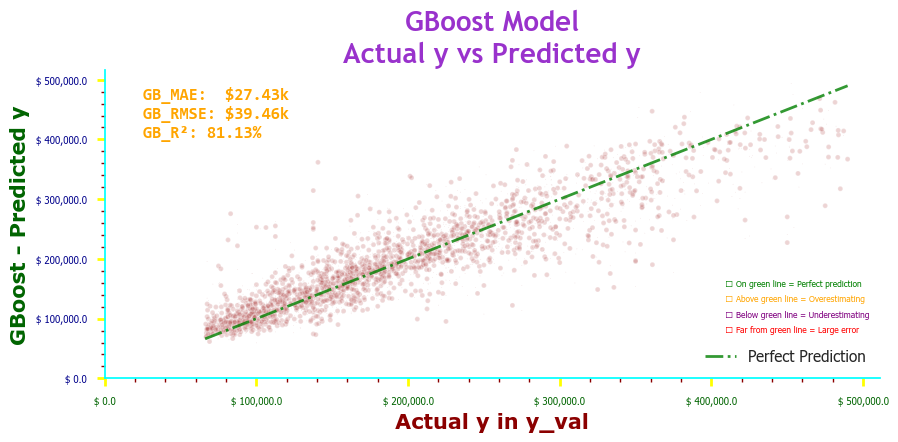

In [454]:
# Plot scatterplot and capture the returned axes
fig, lrmsp4 = plt.subplots(ncols=1, nrows=1, figsize=(10,4), layout=None, facecolor='white', dpi=100) # lightblue

#==#

# # Highlighting errors (residuals)
# for i in range(len(y_val)):
#     plt.vlines(y_val.iloc[i], y_val.iloc[i], y_pred_gb[i], 
#                color='gray', linestyle='dashed', alpha=0.2)

#==#

# Add metrics text
plt.text(0.05, 0.95, f'GB_MAE:  ${gb_mae/1000:,.2f}k\nGB_RMSE: ${gb_rmse/1000:,.2f}k\nGB_R²: {gb_r2:,.2%}', transform=plt.gca().transAxes,
color='orange', fontfamily='consolas', fontsize=12, fontweight='bold', ha='left', va='top', bbox=dict(facecolor='white', alpha=0.5))

#==#

# Add interpretation texts
plt.text(0.80, 0.30, '✅ On green line = Perfect prediction',
         transform=plt.gca().transAxes,
         fontsize=6, color='green',
         bbox=dict(facecolor='white', alpha=0.5))

plt.text(0.80, 0.25, '📈 Above green line = Overestimating',
         transform=plt.gca().transAxes,
         fontsize=6, color='orange',
         bbox=dict(facecolor='white', alpha=0.5))

plt.text(0.80, 0.20, '📉 Below green line = Underestimating',
         transform=plt.gca().transAxes,
         fontsize=6, color='purple',
         bbox=dict(facecolor='white', alpha=0.5))

plt.text(0.80, 0.15, '❌ Far from green line = Large error',
         transform=plt.gca().transAxes,
         fontsize=6, color='red',
         bbox=dict(facecolor='white', alpha=0.5))

#==#

lrmsp4.scatter(y_val, y_pred_gb, marker='.', sizes=(1, 50), c='brown', ec='white', alpha=0.2)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], c='green', ls='dashdot', lw=2, alpha=0.8, label='Perfect Prediction') # marker='H', ms=1, mfc='yellow', mec='cyan', label='prediction')
# It only looks like it's there twice because both X and Y use the same range! 🚀
lrmsp4.set_title('GBoost Model'+'\nActual y vs Predicted y', fontdict=title_font)
lrmsp4.set_xlabel('Actual y in y_val', loc='center', fontdict=x_label_font) # Independent Variable
lrmsp4.set_ylabel('GBoost - Predicted y', loc='center', fontdict=y_label_font) # Dependent Variable
# lrmsp4.grid(linestyle='dashdot', color='pink', linewidth=0.5)
lrmsp4.xaxis.set_major_formatter(StrMethodFormatter('$ {x:,}')) # £/$
# lrmsp4.xaxis.set_major_formatter(StrMethodFormatter('{x:,.1%}')) # %
lrmsp4.yaxis.set_major_formatter(StrMethodFormatter('$ {x:,}')) # £/$
# lrmsp4.xaxis.set_major_formatter(StrMethodFormatter('{x:,.1%}')) # %
lrmsp4.minorticks_on()
lrmsp4.tick_params(axis='x', bottom=True, top=False, length=6, width=2, color='yellow', direction='out', labelsize=7, labelcolor='darkgreen', labelfontfamily='tahoma', labelrotation=None)
lrmsp4.tick_params(axis='y', left=True, right=False, length=6, width=2, color='yellow', direction='out', labelsize=7, labelcolor='darkblue', labelfontfamily='tahoma', labelrotation=None)
lrmsp4.tick_params(axis='x', which='minor', bottom=True, top=False, length=3, width=1, color='darkred')
lrmsp4.tick_params(axis='y', which='minor', left=True, right=False,  length=3, width=1, color='darkred')
# lrmsp4.autoscale()
# lrmsp4.axis('equal')
lrmsp4.set_xlim(left=0)
lrmsp4.set_ylim(bottom=0)
# lrmsp4.set_xscale('log')
# lrmsp4.set_yscale('log')
# lrmsp4.set_yscale('linear')  # Try removing log scale
plt.legend(loc='lower right')

#==#

# # Save plot as png
# # my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\Assets"
# my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\2_Descriptive_Data_Analysis\Assets"
# plt.savefig(my_path + '/Py_00_MHV_Prediction_GBoost_Model_Scatterplot.png',transparent=None,dpi='figure',format=None,metadata=None,bbox_inches='tight',pad_inches=0.1,facecolor='auto',edgecolor='yellow',backend=None)

#==#

plt.show()

**`Scatterplot - XGBoost Model - Actual vs Predicted 🎉`**.

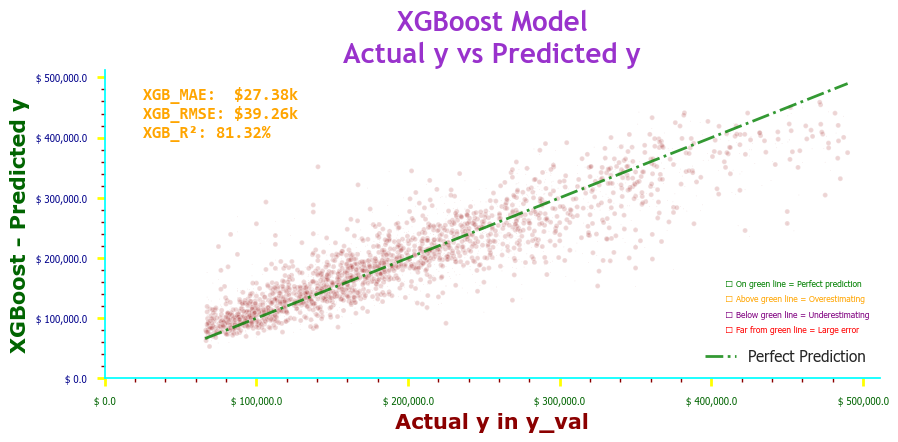

In [455]:
# Plot scatterplot and capture the returned axes
fig, lrmsp5 = plt.subplots(ncols=1, nrows=1, figsize=(10,4), layout=None, facecolor='white', dpi=100) # lightblue

#==#

# # Highlighting errors (residuals)
# for i in range(len(y_val)):
#     plt.vlines(y_val.iloc[i], y_val.iloc[i], y_pred_xgb[i], 
#                color='gray', linestyle='dashed', alpha=0.2)

#==#

# Add metrics text
plt.text(0.05, 0.95, f'XGB_MAE:  ${xgb_mae/1000:,.2f}k\nXGB_RMSE: ${xgb_rmse/1000:,.2f}k\nXGB_R²: {xgb_r2:,.2%}', transform=plt.gca().transAxes,
color='orange', fontfamily='consolas', fontsize=12, fontweight='bold', ha='left', va='top', bbox=dict(facecolor='white', alpha=0.5))

#==#

# Add interpretation texts
plt.text(0.80, 0.30, '✅ On green line = Perfect prediction',
         transform=plt.gca().transAxes,
         fontsize=6, color='green',
         bbox=dict(facecolor='white', alpha=0.5))

plt.text(0.80, 0.25, '📈 Above green line = Overestimating',
         transform=plt.gca().transAxes,
         fontsize=6, color='orange',
         bbox=dict(facecolor='white', alpha=0.5))

plt.text(0.80, 0.20, '📉 Below green line = Underestimating',
         transform=plt.gca().transAxes,
         fontsize=6, color='purple',
         bbox=dict(facecolor='white', alpha=0.5))

plt.text(0.80, 0.15, '❌ Far from green line = Large error',
         transform=plt.gca().transAxes,
         fontsize=6, color='red',
         bbox=dict(facecolor='white', alpha=0.5))

#==#

lrmsp5.scatter(y_val, y_pred_xgb, marker='.', sizes=(1, 50), c='brown', ec='white', alpha=0.2)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], c='green', ls='dashdot', lw=2, alpha=0.8, label='Perfect Prediction') # marker='H', ms=1, mfc='yellow', mec='cyan', label='prediction')
# It only looks like it's there twice because both X and Y use the same range! 🚀
lrmsp5.set_title('XGBoost Model'+'\nActual y vs Predicted y', fontdict=title_font)
lrmsp5.set_xlabel('Actual y in y_val', loc='center', fontdict=x_label_font) # Independent Variable
lrmsp5.set_ylabel('XGBoost - Predicted y', loc='center', fontdict=y_label_font) # Dependent Variable
# lrmsp5.grid(linestyle='dashdot', color='pink', linewidth=0.5)
lrmsp5.xaxis.set_major_formatter(StrMethodFormatter('$ {x:,}')) # £/$
# lrmsp5.xaxis.set_major_formatter(StrMethodFormatter('{x:,.1%}')) # %
lrmsp5.yaxis.set_major_formatter(StrMethodFormatter('$ {x:,}')) # £/$
# lrmsp5.xaxis.set_major_formatter(StrMethodFormatter('{x:,.1%}')) # %
lrmsp5.minorticks_on()
lrmsp5.tick_params(axis='x', bottom=True, top=False, length=6, width=2, color='yellow', direction='out', labelsize=7, labelcolor='darkgreen', labelfontfamily='tahoma', labelrotation=None)
lrmsp5.tick_params(axis='y', left=True, right=False, length=6, width=2, color='yellow', direction='out', labelsize=7, labelcolor='darkblue', labelfontfamily='tahoma', labelrotation=None)
lrmsp5.tick_params(axis='x', which='minor', bottom=True, top=False, length=3, width=1, color='darkred')
lrmsp5.tick_params(axis='y', which='minor', left=True, right=False,  length=3, width=1, color='darkred')
# lrmsp5.autoscale()
# lrmsp5.axis('equal')
lrmsp5.set_xlim(left=0)
lrmsp5.set_ylim(bottom=0)
# lrmsp5.set_xscale('log')
# lrmsp5.set_yscale('log')
# lrmsp5.set_yscale('linear')  # Try removing log scale
plt.legend(loc='lower right')

#==#

# # Save plot as png
# # my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\Assets"
# my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\2_Descriptive_Data_Analysis\Assets"
# plt.savefig(my_path + '/Py_00_MHV_Prediction_XGBoost_Model_Scatterplot.png',transparent=None,dpi='figure',format=None,metadata=None,bbox_inches='tight',pad_inches=0.1,facecolor='auto',edgecolor='yellow',backend=None)

#==#

plt.show()

##### `📊🏠💰 Step 9 - Visualise Input Value And Median House Price Predictions!🎉`.

**`Scatterplot - Linear Regression Model - Actual vs Predicted (Input to Prediction) 🎉`**.
- --
 - `We feed the median income into our linear regression model and it predicts the median house value`.

[8325.2 8301.4 2080.4 ... 1700.  1867.2 2388.6]


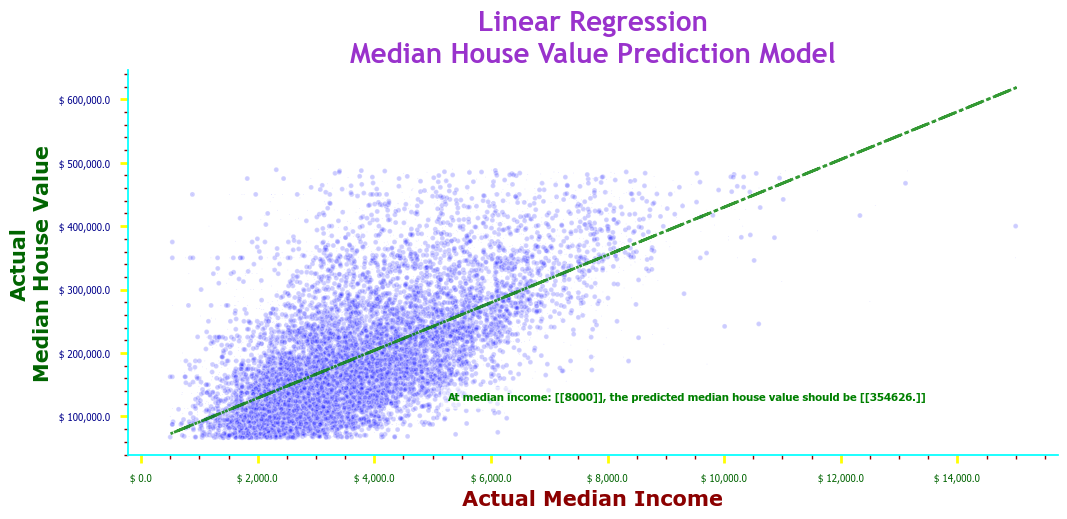

Coefficients: 
 [[37.61072073]]
At median income: [[8000]], the predicted median house value should be [[354626.]]
The predicted median house value should be: [[354625.62617554]]


In [456]:
x = housing['median_income'].values # median income
# x = housing.iloc[:,10].values # median income
print(x)
y = housing['median_house_value'].values # median house values
# y = housing.iloc[:,11].values # median income

# Simple Regression only takes in 1D arrays. # Reshape takes an array and reshapes it to the shape we specify.
y=y.reshape(-1, 1) # .reshape(1,-1) turns the data into 1D.
x=x.reshape(-1, 1) # .reshape(1,-1) turns the data into 1D.

#==#

# Create an empty Linear regression model
median_house_value_model = LinearRegression()

# Use .fit(x,y) to prepare the data for prediction
median_house_value_model.fit(x, y)

# Median House Value Prediction Model
y_pred = median_house_value_model.predict(x)


#==#

unk_x = [[8000]] # The value added to dataset

# Reshape takes an array and reshapes it to the shape we specify.
# Simple Regression only takes in 1D arrays. 
# .append() turns data to 2D.
# .reshape(1,-1) turns the data into 1D. 
# np.append(x,unk_x) - We merge x and unk_x.
x_pred = np.append(x, unk_x).reshape(-1, 1)  # .reshape() is from numpy.
y_pred = median_house_value_model.predict(x_pred) # Feed in X prediction and get Y prediction. .predict() is from sklearn.

#==#

# Plot subplots
# fig = plt.figure(figsize=(10,10),layout='constrained',facecolor='lightblue',dpi=100)
# lrmsp = fig.add_subplot(421) #421, 341 # Scatterplot - Median Income Prediction Model

#==#

# Plot scatterplot and capture the returned axes
fig, lrmsp = plt.subplots(ncols=1, nrows=1, figsize=(12,5), layout=None, facecolor='white', dpi=100) # lightblue

#==#

# Annotate the input median income and predicted median house value on plot
plt.text(0.60, 0.15, f'At median income: {unk_x}, the predicted median house value should be {median_house_value_model.predict(unk_x).round(0)}',
         transform=plt.gca().transAxes,
         color='green', ha='center', va='center', family='tahoma', fontstyle='normal', fontsize=8, fontweight='bold', rotation=0,
         bbox=dict(facecolor='white', alpha=0.5))

#==#

lrmsp.scatter(x, y, marker='.', sizes=(1, 50), c='blue', ec='white', alpha=0.2)
lrmsp.plot(x_pred, y_pred, c='green', ls='dashdot', lw=2, alpha=0.8) # marker='H', ms=1, mfc='yellow', mec='cyan', label='prediction')
lrmsp.set_title('Linear Regression'+'\nMedian House Value Prediction Model', fontdict=title_font)
lrmsp.set_xlabel('Actual Median Income', loc='center', fontdict=x_label_font) # Independent Variable
lrmsp.set_ylabel('Actual'+'\nMedian House Value', loc='center', fontdict=y_label_font) # Dependent Variable
# lrmsp.grid(linestyle='dashdot', color='pink', linewidth=0.5)
lrmsp.xaxis.set_major_formatter(StrMethodFormatter('$ {x:,}')) # £/$
# lrmsp.xaxis.set_major_formatter(StrMethodFormatter('{x:,.1%}')) # %
lrmsp.yaxis.set_major_formatter(StrMethodFormatter('$ {x:,}')) # £/$
# lrmsp.xaxis.set_major_formatter(StrMethodFormatter('{x:,.1%}')) # %
lrmsp.minorticks_on()
lrmsp.tick_params(axis='x', bottom=True, top=False, length=6, width=2, color='yellow', direction='out', labelsize=7, labelcolor='darkgreen', labelfontfamily='tahoma', labelrotation=None)
lrmsp.tick_params(axis='y', left=True, right=False, length=6, width=2, color='yellow', direction='out', labelsize=7, labelcolor='darkblue', labelfontfamily='tahoma', labelrotation=None)
lrmsp.tick_params(axis='x', which='minor', bottom=True, top=False, length=3, width=1, color='darkred')
lrmsp.tick_params(axis='y', which='minor', left=True, right=False,  length=3, width=1, color='darkred')
# lrmsp.autoscale()
# lrmsp.axis('equal')
# lrmsp.set_xlim(left=0)
# lrmsp.set_ylim(bottom=0)
# lrmsp.set_xscale('log')
# lrmsp.set_yscale('log')
# lrmsp.set_yscale('linear')  # Try removing log scale

#==#

# # Save plot as png
# # my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\Assets"
# my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\2_Descriptive_Data_Analysis\Assets"
# plt.savefig(my_path + '/Py_00_MHV_Prediction_From_Input_Median_Income_Value_Lin_Reg_Model_Scatterplot.png',transparent=None,dpi='figure',format=None,metadata=None,bbox_inches='tight',pad_inches=0.1,facecolor='auto',edgecolor='yellow',backend=None)

#==#

plt.show()

#==#
print("Coefficients: \n", median_house_value_model.coef_)
print(f'At median income: {unk_x}, the predicted median house value should be {median_house_value_model.predict(unk_x).round(0)}')
print("The predicted median house value should be:", median_house_value_model.predict([[8000]])) # Input value as a 2D array.

**`Scatterplot - GBoost Model - Actual vs Predicted (Input to Prediction) 🎉`**.
- --
 - `We feed the median income into the GBoost model and it predicts the median house value`.

[8325.2 8301.4 2080.4 ... 1700.  1867.2 2388.6]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


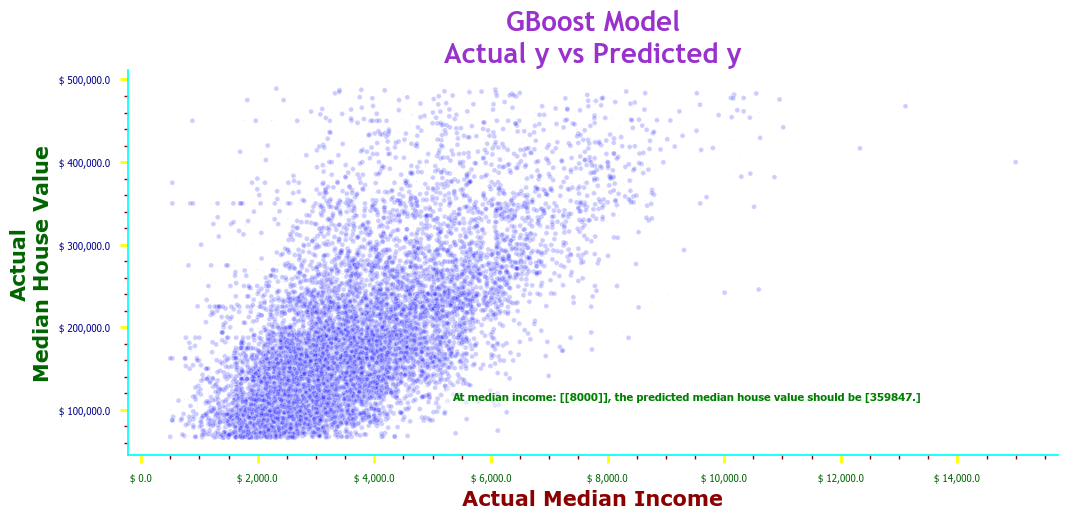

At median income: [[8000]], the predicted median house value should be [359847.]
The predicted median house value should be: [359846.95329222]


In [457]:
x = housing['median_income'].values # median income
# x = housing.iloc[:,10].values # median income
print(x)
y = housing['median_house_value'].values # median house values
# y = housing.iloc[:,11].values # median income

#==#

# Simple Regression only takes in 1D arrays. # Reshape takes an array and reshapes it to the shape we specify.
y=y.reshape(-1, 1) # .reshape(1,-1) turns the data into 1D.
x=x.reshape(-1, 1) # .reshape(1,-1) turns the data into 1D.

#==#

# XGBoost Model
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
median_house_value_gb_model = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)

#==#

# Use .fit(x, y) to prepare the data for prediction
median_house_value_gb_model.fit(x, y)
# y_pred_gb = median_house_value_gb_model.predict(x_pred)

#==#

unk_x = [[8000]] # The value added to dataset

#==#

# Reshape takes an array and reshapes it to the shape we specify.
# Simple Regression only takes in 1D arrays. 
# .append() turns data to 2D.
# .reshape(-1,1) turns the data into 1D. 
# np.append(x,unk_x) - We merge x and unk_x.
x_pred = np.sort(np.append(x, unk_x)).reshape(-1, 1)  # .reshape() is from numpy.
y_pred_gb = median_house_value_gb_model.predict(x_pred) # Feed in X prediction and get Y prediction. .predict() is from sklearn.

#==#

# Plot subplots
# fig = plt.figure(figsize=(10,10),layout='constrained',facecolor='lightblue',dpi=100)
# gbmsp = fig.add_subplot(421) #421, 341 # Scatterplot - Median Income Prediction Model

#==#

# Plot scatterplot and capture the returned axes
fig, gbmsp = plt.subplots(ncols=1, nrows=1, figsize=(12,5), layout=None, facecolor='white', dpi=100) # lightblue

#==#

plt.text(0.60, 0.15, f'At median income: {unk_x}, the predicted median house value should be {median_house_value_gb_model.predict(unk_x).round(0)}',
         transform=plt.gca().transAxes,
         color='green', ha='center', va='center', family='tahoma', fontstyle='normal', fontsize=8, fontweight='bold', rotation=0,
         bbox=dict(facecolor='white', alpha=0.5))

#==#

gbmsp.scatter(x, y, marker='.', sizes=(1, 50), c='blue', ec='white', alpha=0.2)
# gbmsp.plot(x_pred, y_pred_gb, c='red', ls='dashdot', lw=3, alpha=0.2, label='Perfect Prediction') # marker='H', ms=1, mfc='yellow', mec='cyan', label='prediction')
gbmsp.set_title('GBoost Model'+'\nActual y vs Predicted y', fontdict=title_font)
gbmsp.set_xlabel('Actual Median Income', loc='center', fontdict=x_label_font) # Independent Variable
gbmsp.set_ylabel('Actual'+'\nMedian House Value', loc='center', fontdict=y_label_font) # Dependent Variable
# gbmsp.grid(linestyle='dashdot', color='pink', linewidth=0.5)
gbmsp.xaxis.set_major_formatter(StrMethodFormatter('$ {x:,}')) # £/$
# gbmsp.xaxis.set_major_formatter(StrMethodFormatter('{x:,.1%}')) # %
gbmsp.yaxis.set_major_formatter(StrMethodFormatter('$ {x:,}')) # £/$
# gbmsp.xaxis.set_major_formatter(StrMethodFormatter('{x:,.1%}')) # %
gbmsp.minorticks_on()
gbmsp.tick_params(axis='x', bottom=True, top=False, length=6, width=2, color='yellow', direction='out', labelsize=7, labelcolor='darkgreen', labelfontfamily='tahoma', labelrotation=None)
gbmsp.tick_params(axis='y', left=True, right=False, length=6, width=2, color='yellow', direction='out', labelsize=7, labelcolor='darkblue', labelfontfamily='tahoma', labelrotation=None)
gbmsp.tick_params(axis='x', which='minor', bottom=True, top=False, length=3, width=1, color='darkred')
gbmsp.tick_params(axis='y', which='minor', left=True, right=False,  length=3, width=1, color='darkred')
# gbmsp.autoscale()
# gbmsp.axis('equal')
# gbmsp.set_xlim(left=0)
# gbmsp.set_ylim(bottom=0)
# gbmsp.set_xscale('log')
# gbmsp.set_yscale('log')
# gbmsp.set_yscale('linear')  # Try removing log scale
plt.legend(loc='lower right')

# # Save plot as png
# # my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\Assets"
# my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\2_Descriptive_Data_Analysis\Assets"
# plt.savefig(my_path + '/Py_00_MHV_Prediction_From_Input_Median_Income_Value_GBoost_Model_Scatterplot.png',transparent=None,dpi='figure',format=None,metadata=None,bbox_inches='tight',pad_inches=0.1,facecolor='auto',edgecolor='yellow',backend=None)

#==#

plt.show()

# print("Coefficients: \n", median_house_value_gb_model.coef_)
print(f'At median income: {unk_x}, the predicted median house value should be {median_house_value_gb_model.predict(unk_x).round(0)}')
print("The predicted median house value should be:", median_house_value_gb_model.predict([[8000]])) # Input value as a 2D array.

**`Scatterplot - XGBoost Model - Actual vs Predicted (Input to Prediction) 🎉`**.
- --
 - `We feed the median income into the XGBoost model and it predicts the median house value`.

[8325.2 8301.4 2080.4 ... 1700.  1867.2 2388.6]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


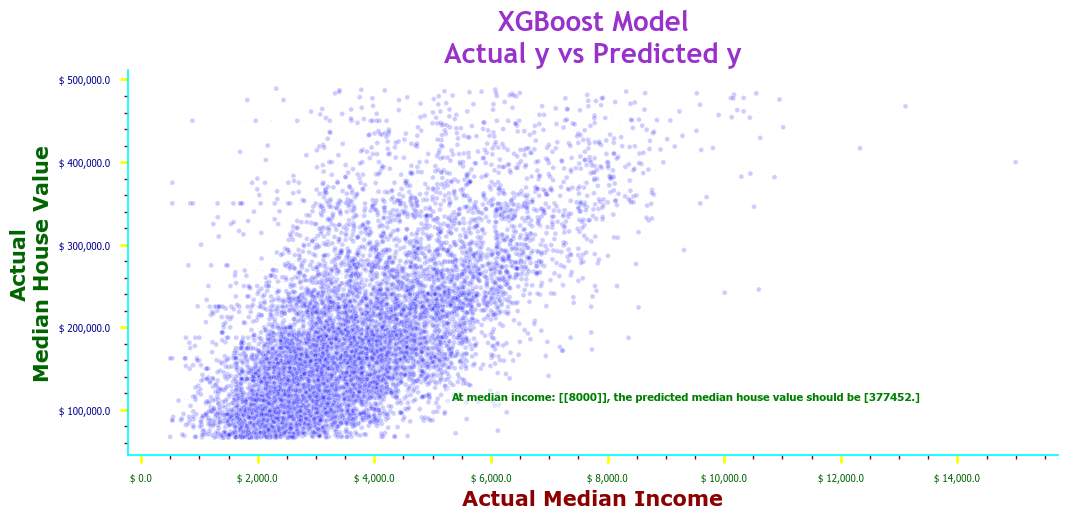

At median income: [[8000]], the predicted median house value should be [377452.]
The predicted median house value should be: [377451.9]


In [458]:
x = housing['median_income'].values # median income
# x = housing.iloc[:,10].values # median income
print(x)
y = housing['median_house_value'].values # median house values
# y = housing.iloc[:,11].values # median income

#==#

# Simple Regression only takes in 1D arrays. # Reshape takes an array and reshapes it to the shape we specify.
y=y.reshape(-1, 1) # .reshape(1,-1) turns the data into 1D.
x=x.reshape(-1, 1) # .reshape(1,-1) turns the data into 1D.

#==#

# XGBoost Model
# from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
# # median_house_value_gb_model = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)

#==#

# XGBoost Model
from xgboost import XGBRegressor
median_house_value_gb_model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, subsample=0.8, 
                                                        colsample_bytree=0.8, random_state=42, n_jobs=-1)

#==#

# Use .fit(x, y) to prepare the data for prediction
median_house_value_gb_model.fit(x, y)
# y_pred_gb = median_house_value_gb_model.predict(x_pred)

#==#

unk_x = [[8000]] # The value added to dataset

#==#

# Reshape takes an array and reshapes it to the shape we specify.
# Simple Regression only takes in 1D arrays. 
# .append() turns data to 2D.
# .reshape(-1,1) turns the data into 1D. 
# np.append(x,unk_x) - We merge x and unk_x.
x_pred = np.sort(np.append(x, unk_x)).reshape(-1, 1)  # .reshape() is from numpy.
y_pred_gb = median_house_value_gb_model.predict(x_pred) # Feed in X prediction and get Y prediction. .predict() is from sklearn.

#==#

# Plot subplots
# fig = plt.figure(figsize=(10,10),layout='constrained',facecolor='lightblue',dpi=100)
# xgbmsp = fig.add_subplot(421) #421, 341 # Scatterplot - Median Income Prediction Model

#==#

# Plot scatterplot and capture the returned axes
fig, xgbmsp = plt.subplots(ncols=1, nrows=1, figsize=(12,5), layout=None, facecolor='white', dpi=100) # lightblue

#==#

plt.text(0.60, 0.15, f'At median income: {unk_x}, the predicted median house value should be {median_house_value_gb_model.predict(unk_x).round(0)}',
         transform=plt.gca().transAxes,
         color='green', ha='center', va='center', family='tahoma', fontstyle='normal', fontsize=8, fontweight='bold', rotation=0,
         bbox=dict(facecolor='white', alpha=0.5))

#==#

xgbmsp.scatter(x, y, marker='.', sizes=(1, 50), c='blue', ec='white', alpha=0.2)
# xgbmsp.plot(x_pred, y_pred_gb, c='red', ls='dashdot', lw=3, alpha=0.2, label='Perfect Prediction') # marker='H', ms=1, mfc='yellow', mec='cyan', label='prediction')
xgbmsp.set_title('XGBoost Model'+'\nActual y vs Predicted y', fontdict=title_font)
xgbmsp.set_xlabel('Actual Median Income', loc='center', fontdict=x_label_font) # Independent Variable
xgbmsp.set_ylabel('Actual'+'\nMedian House Value', loc='center', fontdict=y_label_font) # Dependent Variable
# xgbmsp.grid(linestyle='dashdot', color='pink', linewidth=0.5)
xgbmsp.xaxis.set_major_formatter(StrMethodFormatter('$ {x:,}')) # £/$
# xgbmsp.xaxis.set_major_formatter(StrMethodFormatter('{x:,.1%}')) # %
xgbmsp.yaxis.set_major_formatter(StrMethodFormatter('$ {x:,}')) # £/$
# xgbmsp.xaxis.set_major_formatter(StrMethodFormatter('{x:,.1%}')) # %
xgbmsp.minorticks_on()
xgbmsp.tick_params(axis='x', bottom=True, top=False, length=6, width=2, color='yellow', direction='out', labelsize=7, labelcolor='darkgreen', labelfontfamily='tahoma', labelrotation=None)
xgbmsp.tick_params(axis='y', left=True, right=False, length=6, width=2, color='yellow', direction='out', labelsize=7, labelcolor='darkblue', labelfontfamily='tahoma', labelrotation=None)
xgbmsp.tick_params(axis='x', which='minor', bottom=True, top=False, length=3, width=1, color='darkred')
xgbmsp.tick_params(axis='y', which='minor', left=True, right=False,  length=3, width=1, color='darkred')
# xgbmsp.autoscale()
# xgbmsp.axis('equal')
# xgbmsp.set_xlim(left=0)
# xgbmsp.set_ylim(bottom=0)
# xgbmsp.set_xscale('log')
# xgbmsp.set_yscale('log')
# xgbmsp.set_yscale('linear')  # Try removing log scale
plt.legend(loc='lower right')

# # Save plot as png
# # my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\Assets"
# my_path = r"\Users\tailb\Data Science\GH_Projects\Python_Projects\California_Housing_Market_Data_Analysis\2_Descriptive_Data_Analysis\Assets"
# plt.savefig(my_path + '/Py_00_MHV_Prediction_From_Input_Median_Income_Value_XGBoost_Model_Scatterplot.png',transparent=None,dpi='figure',format=None,metadata=None,bbox_inches='tight',pad_inches=0.1,facecolor='auto',edgecolor='yellow',backend=None)

#==#

plt.show()

# print("Coefficients: \n", median_house_value_gb_model.coef_)
print(f'At median income: {unk_x}, the predicted median house value should be {median_house_value_gb_model.predict(unk_x).round(0)}')
print("The predicted median house value should be:", median_house_value_gb_model.predict([[8000]])) # Input value as a 2D array.

##### `🤔 Step 10 - Can We Improve The Model?`.

**`Log Transform Target Variable`**.

**`Why Log Transform?`**:
- --
  - **`House prices are typically right skewed — a few very expensive homes pull the distribution`**.
  - **`Log transform makes the distribution more normal`**.
  - **`This can help the model learn more effectively`**.
- --
**`Notes`**:
  - **`np.log()`** — **`Applies natural log to target variable`**.
  - **`np.exp()`** — **`Reverses the log transform on predictions`.**
  - **`⚠️ Always reverse transform before evaluating — otherwise metrics are meaningless`**.
  - **`We only transform y, not X features`**.
  - **`🎯 Target to beat`**.

**`Step 1 - Check Current Distribution`**.

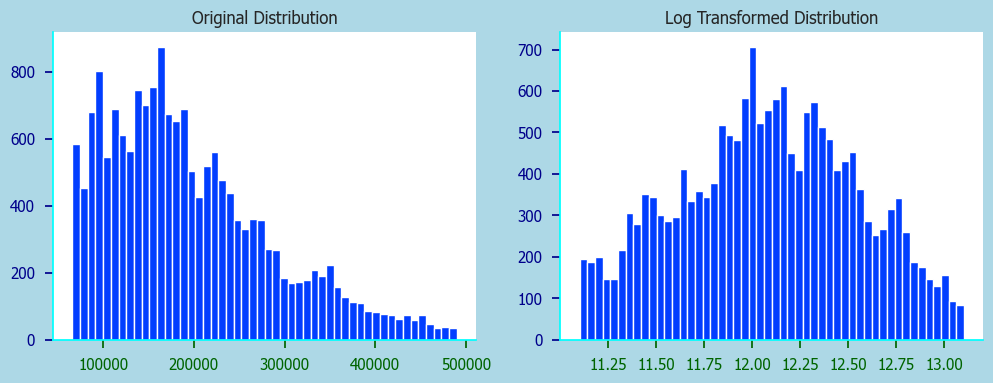

In [459]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original distribution
housing['median_house_value'].hist(ax=axes[0], bins=50)
axes[0].set_title('Original Distribution')

# Log transformed distribution
np.log(housing['median_house_value']).hist(ax=axes[1], bins=50)
axes[1].set_title('Log Transformed Distribution')

plt.show()

**`Step 2: Retrain With Log Transform`**.

In [460]:
# Log transform target variable
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

# Retrain best XGBoost model
best_model = XGBRegressor(learning_rate=0.1, max_depth=6, n_estimators=500, random_state=42)
best_model.fit(X_train, y_train_log)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

**`Step 3: Evaluate`**.

In [461]:
# Predict and reverse log transform
y_pred_log = best_model.predict(X_test)
y_pred = np.exp(y_pred_log)  # reverse the log transform

print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):,.2f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):,.2f}")
print(f"R²:   {r2_score(y_test, y_pred):,.4f}")

RMSE: 40,974.10
MAE:  27,028.32
R²:   0.8042


##### `💡 Step 11 - Final Evaluation`.

**`📊 Key Takeaways`**:
- --
  - **`Log transform did not help overall`**.
  - **`MAE did not improve — model is not better on mean average errors`**.
  - **`RMSE did not improve — model is not better on root mean squared errors`**.
  - **`This tells us the data may not be as skewed as expected`**.
- --
**`🎯 Conclusion`**
  - **`RMSE of $40k — This is not our best result. The best result was achieved with the XGBoost Model!💡`**.
  - **`MAE of $27k — This equal to our best result. The best result was achieved with the XGBoost Model!💡`**.
  - **`R² of 80.42% — This is not our best result. The best result was achieved with the XGBoost Model!💡`**.
  - **`Our best performing model uses XGBoost tuned with clean data and log transformed target variable, explaining 81.32% of house price variance with an average error of ~$27k 🏡`**.
